FIFA Men's World Cup 2026 Predictor

In [ ]:
# ============================================================
# Phase 1: Data Loading and Cleaning
# Project: FIFA World Cup 2026 Winner Prediction
# Dataset: male_players.csv
# ============================================================

import pandas as pd
import numpy as np
from google.colab import files

# ----------------------------
# 1. Upload file
# ----------------------------
uploaded = files.upload()

# ----------------------------
# 2. Load dataset
# ----------------------------
df = pd.read_csv("male_players.csv")

print("Dataset loaded successfully.")
print("Original shape:", df.shape)

# ----------------------------
# 3. Select useful columns
# ----------------------------
useful_columns = [
    "Name",
    "Nation",
    "Position",
    "OVR",
    "PAC",
    "SHO",
    "PAS",
    "DRI",
    "DEF",
    "PHY",
    "Age",
    "Team",
    "League",
    "Preferred foot",
    "Height",
    "Weight",
    "GK Diving",
    "GK Handling",
    "GK Kicking",
    "GK Positioning",
    "GK Reflexes"
]

players = df[useful_columns].copy()

# ----------------------------
# 4. Clean column names
# ----------------------------
players.columns = (
    players.columns
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)

print("Selected columns:")
print(players.columns.tolist())

# ----------------------------
# 5. Remove rows with missing key information
# ----------------------------
players = players.dropna(subset=["name", "nation", "position", "ovr", "age"])

# ----------------------------
# 6. Convert numeric columns
# ----------------------------
numeric_columns = [
    "ovr", "pac", "sho", "pas", "dri", "def", "phy", "age",
    "gk_diving", "gk_handling", "gk_kicking", "gk_positioning", "gk_reflexes"
]

for col in numeric_columns:
    players[col] = pd.to_numeric(players[col], errors="coerce")

# ----------------------------
# 7. Handle missing values
# ----------------------------
gk_columns = [
    "gk_diving",
    "gk_handling",
    "gk_kicking",
    "gk_positioning",
    "gk_reflexes"
]

players[gk_columns] = players[gk_columns].fillna(0)

main_attribute_columns = ["pac", "sho", "pas", "dri", "def", "phy"]

for col in main_attribute_columns:
    players[col] = players[col].fillna(players[col].median())

# ----------------------------
# 8. Create broad position groups
# ----------------------------
position_map = {
    "GK": "GK",

    "CB": "DEF",
    "RB": "DEF",
    "LB": "DEF",
    "RWB": "DEF",
    "LWB": "DEF",

    "CDM": "MID",
    "CM": "MID",
    "CAM": "MID",
    "LM": "MID",
    "RM": "MID",

    "LW": "ATT",
    "RW": "ATT",
    "ST": "ATT",
    "CF": "ATT"
}

players["position_group"] = players["position"].map(position_map)

# Check unmapped positions
unmapped_positions = players[players["position_group"].isnull()]["position"].unique()

print("Unmapped positions:")
print(unmapped_positions)

# Remove rows with unmapped positions
players = players.dropna(subset=["position_group"])

# ----------------------------
# 9. Create quality category
# ----------------------------
def player_quality_category(ovr):
    if ovr >= 85:
        return "World Class"
    elif ovr >= 80:
        return "Elite"
    elif ovr >= 75:
        return "Strong"
    elif ovr >= 70:
        return "Good"
    else:
        return "Average or Below"

players["quality_category"] = players["ovr"].apply(player_quality_category)

# ----------------------------
# 10. Sort dataset
# ----------------------------
players = players.sort_values(
    by=["nation", "ovr"],
    ascending=[True, False]
).reset_index(drop=True)

# ----------------------------
# 11. Create top 26 nation summary
# ----------------------------
top_26_summary = (
    players
    .sort_values(["nation", "ovr"], ascending=[True, False])
    .groupby("nation")
    .head(26)
    .groupby("nation")
    .agg(
        player_count=("name", "count"),
        avg_top_26_ovr=("ovr", "mean"),
        max_ovr=("ovr", "max"),
        avg_age=("age", "mean")
    )
    .reset_index()
)

top_26_summary = top_26_summary.sort_values(
    by="avg_top_26_ovr",
    ascending=False
)

# ----------------------------
# 12. Final checks
# ----------------------------
print("\nCleaning completed successfully.")
print("Final player dataset shape:", players.shape)
print("Total nations:", players["nation"].nunique())
print("Total players:", len(players))

print("\nTop 10 nations by average top 26 OVR:")
display(top_26_summary.head(10))

print("\nTop 10 players:")
display(players[["name", "nation", "position", "position_group", "ovr", "age", "team", "league"]].head(10))

# ----------------------------
# 13. Save outputs
# ----------------------------
players.to_csv("cleaned_male_players_phase1.csv", index=False)
top_26_summary.to_csv("nation_top26_summary_phase1.csv", index=False)

print("\nFiles saved:")
print("1. cleaned_male_players_phase1.csv")
print("2. nation_top26_summary_phase1.csv")

# ----------------------------
# 14. Download files
# ----------------------------
files.download("cleaned_male_players_phase1.csv")
files.download("nation_top26_summary_phase1.csv")

Saving male_players.csv to male_players (1).csv
Dataset loaded successfully.
Original shape: (16161, 58)
Selected columns:
['name', 'nation', 'position', 'ovr', 'pac', 'sho', 'pas', 'dri', 'def', 'phy', 'age', 'team', 'league', 'preferred_foot', 'height', 'weight', 'gk_diving', 'gk_handling', 'gk_kicking', 'gk_positioning', 'gk_reflexes']
Unmapped positions:
[]

Cleaning completed successfully.
Final player dataset shape: (16161, 23)
Total nations: 154
Total players: 16161

Top 10 nations by average top 26 OVR:


,nation,player_count,avg_top_26_ovr,max_ovr,avg_age
50,France,26,84.346154,91,27.461538
44,England,26,84.115385,90,26.961538
17,Brazil,26,83.961538,90,27.807692
54,Germany,26,83.961538,89,29.730769
128,Spain,26,83.884615,91,28.576923
113,Portugal,26,83.115385,88,28.230769
5,Argentina,26,83.115385,89,28.961538
73,Italy,26,83.038462,89,27.846154
63,Holland,26,81.807692,89,27.730769
12,Belgium,26,80.230769,90,29.346154



Top 10 players:


,name,nation,position,position_group,ovr,age,team,league
0,Berat Djimsiti,Albania,CB,DEF,78,31,Bergamo Calcio,Serie A Enilive
1,Iván Balliu,Albania,RB,DEF,77,32,Rayo Vallecano,LALIGA EA SPORTS
2,Rey Manaj,Albania,ST,ATT,76,27,Sivasspor,Trendyol Süper Lig
3,Myrto Uzuni,Albania,ST,ATT,76,29,Granada CF,LALIGA HYPERMOTION
4,Kristjan Asllani,Albania,CDM,MID,75,22,Lombardia FC,Serie A Enilive
5,Qazim Laçi,Albania,CM,MID,75,28,Sparta Praha,Česká Liga
6,Nedim Bajrami,Albania,CAM,MID,74,25,Rangers,Scottish Prem
7,Keidi Bare,Albania,CDM,MID,74,27,Real Zaragoza,LALIGA HYPERMOTION
8,Elseid Hysaj,Albania,LB,DEF,74,30,Latium,Serie A Enilive
9,Marash Kumbulla,Albania,CB,DEF,74,24,RCD Espanyol,LALIGA EA SPORTS



Files saved:
1. cleaned_male_players_phase1.csv
2. nation_top26_summary_phase1.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Phase-2

Saving cleaned_male_players_phase1.csv to cleaned_male_players_phase1 (1).csv
Phase 1 cleaned player dataset loaded successfully.
Shape: (16161, 23)

Total players: 16161
Total nations: 154

Position group distribution:
position_group
MID    6045
DEF    5419
ATT    2881
GK     1816
Name: count, dtype: int64

Nation-level team strength dataset created.
Shape: (154, 16)

Top 20 nations by composite team strength:


,nation,composite_team_strength,team_strength_category,top_11_ovr_avg,top_26_ovr_avg,gk_strength,def_strength,mid_strength,att_strength,star_power,squad_depth,best_player,best_player_ovr
0,France,87.634470,Tournament Favourite,86.454545,84.346154,87.0,85.75,84.50,88.333333,88.666667,82.800000,Kylian Mbappé,91
1,England,87.561845,Tournament Favourite,86.545455,84.115385,83.0,84.75,86.75,88.333333,89.333333,82.333333,Jude Bellingham,90
2,Brazil,87.457131,Tournament Favourite,86.636364,83.961538,89.0,86.00,83.50,87.666667,89.000000,82.000000,Vini Jr.,90
3,Germany,87.263558,Tournament Favourite,86.545455,83.961538,89.0,86.25,86.75,82.000000,88.333333,82.066667,Marc-André ter Stegen,89
4,Spain,87.038639,Tournament Favourite,85.545455,83.884615,86.0,83.75,87.00,83.333333,87.666667,82.666667,Rodri,91
5,Portugal,86.850442,Tournament Favourite,85.818182,83.115385,84.0,84.75,86.25,85.666667,87.666667,81.133333,Bernardo Silva,88
6,Argentina,86.710243,Tournament Favourite,85.454545,83.115385,87.0,83.25,85.25,87.000000,88.000000,81.400000,Lautaro Martínez,89
7,Italy,86.378576,Tournament Favourite,84.818182,83.038462,89.0,84.50,84.50,83.333333,87.666667,81.733333,Gianluigi Donnarumma,89
8,Holland,85.448454,Tournament Favourite,84.090909,81.807692,79.0,85.00,84.25,81.000000,86.666667,80.133333,Virgil van Dijk,89
9,Belgium,84.521747,Tournament Favourite,83.181818,80.230769,89.0,78.75,82.75,83.666667,88.000000,78.066667,Kevin De Bruyne,90


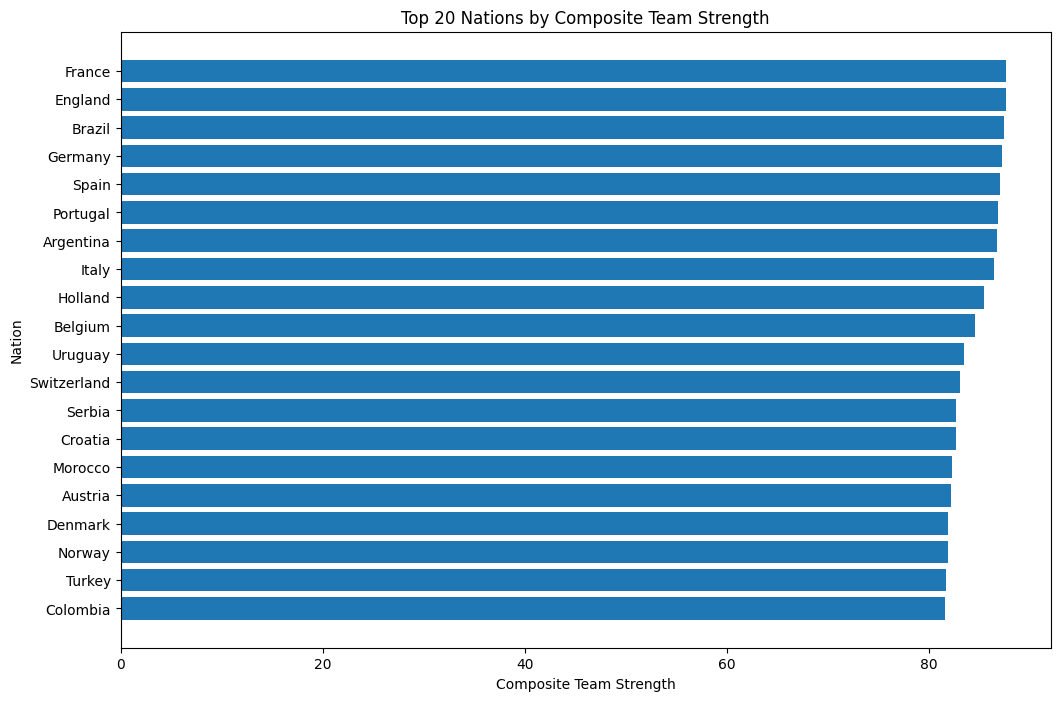


Example team comparison:


,team_a,team_b,team_a_strength,team_b_strength,strength_difference,team_a_attack,team_b_defence,team_a_attack_vs_team_b_defence,team_b_attack,team_a_defence,team_b_attack_vs_team_a_defence,team_a_midfield,team_b_midfield,midfield_difference,team_a_star_power,team_b_star_power,star_power_difference
0,Argentina,France,86.710243,87.63447,-0.924227,87.0,85.75,1.25,88.333333,83.25,5.083333,85.25,84.5,0.75,88.0,88.666667,-0.666667



Example simple prediction:


,team_a,team_b,team_a_win_probability,team_b_win_probability,predicted_winner,strength_difference
0,Argentina,France,0.454,0.546,France,-0.924



Phase 2 output saved successfully:
nation_team_strength_features_phase2.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# Phase 2: Team Strength Feature Engineering
# Project: FIFA World Cup 2026 Interactive Winner Predictor
# Input: cleaned_male_players_phase1.csv
# Output: nation_team_strength_features_phase2.csv
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# ----------------------------
# 1. Upload Phase 1 output
# ----------------------------
uploaded = files.upload()

# ----------------------------
# 2. Load cleaned player dataset
# ----------------------------
players = pd.read_csv("cleaned_male_players_phase1.csv")

print("Phase 1 cleaned player dataset loaded successfully.")
print("Shape:", players.shape)

# ----------------------------
# 3. Basic checks
# ----------------------------
print("\nTotal players:", len(players))
print("Total nations:", players["nation"].nunique())

print("\nPosition group distribution:")
print(players["position_group"].value_counts())

# ----------------------------
# 4. Helper functions
# ----------------------------
def top_n_average(group, n, column="ovr"):
    group = group.sort_values(column, ascending=False)

    if len(group) == 0:
        return np.nan

    return group.head(n)[column].mean()


def positional_strength(group, position_group, n, column="ovr"):
    subset = group[group["position_group"] == position_group].sort_values(column, ascending=False)

    if len(subset) == 0:
        return np.nan

    return subset.head(n)[column].mean()


def star_power(group, n=3):
    group = group.sort_values("ovr", ascending=False)

    if len(group) == 0:
        return np.nan

    return group.head(n)["ovr"].mean()


def squad_depth(group):
    group = group.sort_values("ovr", ascending=False)
    top_26 = group.head(26)

    if len(top_26) <= 11:
        return np.nan

    return top_26.iloc[11:26]["ovr"].mean()


def balance_score(gk, defence, midfield, attack):
    values = [gk, defence, midfield, attack]
    values = [v for v in values if pd.notna(v)]

    if len(values) < 4:
        return np.nan

    return 100 - np.std(values)


# ----------------------------
# 5. Create nation-level features
# ----------------------------
nation_features = []

for nation, group in players.groupby("nation"):

    group = group.sort_values("ovr", ascending=False)

    top_26 = group.head(26)
    top_11 = group.head(11)

    gk = positional_strength(group, "GK", 1)
    defence = positional_strength(group, "DEF", 4)
    midfield = positional_strength(group, "MID", 4)
    attack = positional_strength(group, "ATT", 3)

    best_player = group.iloc[0]

    features = {
        "nation": nation,
        "total_players_available": len(group),

        "top_26_ovr_avg": top_n_average(group, 26),
        "top_11_ovr_avg": top_n_average(group, 11),

        "gk_strength": gk,
        "def_strength": defence,
        "mid_strength": midfield,
        "att_strength": attack,

        "star_power": star_power(group, 3),
        "squad_depth": squad_depth(group),
        "balance_score": balance_score(gk, defence, midfield, attack),

        "avg_age_top_26": top_26["age"].mean(),
        "avg_age_top_11": top_11["age"].mean(),

        "best_player": best_player["name"],
        "best_player_position": best_player["position"],
        "best_player_ovr": best_player["ovr"]
    }

    nation_features.append(features)

team_strength = pd.DataFrame(nation_features)

print("\nNation-level team strength dataset created.")
print("Shape:", team_strength.shape)

# ----------------------------
# 6. Handle missing values
# ----------------------------
team_strength["squad_depth"] = team_strength["squad_depth"].fillna(team_strength["top_26_ovr_avg"])
team_strength["balance_score"] = team_strength["balance_score"].fillna(team_strength["balance_score"].median())

# ----------------------------
# 7. Composite team strength score
# ----------------------------
team_strength["composite_team_strength"] = (
    team_strength["top_11_ovr_avg"] * 0.35
    + team_strength["top_26_ovr_avg"] * 0.20
    + team_strength["star_power"] * 0.15
    + team_strength["squad_depth"] * 0.15
    + team_strength["balance_score"] * 0.15
)

# ----------------------------
# 8. Team strength category
# ----------------------------
def team_strength_category(score):
    if score >= 83:
        return "Tournament Favourite"
    elif score >= 80:
        return "Strong Contender"
    elif score >= 76:
        return "Competitive Team"
    elif score >= 72:
        return "Outsider"
    else:
        return "Underdog"

team_strength["team_strength_category"] = team_strength["composite_team_strength"].apply(team_strength_category)

# ----------------------------
# 9. Sort by strength
# ----------------------------
team_strength = team_strength.sort_values(
    by="composite_team_strength",
    ascending=False
).reset_index(drop=True)

# ----------------------------
# 10. Display strongest nations
# ----------------------------
print("\nTop 20 nations by composite team strength:")

display(
    team_strength[
        [
            "nation",
            "composite_team_strength",
            "team_strength_category",
            "top_11_ovr_avg",
            "top_26_ovr_avg",
            "gk_strength",
            "def_strength",
            "mid_strength",
            "att_strength",
            "star_power",
            "squad_depth",
            "best_player",
            "best_player_ovr"
        ]
    ].head(20)
)

# ----------------------------
# 11. Visual check
# ----------------------------
top_20_plot = team_strength.head(20)

plt.figure(figsize=(12, 8))
plt.barh(top_20_plot["nation"], top_20_plot["composite_team_strength"])
plt.xlabel("Composite Team Strength")
plt.ylabel("Nation")
plt.title("Top 20 Nations by Composite Team Strength")
plt.gca().invert_yaxis()
plt.show()

# ----------------------------
# 12. Team comparison function
# ----------------------------
def compare_teams(team_a, team_b, team_strength_df):

    team_a_data = team_strength_df[team_strength_df["nation"] == team_a]
    team_b_data = team_strength_df[team_strength_df["nation"] == team_b]

    if team_a_data.empty:
        print(f"{team_a} not found in team strength dataset.")
        return None

    if team_b_data.empty:
        print(f"{team_b} not found in team strength dataset.")
        return None

    team_a_data = team_a_data.iloc[0]
    team_b_data = team_b_data.iloc[0]

    comparison = {
        "team_a": team_a,
        "team_b": team_b,

        "team_a_strength": team_a_data["composite_team_strength"],
        "team_b_strength": team_b_data["composite_team_strength"],
        "strength_difference": team_a_data["composite_team_strength"] - team_b_data["composite_team_strength"],

        "team_a_attack": team_a_data["att_strength"],
        "team_b_defence": team_b_data["def_strength"],
        "team_a_attack_vs_team_b_defence": team_a_data["att_strength"] - team_b_data["def_strength"],

        "team_b_attack": team_b_data["att_strength"],
        "team_a_defence": team_a_data["def_strength"],
        "team_b_attack_vs_team_a_defence": team_b_data["att_strength"] - team_a_data["def_strength"],

        "team_a_midfield": team_a_data["mid_strength"],
        "team_b_midfield": team_b_data["mid_strength"],
        "midfield_difference": team_a_data["mid_strength"] - team_b_data["mid_strength"],

        "team_a_star_power": team_a_data["star_power"],
        "team_b_star_power": team_b_data["star_power"],
        "star_power_difference": team_a_data["star_power"] - team_b_data["star_power"]
    }

    return pd.DataFrame([comparison])


# ----------------------------
# 13. Simple strength-based predictor
# ----------------------------
def simple_strength_predictor(team_a, team_b, team_strength_df):

    comparison = compare_teams(team_a, team_b, team_strength_df)

    if comparison is None:
        return None

    comparison = comparison.iloc[0]
    diff = comparison["strength_difference"]

    team_a_win_prob = 1 / (1 + np.exp(-diff / 5))
    team_b_win_prob = 1 - team_a_win_prob

    predicted_winner = team_a if team_a_win_prob >= team_b_win_prob else team_b

    result = {
        "team_a": team_a,
        "team_b": team_b,
        "team_a_win_probability": round(team_a_win_prob, 3),
        "team_b_win_probability": round(team_b_win_prob, 3),
        "predicted_winner": predicted_winner,
        "strength_difference": round(diff, 3)
    }

    return pd.DataFrame([result])


# ----------------------------
# 14. Test examples
# ----------------------------
print("\nExample team comparison:")
display(compare_teams("Argentina", "France", team_strength))

print("\nExample simple prediction:")
display(simple_strength_predictor("Argentina", "France", team_strength))

# ----------------------------
# 15. Save Phase 2 output
# ----------------------------
team_strength.to_csv("nation_team_strength_features_phase2.csv", index=False)

print("\nPhase 2 output saved successfully:")
print("nation_team_strength_features_phase2.csv")

files.download("nation_team_strength_features_phase2.csv")

Phase 4

In [ ]:
# ============================================================
# Phase 3: Match-Level Prediction Model
# Project: FIFA World Cup 2026 Interactive Winner Predictor
#
# Inputs:
# 1. nation_team_strength_features_phase2.csv
# 2. results.csv
#
# Outputs:
# 1. trained_match_prediction_model.pkl
# 2. model_feature_columns_phase3.json
# 3. match_training_dataset_phase3.csv
# ============================================================

import pandas as pd
import numpy as np
import json
import joblib

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, log_loss
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# ----------------------------
# 1. Upload files
# ----------------------------
uploaded = files.upload()

# ----------------------------
# 2. Load datasets
# ----------------------------
team_strength = pd.read_csv("nation_team_strength_features_phase2.csv")
results = pd.read_csv("results.csv")

print("Team strength data loaded:", team_strength.shape)
print("Historical match data loaded:", results.shape)

# ----------------------------
# 3. Clean historical match results
# ----------------------------
results["date"] = pd.to_datetime(results["date"], errors="coerce")

results = results[results["date"].dt.year >= 2000].copy()

results = results.dropna(
    subset=["home_team", "away_team", "home_score", "away_score"]
)

results["home_score"] = results["home_score"].astype(int)
results["away_score"] = results["away_score"].astype(int)

print("Shape after cleaning historical results:", results.shape)

# ----------------------------
# 4. Create target variable
# 0 = home/team_a loses
# 1 = draw
# 2 = home/team_a wins
# ----------------------------
def get_match_result(row):
    if row["home_score"] > row["away_score"]:
        return 2
    elif row["home_score"] == row["away_score"]:
        return 1
    else:
        return 0

results["result_label"] = results.apply(get_match_result, axis=1)

print("\nResult label distribution:")
print(results["result_label"].value_counts(normalize=True))

# ----------------------------
# 5. Prepare team strength columns
# ----------------------------
strength_columns = [
    "nation",
    "composite_team_strength",
    "top_11_ovr_avg",
    "top_26_ovr_avg",
    "gk_strength",
    "def_strength",
    "mid_strength",
    "att_strength",
    "star_power",
    "squad_depth",
    "balance_score",
    "avg_age_top_26",
    "avg_age_top_11"
]

team_strength_model = team_strength[strength_columns].copy()

# ----------------------------
# 6. Standardize country names
# ----------------------------
country_name_map = {
    "USA": "United States",
    "United States": "United States",
    "Korea Republic": "South Korea",
    "Korea DPR": "North Korea",
    "IR Iran": "Iran",
    "Côte d'Ivoire": "Ivory Coast",
    "Czechia": "Czech Republic",
    "Türkiye": "Turkey"
}

def standardize_country_name(name):
    if pd.isna(name):
        return name
    return country_name_map.get(name, name)

results["home_team_std"] = results["home_team"].apply(standardize_country_name)
results["away_team_std"] = results["away_team"].apply(standardize_country_name)
team_strength_model["nation_std"] = team_strength_model["nation"].apply(standardize_country_name)

# ----------------------------
# 7. Merge home team features
# ----------------------------
home_features = team_strength_model.copy()
home_features = home_features.add_prefix("home_")
home_features = home_features.rename(columns={"home_nation_std": "home_team_std"})

match_data = results.merge(
    home_features,
    on="home_team_std",
    how="left"
)

# ----------------------------
# 8. Merge away team features
# ----------------------------
away_features = team_strength_model.copy()
away_features = away_features.add_prefix("away_")
away_features = away_features.rename(columns={"away_nation_std": "away_team_std"})

match_data = match_data.merge(
    away_features,
    on="away_team_std",
    how="left"
)

# ----------------------------
# 9. Check unmatched teams
# ----------------------------
missing_home = match_data[match_data["home_composite_team_strength"].isnull()]["home_team"].unique()
missing_away = match_data[match_data["away_composite_team_strength"].isnull()]["away_team"].unique()

print("\nNumber of unmatched home teams:", len(missing_home))
print("Number of unmatched away teams:", len(missing_away))

print("\nSample unmatched home teams:")
print(missing_home[:20])

print("\nSample unmatched away teams:")
print(missing_away[:20])

# Remove unmatched matches
match_data = match_data.dropna(
    subset=[
        "home_composite_team_strength",
        "away_composite_team_strength"
    ]
).copy()

print("\nShape after removing unmatched teams:", match_data.shape)

# ----------------------------
# 10. Create difference features
# ----------------------------
match_data["strength_diff"] = match_data["home_composite_team_strength"] - match_data["away_composite_team_strength"]
match_data["top11_diff"] = match_data["home_top_11_ovr_avg"] - match_data["away_top_11_ovr_avg"]
match_data["top26_diff"] = match_data["home_top_26_ovr_avg"] - match_data["away_top_26_ovr_avg"]

match_data["gk_diff"] = match_data["home_gk_strength"] - match_data["away_gk_strength"]
match_data["def_diff"] = match_data["home_def_strength"] - match_data["away_def_strength"]
match_data["mid_diff"] = match_data["home_mid_strength"] - match_data["away_mid_strength"]
match_data["att_diff"] = match_data["home_att_strength"] - match_data["away_att_strength"]

match_data["star_power_diff"] = match_data["home_star_power"] - match_data["away_star_power"]
match_data["squad_depth_diff"] = match_data["home_squad_depth"] - match_data["away_squad_depth"]
match_data["balance_diff"] = match_data["home_balance_score"] - match_data["away_balance_score"]
match_data["age_diff"] = match_data["home_avg_age_top_26"] - match_data["away_avg_age_top_26"]

# ----------------------------
# 11. Add neutral and home advantage features
# ----------------------------
if "neutral" in match_data.columns:
    match_data["neutral"] = match_data["neutral"].astype(int)
else:
    match_data["neutral"] = 0

match_data["home_advantage"] = np.where(match_data["neutral"] == 0, 1, 0)

# ----------------------------
# 12. Add major tournament feature
# ----------------------------
major_tournaments = [
    "FIFA World Cup",
    "FIFA World Cup qualification",
    "UEFA Euro",
    "UEFA Euro qualification",
    "Copa América",
    "AFC Asian Cup",
    "African Cup of Nations",
    "CONCACAF Gold Cup",
    "Oceania Nations Cup"
]

def tournament_importance(tournament):
    if tournament in major_tournaments:
        return 1
    else:
        return 0

match_data["major_tournament"] = match_data["tournament"].apply(tournament_importance)

# ----------------------------
# 13. Select features and target
# ----------------------------
feature_columns = [
    "strength_diff",
    "top11_diff",
    "top26_diff",
    "gk_diff",
    "def_diff",
    "mid_diff",
    "att_diff",
    "star_power_diff",
    "squad_depth_diff",
    "balance_diff",
    "age_diff",
    "home_advantage",
    "neutral",
    "major_tournament"
]

X = match_data[feature_columns].copy()
y = match_data["result_label"].copy()

X = X.fillna(X.median())

print("\nFeature matrix shape:", X.shape)
print("Target shape:", y.shape)

# ----------------------------
# 14. Train-test split
# ----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ----------------------------
# 15. Train models
# ----------------------------
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, multi_class="multinomial"))
    ]),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced",
        max_depth=8
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

model_results = []

for model_name, model in models.items():
    print(f"\nTraining model: {model_name}")

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)

    acc = accuracy_score(y_test, y_pred)
    loss = log_loss(y_test, y_prob)

    model_results.append({
        "model_name": model_name,
        "accuracy": acc,
        "log_loss": loss
    })

    print("Accuracy:", round(acc, 4))
    print("Log Loss:", round(loss, 4))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

# ----------------------------
# 16. Compare models
# ----------------------------
model_results_df = pd.DataFrame(model_results)

model_results_df = model_results_df.sort_values(
    by="log_loss",
    ascending=True
)

print("\nModel comparison:")
display(model_results_df)

best_model_name = model_results_df.iloc[0]["model_name"]
best_model = models[best_model_name]

print("\nBest model selected:", best_model_name)

# ----------------------------
# 17. Confusion matrix
# ----------------------------
y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)

cm_df = pd.DataFrame(
    cm,
    index=["Actual Away Win", "Actual Draw", "Actual Home Win"],
    columns=["Pred Away Win", "Pred Draw", "Pred Home Win"]
)

print("\nConfusion Matrix:")
display(cm_df)

# ----------------------------
# 18. Prediction function
# ----------------------------
def predict_match(team_a, team_b, team_strength_df, model, feature_columns, neutral=True, major_tournament=True):

    team_a_data = team_strength_df[team_strength_df["nation"] == team_a]
    team_b_data = team_strength_df[team_strength_df["nation"] == team_b]

    if team_a_data.empty:
        raise ValueError(f"{team_a} not found in team strength dataset.")

    if team_b_data.empty:
        raise ValueError(f"{team_b} not found in team strength dataset.")

    team_a_data = team_a_data.iloc[0]
    team_b_data = team_b_data.iloc[0]

    row = {
        "strength_diff": team_a_data["composite_team_strength"] - team_b_data["composite_team_strength"],
        "top11_diff": team_a_data["top_11_ovr_avg"] - team_b_data["top_11_ovr_avg"],
        "top26_diff": team_a_data["top_26_ovr_avg"] - team_b_data["top_26_ovr_avg"],
        "gk_diff": team_a_data["gk_strength"] - team_b_data["gk_strength"],
        "def_diff": team_a_data["def_strength"] - team_b_data["def_strength"],
        "mid_diff": team_a_data["mid_strength"] - team_b_data["mid_strength"],
        "att_diff": team_a_data["att_strength"] - team_b_data["att_strength"],
        "star_power_diff": team_a_data["star_power"] - team_b_data["star_power"],
        "squad_depth_diff": team_a_data["squad_depth"] - team_b_data["squad_depth"],
        "balance_diff": team_a_data["balance_score"] - team_b_data["balance_score"],
        "age_diff": team_a_data["avg_age_top_26"] - team_b_data["avg_age_top_26"],
        "home_advantage": 0 if neutral else 1,
        "neutral": 1 if neutral else 0,
        "major_tournament": 1 if major_tournament else 0
    }

    input_df = pd.DataFrame([row])
    input_df = input_df[feature_columns]
    input_df = input_df.fillna(input_df.median())

    probabilities = model.predict_proba(input_df)[0]
    class_order = list(model.classes_)
    prob_dict = dict(zip(class_order, probabilities))

    team_b_win_prob = prob_dict.get(0, 0)
    draw_prob = prob_dict.get(1, 0)
    team_a_win_prob = prob_dict.get(2, 0)

    if team_a_win_prob > team_b_win_prob and team_a_win_prob > draw_prob:
        predicted_result = f"{team_a} win"
        predicted_winner = team_a
    elif team_b_win_prob > team_a_win_prob and team_b_win_prob > draw_prob:
        predicted_result = f"{team_b} win"
        predicted_winner = team_b
    else:
        predicted_result = "Draw"
        predicted_winner = "Draw"

    result = {
        "team_a": team_a,
        "team_b": team_b,
        "team_a_win_probability": round(team_a_win_prob, 3),
        "draw_probability": round(draw_prob, 3),
        "team_b_win_probability": round(team_b_win_prob, 3),
        "predicted_result": predicted_result,
        "predicted_winner": predicted_winner
    }

    return pd.DataFrame([result])

# ----------------------------
# 19. Test predictions
# ----------------------------
print("\nExample Prediction 1:")
display(predict_match("Argentina", "France", team_strength, best_model, feature_columns))

print("\nExample Prediction 2:")
display(predict_match("Brazil", "England", team_strength, best_model, feature_columns))

# ----------------------------
# 20. Save outputs
# ----------------------------
joblib.dump(best_model, "trained_match_prediction_model.pkl")

with open("model_feature_columns_phase3.json", "w") as f:
    json.dump(feature_columns, f)

match_data.to_csv("match_training_dataset_phase3.csv", index=False)

print("\nFiles saved successfully:")
print("1. trained_match_prediction_model.pkl")
print("2. model_feature_columns_phase3.json")
print("3. match_training_dataset_phase3.csv")

files.download("trained_match_prediction_model.pkl")
files.download("model_feature_columns_phase3.json")
files.download("match_training_dataset_phase3.csv")

Saving nation_team_strength_features_phase2.csv to nation_team_strength_features_phase2 (2).csv
Saving results.csv to results.csv
Team strength data loaded: (154, 18)
Historical match data loaded: (49287, 9)
Shape after cleaning historical results: (25157, 9)

Result label distribution:
result_label
2    0.480900
0    0.285885
1    0.233215
Name: proportion, dtype: float64

Number of unmatched home teams: 164
Number of unmatched away teams: 155

Sample unmatched home teams:
['Vietnam' 'DR Congo' 'Qatar' 'United States Virgin Islands' 'Kuwait'
 'British Virgin Islands' 'Saint Kitts and Nevis' 'Cayman Islands'
 'Singapore' 'Nepal' 'Yemen' 'Macau' 'Turkmenistan' 'Malaysia' 'Bhutan'
 'Dominica' 'Oman' 'Lesotho' 'Kernow' 'Botswana']

Sample unmatched away teams:
['Qatar' 'Guam' 'DR Congo' 'Saint Lucia' 'Malaysia' 'Singapore'
 'Turkmenistan' 'Yemen' 'Bhutan' 'British Virgin Islands' 'Brunei' 'Nepal'
 'Maldives' 'Saint Kitts and Nevis' 'Eswatini' 'Guernsey' 'Anguilla'
 'Lesotho' 'Mongolia' 'N

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Accuracy: 0.5441
Log Loss: 0.9611

Classification Report:
              precision    recall  f1-score   support

           0       0.49      0.51      0.50       916
           1       0.00      0.00      0.00       822
           2       0.57      0.85      0.68      1550

    accuracy                           0.54      3288
   macro avg       0.35      0.45      0.39      3288
weighted avg       0.40      0.54      0.46      3288


Training model: Random Forest


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Accuracy: 0.5085
Log Loss: 0.9888

Classification Report:
              precision    recall  f1-score   support

           0       0.46      0.60      0.52       916
           1       0.28      0.21      0.24       822
           2       0.64      0.61      0.63      1550

    accuracy                           0.51      3288
   macro avg       0.46      0.47      0.46      3288
weighted avg       0.50      0.51      0.50      3288


Training model: Gradient Boosting
Accuracy: 0.5474
Log Loss: 0.9582

Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.51      0.51       916
           1       0.28      0.02      0.04       822
           2       0.57      0.85      0.68      1550

    accuracy                           0.55      3288
   macro avg       0.45      0.46      0.41      3288
weighted avg       0.48      0.55      0.47      3288


Model comparison:


...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Phase 3

In [ ]:
# ============================================================
# Phase 3: Match-Level Prediction Model
# Project: FIFA World Cup 2026 Interactive Winner Predictor
#
# Required input files:
# 1. nation_team_strength_features_phase2.csv
# 2. results.csv
#
# Output files:
# 1. trained_match_prediction_model.pkl
# 2. model_feature_columns_phase3.json
# 3. match_training_dataset_phase3.csv
# ============================================================

import pandas as pd
import numpy as np
import json
import joblib
import os

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, log_loss
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline


# ============================================================
# 1. Upload files
# ============================================================

print("Please upload these two files:")
print("1. nation_team_strength_features_phase2.csv")
print("2. results.csv")

uploaded = files.upload()

print("\nFiles currently available in Colab:")
print(os.listdir())


# ============================================================
# 2. Find and load required files
# ============================================================

# This helps if Colab renames your file like:
# nation_team_strength_features_phase2 (1).csv

team_strength_file = None
results_file = None

for file in os.listdir():
    if file.startswith("nation_team_strength_features_phase2") and file.endswith(".csv"):
        team_strength_file = file
    if file == "results.csv":
        results_file = file

if team_strength_file is None:
    raise FileNotFoundError("Could not find nation_team_strength_features_phase2.csv")

if results_file is None:
    raise FileNotFoundError("Could not find results.csv. Please upload the historical match results file.")

team_strength = pd.read_csv(team_strength_file)
results = pd.read_csv(results_file)

print("\nTeam strength file used:", team_strength_file)
print("Results file used:", results_file)

print("\nTeam strength data loaded:", team_strength.shape)
print("Historical match results loaded:", results.shape)


# ============================================================
# 3. Inspect columns
# ============================================================

print("\nTeam strength columns:")
print(team_strength.columns.tolist())

print("\nHistorical results columns:")
print(results.columns.tolist())


# ============================================================
# 4. Clean historical results
# ============================================================

results["date"] = pd.to_datetime(results["date"], errors="coerce")

# Use modern football era only
results = results[results["date"].dt.year >= 2000].copy()

# Remove rows with missing key values
results = results.dropna(
    subset=["home_team", "away_team", "home_score", "away_score"]
)

# Convert scores to integer
results["home_score"] = results["home_score"].astype(int)
results["away_score"] = results["away_score"].astype(int)

print("\nShape after cleaning historical results:", results.shape)


# ============================================================
# 5. Create target variable
#
# 0 = home/team_a loses
# 1 = draw
# 2 = home/team_a wins
# ============================================================

def get_match_result(row):
    if row["home_score"] > row["away_score"]:
        return 2
    elif row["home_score"] == row["away_score"]:
        return 1
    else:
        return 0

results["result_label"] = results.apply(get_match_result, axis=1)

print("\nResult label distribution:")
print(results["result_label"].value_counts(normalize=True))


# ============================================================
# 6. Prepare team strength features
# ============================================================

strength_columns = [
    "nation",
    "composite_team_strength",
    "top_11_ovr_avg",
    "top_26_ovr_avg",
    "gk_strength",
    "def_strength",
    "mid_strength",
    "att_strength",
    "star_power",
    "squad_depth",
    "balance_score",
    "avg_age_top_26",
    "avg_age_top_11"
]

missing_strength_cols = [col for col in strength_columns if col not in team_strength.columns]

if len(missing_strength_cols) > 0:
    raise ValueError(f"These required columns are missing from Phase 2 file: {missing_strength_cols}")

team_strength_model = team_strength[strength_columns].copy()


# ============================================================
# 7. Standardise country names
# ============================================================

country_name_map = {
    "USA": "United States",
    "United States": "United States",
    "Korea Republic": "South Korea",
    "Korea DPR": "North Korea",
    "IR Iran": "Iran",
    "Côte d'Ivoire": "Ivory Coast",
    "Cote d'Ivoire": "Ivory Coast",
    "Czechia": "Czech Republic",
    "Türkiye": "Turkey",
    "Turkey": "Turkey",
    "Republic of Ireland": "Ireland",
    "Bosnia and Herzegovina": "Bosnia & Herzegovina"
}

def standardize_country_name(name):
    if pd.isna(name):
        return name
    return country_name_map.get(name, name)

results["home_team_std"] = results["home_team"].apply(standardize_country_name)
results["away_team_std"] = results["away_team"].apply(standardize_country_name)
team_strength_model["nation_std"] = team_strength_model["nation"].apply(standardize_country_name)


# ============================================================
# 8. Merge home/team_a features
# ============================================================

home_features = team_strength_model.copy()
home_features = home_features.add_prefix("home_")
home_features = home_features.rename(columns={"home_nation_std": "home_team_std"})

match_data = results.merge(
    home_features,
    on="home_team_std",
    how="left"
)

print("\nAfter merging home team features:", match_data.shape)


# ============================================================
# 9. Merge away/team_b features
# ============================================================

away_features = team_strength_model.copy()
away_features = away_features.add_prefix("away_")
away_features = away_features.rename(columns={"away_nation_std": "away_team_std"})

match_data = match_data.merge(
    away_features,
    on="away_team_std",
    how="left"
)

print("After merging away team features:", match_data.shape)


# ============================================================
# 10. Check unmatched teams
# ============================================================

missing_home = match_data[match_data["home_composite_team_strength"].isnull()]["home_team"].unique()
missing_away = match_data[match_data["away_composite_team_strength"].isnull()]["away_team"].unique()

print("\nNumber of unmatched home teams:", len(missing_home))
print("Number of unmatched away teams:", len(missing_away))

print("\nSample unmatched home teams:")
print(missing_home[:30])

print("\nSample unmatched away teams:")
print(missing_away[:30])

# Remove matches where one or both teams are not available in the player-rating strength file
match_data = match_data.dropna(
    subset=[
        "home_composite_team_strength",
        "away_composite_team_strength"
    ]
).copy()

print("\nShape after removing unmatched matches:", match_data.shape)

if match_data.shape[0] == 0:
    raise ValueError("No matched historical matches found. Country names may not match between the two datasets.")


# ============================================================
# 11. Create match comparison features
# ============================================================

match_data["strength_diff"] = (
    match_data["home_composite_team_strength"]
    - match_data["away_composite_team_strength"]
)

match_data["top11_diff"] = (
    match_data["home_top_11_ovr_avg"]
    - match_data["away_top_11_ovr_avg"]
)

match_data["top26_diff"] = (
    match_data["home_top_26_ovr_avg"]
    - match_data["away_top_26_ovr_avg"]
)

match_data["gk_diff"] = (
    match_data["home_gk_strength"]
    - match_data["away_gk_strength"]
)

match_data["def_diff"] = (
    match_data["home_def_strength"]
    - match_data["away_def_strength"]
)

match_data["mid_diff"] = (
    match_data["home_mid_strength"]
    - match_data["away_mid_strength"]
)

match_data["att_diff"] = (
    match_data["home_att_strength"]
    - match_data["away_att_strength"]
)

match_data["star_power_diff"] = (
    match_data["home_star_power"]
    - match_data["away_star_power"]
)

match_data["squad_depth_diff"] = (
    match_data["home_squad_depth"]
    - match_data["away_squad_depth"]
)

match_data["balance_diff"] = (
    match_data["home_balance_score"]
    - match_data["away_balance_score"]
)

match_data["age_diff"] = (
    match_data["home_avg_age_top_26"]
    - match_data["away_avg_age_top_26"]
)


# ============================================================
# 12. Add home advantage and tournament importance
# ============================================================

if "neutral" in match_data.columns:
    match_data["neutral"] = match_data["neutral"].astype(int)
else:
    match_data["neutral"] = 0

match_data["home_advantage"] = np.where(match_data["neutral"] == 0, 1, 0)

major_tournaments = [
    "FIFA World Cup",
    "FIFA World Cup qualification",
    "UEFA Euro",
    "UEFA Euro qualification",
    "Copa América",
    "AFC Asian Cup",
    "African Cup of Nations",
    "CONCACAF Gold Cup",
    "Oceania Nations Cup"
]

def tournament_importance(tournament):
    if tournament in major_tournaments:
        return 1
    else:
        return 0

match_data["major_tournament"] = match_data["tournament"].apply(tournament_importance)


# ============================================================
# 13. Select final features and target
# ============================================================

feature_columns = [
    "strength_diff",
    "top11_diff",
    "top26_diff",
    "gk_diff",
    "def_diff",
    "mid_diff",
    "att_diff",
    "star_power_diff",
    "squad_depth_diff",
    "balance_diff",
    "age_diff",
    "home_advantage",
    "neutral",
    "major_tournament"
]

X = match_data[feature_columns].copy()
y = match_data["result_label"].copy()

# Fill remaining missing values
X = X.fillna(X.median())

print("\nFeature matrix shape:", X.shape)
print("Target shape:", y.shape)


# ============================================================
# 14. Train-test split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining data:", X_train.shape)
print("Testing data:", X_test.shape)


# ============================================================
# 15. Train multiple models
# ============================================================

models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000))
    ]),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced",
        max_depth=8
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

model_results = []

for model_name, model in models.items():
    print(f"\nTraining model: {model_name}")

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    loss = log_loss(y_test, y_prob)

    model_results.append({
        "model_name": model_name,
        "accuracy": accuracy,
        "log_loss": loss
    })

    print("Accuracy:", round(accuracy, 4))
    print("Log Loss:", round(loss, 4))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))


# ============================================================
# 16. Compare models
# ============================================================

model_results_df = pd.DataFrame(model_results)

model_results_df = model_results_df.sort_values(
    by="log_loss",
    ascending=True
).reset_index(drop=True)

print("\nModel comparison:")
display(model_results_df)

best_model_name = model_results_df.iloc[0]["model_name"]
best_model = models[best_model_name]

print("\nBest model selected:", best_model_name)


# ============================================================
# 17. Confusion matrix
# ============================================================

y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)

cm_df = pd.DataFrame(
    cm,
    index=["Actual Team A Loss", "Actual Draw", "Actual Team A Win"],
    columns=["Pred Team A Loss", "Pred Draw", "Pred Team A Win"]
)

print("\nConfusion Matrix:")
display(cm_df)


# ============================================================
# 18. Match prediction function
# ============================================================

def predict_match(team_a, team_b, team_strength_df, model, feature_columns, neutral=True, major_tournament=True):
    """
    Predicts match outcome probabilities between two teams.

    team_a = first team in the fixture
    team_b = second team in the fixture

    Output:
    - team_a_win_probability
    - draw_probability
    - team_b_win_probability
    - predicted_winner
    """

    team_a_data = team_strength_df[team_strength_df["nation"] == team_a]
    team_b_data = team_strength_df[team_strength_df["nation"] == team_b]

    if team_a_data.empty:
        raise ValueError(f"{team_a} not found in team strength dataset.")

    if team_b_data.empty:
        raise ValueError(f"{team_b} not found in team strength dataset.")

    team_a_data = team_a_data.iloc[0]
    team_b_data = team_b_data.iloc[0]

    row = {
        "strength_diff": team_a_data["composite_team_strength"] - team_b_data["composite_team_strength"],
        "top11_diff": team_a_data["top_11_ovr_avg"] - team_b_data["top_11_ovr_avg"],
        "top26_diff": team_a_data["top_26_ovr_avg"] - team_b_data["top_26_ovr_avg"],
        "gk_diff": team_a_data["gk_strength"] - team_b_data["gk_strength"],
        "def_diff": team_a_data["def_strength"] - team_b_data["def_strength"],
        "mid_diff": team_a_data["mid_strength"] - team_b_data["mid_strength"],
        "att_diff": team_a_data["att_strength"] - team_b_data["att_strength"],
        "star_power_diff": team_a_data["star_power"] - team_b_data["star_power"],
        "squad_depth_diff": team_a_data["squad_depth"] - team_b_data["squad_depth"],
        "balance_diff": team_a_data["balance_score"] - team_b_data["balance_score"],
        "age_diff": team_a_data["avg_age_top_26"] - team_b_data["avg_age_top_26"],
        "home_advantage": 0 if neutral else 1,
        "neutral": 1 if neutral else 0,
        "major_tournament": 1 if major_tournament else 0
    }

    input_df = pd.DataFrame([row])
    input_df = input_df[feature_columns]
    input_df = input_df.fillna(0)

    probabilities = model.predict_proba(input_df)[0]
    class_order = list(model.classes_)

    probability_map = dict(zip(class_order, probabilities))

    team_b_win_probability = probability_map.get(0, 0)
    draw_probability = probability_map.get(1, 0)
    team_a_win_probability = probability_map.get(2, 0)

    if team_a_win_probability > team_b_win_probability and team_a_win_probability > draw_probability:
        predicted_result = f"{team_a} win"
        predicted_winner = team_a
    elif team_b_win_probability > team_a_win_probability and team_b_win_probability > draw_probability:
        predicted_result = f"{team_b} win"
        predicted_winner = team_b
    else:
        predicted_result = "Draw"
        predicted_winner = "Draw"

    output = {
        "team_a": team_a,
        "team_b": team_b,
        "team_a_win_probability": round(team_a_win_probability, 3),
        "draw_probability": round(draw_probability, 3),
        "team_b_win_probability": round(team_b_win_probability, 3),
        "predicted_result": predicted_result,
        "predicted_winner": predicted_winner
    }

    return pd.DataFrame([output])


# ============================================================
# 19. Test prediction function
# ============================================================

print("\nExample Prediction 1:")
try:
    display(predict_match("Argentina", "France", team_strength, best_model, feature_columns))
except Exception as e:
    print(e)

print("\nExample Prediction 2:")
try:
    display(predict_match("Brazil", "England", team_strength, best_model, feature_columns))
except Exception as e:
    print(e)

print("\nExample Prediction 3:")
try:
    display(predict_match("Germany", "Japan", team_strength, best_model, feature_columns))
except Exception as e:
    print(e)


# ============================================================
# 20. Save outputs
# ============================================================

joblib.dump(best_model, "trained_match_prediction_model.pkl")

with open("model_feature_columns_phase3.json", "w") as f:
    json.dump(feature_columns, f)

match_data.to_csv("match_training_dataset_phase3.csv", index=False)

model_results_df.to_csv("model_comparison_phase3.csv", index=False)

print("\nPhase 3 files saved successfully:")
print("1. trained_match_prediction_model.pkl")
print("2. model_feature_columns_phase3.json")
print("3. match_training_dataset_phase3.csv")
print("4. model_comparison_phase3.csv")


# ============================================================
# 21. Download output files
# ============================================================

files.download("trained_match_prediction_model.pkl")
files.download("model_feature_columns_phase3.json")
files.download("match_training_dataset_phase3.csv")
files.download("model_comparison_phase3.csv")

Please upload these two files:
1. nation_team_strength_features_phase2.csv
2. results.csv


Saving nation_team_strength_features_phase2.csv to nation_team_strength_features_phase2 (3).csv
Saving results.csv to results (1).csv

Files currently available in Colab:
['.config', 'male_players (1).csv', 'match_training_dataset_phase3.csv', 'male_players.csv', 'trained_match_prediction_model.pkl', 'results.csv', 'nation_top26_summary_phase1.csv', 'nation_team_strength_features_phase2.csv', 'nation_team_strength_features_phase2 (1).csv', 'cleaned_male_players_phase1 (1).csv', 'nation_team_strength_features_phase2 (3).csv', 'model_feature_columns_phase3.json', 'nation_team_strength_features_phase2 (2).csv', 'results (1).csv', 'cleaned_male_players_phase1.csv', 'sample_data']

Team strength file used: nation_team_strength_features_phase2 (2).csv
Results file used: results.csv

Team strength data loaded: (154, 18)
Historical match results loaded: (49287, 9)

Team strength columns:
['nation', 'total_players_available', 'top_26_ovr_avg', 'top_11_ovr_avg', 'gk_strength', 'def_strength', 'm

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Accuracy: 0.5085
Log Loss: 0.9888

Classification Report:
              precision    recall  f1-score   support

           0       0.46      0.60      0.52       916
           1       0.28      0.21      0.24       822
           2       0.64      0.61      0.63      1550

    accuracy                           0.51      3288
   macro avg       0.46      0.47      0.46      3288
weighted avg       0.50      0.51      0.50      3288


Training model: Gradient Boosting
Accuracy: 0.5474
Log Loss: 0.9582

Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.51      0.51       916
           1       0.28      0.02      0.04       822
           2       0.57      0.85      0.68      1550

    accuracy                           0.55      3288
   macro avg       0.45      0.46      0.41      3288
weighted avg       0.48      0.55      0.47      3288


Model comparison:


,model_name,accuracy,log_loss
0,Gradient Boosting,0.547445,0.958242
1,Logistic Regression,0.544100,0.961070
2,Random Forest,0.508516,0.988766


...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Phase 4

In [ ]:
# ============================================================
# Phase 4: World Cup 2026 Group-Stage Fixture Engine
# Project: FIFA World Cup 2026 Interactive Winner Predictor
#
# Required input files:
# 1. nation_team_strength_features_phase2.csv
# 2. trained_match_prediction_model.pkl
# 3. model_feature_columns_phase3.json
#
# Output files:
# 1. world_cup_2026_group_match_predictions_phase4.csv
# 2. world_cup_2026_group_tables_phase4.csv
# 3. world_cup_2026_qualified_32_phase4.csv
# ============================================================

import pandas as pd
import numpy as np
import json
import joblib
import os

from google.colab import files


# ============================================================
# 1. Check available files
# ============================================================

print("Files currently available in Colab:")
print(os.listdir())


# ============================================================
# 2. Upload missing files only if needed
# ============================================================

required_files = [
    "nation_team_strength_features_phase2.csv",
    "trained_match_prediction_model.pkl",
    "model_feature_columns_phase3.json"
]

missing_files = [file for file in required_files if file not in os.listdir()]

if len(missing_files) > 0:
    print("\nThe following files are missing:")
    print(missing_files)
    print("\nPlease upload the missing files.")
    uploaded = files.upload()
else:
    print("\nAll required files are already available.")


# ============================================================
# 3. Load Phase 2 and Phase 3 outputs
# ============================================================

team_strength = pd.read_csv("nation_team_strength_features_phase2.csv")
model = joblib.load("trained_match_prediction_model.pkl")

with open("model_feature_columns_phase3.json", "r") as f:
    feature_columns = json.load(f)

print("\nTeam strength data loaded:", team_strength.shape)
print("Trained model loaded successfully.")
print("Feature columns loaded:")
print(feature_columns)


# ============================================================
# 4. Define World Cup 2026 groups
# ============================================================
#
# IMPORTANT:
# Replace the sample groups below with the official World Cup 2026 groups.
# The model will only work if the country names match the names in your
# nation_team_strength_features_phase2.csv file.
#
# For example, use "United States" if that is how the team appears in your data.
#
# The code below uses sample groups only so that you can test the engine.
# ============================================================

world_cup_groups = {
    "Group A": ["Mexico", "South Africa", "South Korea", "Norway"],
    "Group B": ["Canada", "Bosnia & Herzegovina", "Switzerland", "Qatar"],
    "Group C": ["Brazil", "Morocco", "Scotland", "Haiti"],
    "Group D": ["United States", "Paraguay", "Australia", "Turkey"],
    "Group E": ["Germany", "Japan", "Ivory Coast", "New Zealand"],
    "Group F": ["Netherlands", "Saudi Arabia", "Egypt", "Venezuela"],
    "Group G": ["Belgium", "Uruguay", "Iran", "Panama"],
    "Group H": ["Spain", "Colombia", "Ghana", "Tunisia"],
    "Group I": ["France", "Senegal", "Croatia", "Jamaica"],
    "Group J": ["Argentina", "Denmark", "Nigeria", "Wales"],
    "Group K": ["Portugal", "Serbia", "Ecuador", "Algeria"],
    "Group L": ["England", "Croatia", "Ghana", "Panama"]
}

print("\nGroups loaded:")
for group_name, teams in world_cup_groups.items():
    print(group_name, ":", teams)


# ============================================================
# 5. Check whether all group teams exist in team strength file
# ============================================================

available_teams = set(team_strength["nation"].unique())

missing_group_teams = []

for group_name, teams in world_cup_groups.items():
    for team in teams:
        if team not in available_teams:
            missing_group_teams.append((group_name, team))

if len(missing_group_teams) > 0:
    print("\nWARNING: These teams are not found in your team strength file:")
    for group_name, team in missing_group_teams:
        print(group_name, "-", team)

    print("\nYou must fix these names before final prediction.")
    print("Check the exact country names using:")
    print("team_strength['nation'].sort_values().unique()")
else:
    print("\nAll group teams are available in the team strength file.")


# ============================================================
# 6. Match prediction function
# ============================================================

def predict_match(team_a, team_b, team_strength_df, model, feature_columns, neutral=True, major_tournament=True):
    """
    Predicts match outcome probabilities between two teams.

    team_a = first team in fixture
    team_b = second team in fixture

    Output:
    - team_a_win_probability
    - draw_probability
    - team_b_win_probability
    - predicted_winner
    """

    team_a_data = team_strength_df[team_strength_df["nation"] == team_a]
    team_b_data = team_strength_df[team_strength_df["nation"] == team_b]

    if team_a_data.empty:
        raise ValueError(f"{team_a} not found in team strength dataset.")

    if team_b_data.empty:
        raise ValueError(f"{team_b} not found in team strength dataset.")

    team_a_data = team_a_data.iloc[0]
    team_b_data = team_b_data.iloc[0]

    row = {
        "strength_diff": team_a_data["composite_team_strength"] - team_b_data["composite_team_strength"],
        "top11_diff": team_a_data["top_11_ovr_avg"] - team_b_data["top_11_ovr_avg"],
        "top26_diff": team_a_data["top_26_ovr_avg"] - team_b_data["top_26_ovr_avg"],
        "gk_diff": team_a_data["gk_strength"] - team_b_data["gk_strength"],
        "def_diff": team_a_data["def_strength"] - team_b_data["def_strength"],
        "mid_diff": team_a_data["mid_strength"] - team_b_data["mid_strength"],
        "att_diff": team_a_data["att_strength"] - team_b_data["att_strength"],
        "star_power_diff": team_a_data["star_power"] - team_b_data["star_power"],
        "squad_depth_diff": team_a_data["squad_depth"] - team_b_data["squad_depth"],
        "balance_diff": team_a_data["balance_score"] - team_b_data["balance_score"],
        "age_diff": team_a_data["avg_age_top_26"] - team_b_data["avg_age_top_26"],
        "home_advantage": 0 if neutral else 1,
        "neutral": 1 if neutral else 0,
        "major_tournament": 1 if major_tournament else 0
    }

    input_df = pd.DataFrame([row])
    input_df = input_df[feature_columns]
    input_df = input_df.fillna(0)

    probabilities = model.predict_proba(input_df)[0]
    class_order = list(model.classes_)
    probability_map = dict(zip(class_order, probabilities))

    team_b_win_probability = probability_map.get(0, 0)
    draw_probability = probability_map.get(1, 0)
    team_a_win_probability = probability_map.get(2, 0)

    if team_a_win_probability > team_b_win_probability and team_a_win_probability > draw_probability:
        predicted_result = f"{team_a} win"
        predicted_winner = team_a
    elif team_b_win_probability > team_a_win_probability and team_b_win_probability > draw_probability:
        predicted_result = f"{team_b} win"
        predicted_winner = team_b
    else:
        predicted_result = "Draw"
        predicted_winner = "Draw"

    return {
        "team_a": team_a,
        "team_b": team_b,
        "team_a_win_probability": round(team_a_win_probability, 3),
        "draw_probability": round(draw_probability, 3),
        "team_b_win_probability": round(team_b_win_probability, 3),
        "predicted_result": predicted_result,
        "predicted_winner": predicted_winner
    }


# ============================================================
# 7. Convert probabilities into likely scoreline
# ============================================================
#
# This is a simple practical rule for creating group tables.
# Later, you can improve this with expected goals.
# ============================================================

def assign_predicted_score(prediction):
    """
    Creates a simple predicted scoreline from probabilities.

    This is needed because group tables require:
    - goals for
    - goals against
    - goal difference
    """

    team_a = prediction["team_a"]
    team_b = prediction["team_b"]

    team_a_prob = prediction["team_a_win_probability"]
    draw_prob = prediction["draw_probability"]
    team_b_prob = prediction["team_b_win_probability"]

    predicted_winner = prediction["predicted_winner"]

    # Draw
    if predicted_winner == "Draw":
        return 1, 1

    # Strong Team A win
    if predicted_winner == team_a:
        if team_a_prob >= 0.70:
            return 3, 0
        elif team_a_prob >= 0.55:
            return 2, 0
        else:
            return 2, 1

    # Strong Team B win
    if predicted_winner == team_b:
        if team_b_prob >= 0.70:
            return 0, 3
        elif team_b_prob >= 0.55:
            return 0, 2
        else:
            return 1, 2


# ============================================================
# 8. Generate group-stage fixtures
# ============================================================
#
# Standard 4-team group round-robin:
# Matchday 1: Team 1 vs Team 2, Team 3 vs Team 4
# Matchday 2: Team 1 vs Team 3, Team 4 vs Team 2
# Matchday 3: Team 4 vs Team 1, Team 2 vs Team 3
# ============================================================

def generate_group_fixtures(group_name, teams):
    """
    Generates 6 matches for a 4-team group.
    """

    if len(teams) != 4:
        raise ValueError(f"{group_name} must contain exactly 4 teams.")

    fixtures = [
        (teams[0], teams[1], 1),
        (teams[2], teams[3], 1),
        (teams[0], teams[2], 2),
        (teams[3], teams[1], 2),
        (teams[3], teams[0], 3),
        (teams[1], teams[2], 3)
    ]

    fixture_rows = []

    for i, (team_a, team_b, matchday) in enumerate(fixtures, start=1):
        fixture_rows.append({
            "group": group_name,
            "match_id": f"{group_name.replace(' ', '_')}_M{i}",
            "matchday": matchday,
            "team_a": team_a,
            "team_b": team_b
        })

    return fixture_rows


all_fixtures = []

for group_name, teams in world_cup_groups.items():
    all_fixtures.extend(generate_group_fixtures(group_name, teams))

fixtures_df = pd.DataFrame(all_fixtures)

print("\nGenerated group-stage fixtures:")
display(fixtures_df.head(20))

print("\nTotal group-stage matches:", len(fixtures_df))


# ============================================================
# 9. Predict all group-stage matches
# ============================================================

match_predictions = []

for _, row in fixtures_df.iterrows():
    group_name = row["group"]
    match_id = row["match_id"]
    matchday = row["matchday"]
    team_a = row["team_a"]
    team_b = row["team_b"]

    try:
        prediction = predict_match(
            team_a=team_a,
            team_b=team_b,
            team_strength_df=team_strength,
            model=model,
            feature_columns=feature_columns,
            neutral=True,
            major_tournament=True
        )

        team_a_score, team_b_score = assign_predicted_score(prediction)

        prediction_row = {
            "group": group_name,
            "match_id": match_id,
            "matchday": matchday,
            "team_a": team_a,
            "team_b": team_b,
            "team_a_win_probability": prediction["team_a_win_probability"],
            "draw_probability": prediction["draw_probability"],
            "team_b_win_probability": prediction["team_b_win_probability"],
            "predicted_result": prediction["predicted_result"],
            "predicted_winner": prediction["predicted_winner"],
            "team_a_score": team_a_score,
            "team_b_score": team_b_score
        }

        match_predictions.append(prediction_row)

    except Exception as e:
        print(f"Prediction failed for {team_a} vs {team_b}: {e}")

match_predictions_df = pd.DataFrame(match_predictions)

print("\nGroup-stage match predictions:")
display(match_predictions_df.head(20))


# ============================================================
# 10. Build group tables
# ============================================================

def initialise_group_table(teams):
    """
    Creates an empty group table for a list of teams.
    """

    table = {}

    for team in teams:
        table[team] = {
            "team": team,
            "played": 0,
            "wins": 0,
            "draws": 0,
            "losses": 0,
            "goals_for": 0,
            "goals_against": 0,
            "goal_difference": 0,
            "points": 0
        }

    return table


def update_table_for_match(table, team_a, team_b, team_a_score, team_b_score):
    """
    Updates group table based on one match result.
    """

    # Played
    table[team_a]["played"] += 1
    table[team_b]["played"] += 1

    # Goals
    table[team_a]["goals_for"] += team_a_score
    table[team_a]["goals_against"] += team_b_score

    table[team_b]["goals_for"] += team_b_score
    table[team_b]["goals_against"] += team_a_score

    # Result
    if team_a_score > team_b_score:
        table[team_a]["wins"] += 1
        table[team_b]["losses"] += 1
        table[team_a]["points"] += 3

    elif team_a_score < team_b_score:
        table[team_b]["wins"] += 1
        table[team_a]["losses"] += 1
        table[team_b]["points"] += 3

    else:
        table[team_a]["draws"] += 1
        table[team_b]["draws"] += 1
        table[team_a]["points"] += 1
        table[team_b]["points"] += 1

    # Goal difference
    table[team_a]["goal_difference"] = (
        table[team_a]["goals_for"] - table[team_a]["goals_against"]
    )

    table[team_b]["goal_difference"] = (
        table[team_b]["goals_for"] - table[team_b]["goals_against"]
    )

    return table


all_group_tables = []

for group_name, teams in world_cup_groups.items():

    group_table = initialise_group_table(teams)

    group_matches = match_predictions_df[match_predictions_df["group"] == group_name]

    for _, match in group_matches.iterrows():
        group_table = update_table_for_match(
            table=group_table,
            team_a=match["team_a"],
            team_b=match["team_b"],
            team_a_score=match["team_a_score"],
            team_b_score=match["team_b_score"]
        )

    group_table_df = pd.DataFrame(group_table.values())
    group_table_df["group"] = group_name

    # Ranking rules simplified:
    # 1. Points
    # 2. Goal difference
    # 3. Goals for
    group_table_df = group_table_df.sort_values(
        by=["points", "goal_difference", "goals_for"],
        ascending=[False, False, False]
    ).reset_index(drop=True)

    group_table_df["group_position"] = group_table_df.index + 1

    all_group_tables.append(group_table_df)

group_tables_df = pd.concat(all_group_tables, ignore_index=True)

print("\nPredicted group tables:")
display(group_tables_df)


# ============================================================
# 11. Select Round of 32 qualifiers
# ============================================================
#
# 2026 format:
# - Top 2 from each group = 24 teams
# - Best 8 third-placed teams = 8 teams
# Total = 32 teams
# ============================================================

top_two_teams = group_tables_df[group_tables_df["group_position"] <= 2].copy()

third_placed_teams = group_tables_df[group_tables_df["group_position"] == 3].copy()

best_third_placed = third_placed_teams.sort_values(
    by=["points", "goal_difference", "goals_for"],
    ascending=[False, False, False]
).head(8).copy()

top_two_teams["qualification_type"] = "Top 2"
best_third_placed["qualification_type"] = "Best third-placed"

qualified_32 = pd.concat(
    [top_two_teams, best_third_placed],
    ignore_index=True
)

qualified_32 = qualified_32.sort_values(
    by=["qualification_type", "group", "group_position"]
).reset_index(drop=True)

print("\nQualified teams for Round of 32:")
display(
    qualified_32[
        [
            "group",
            "group_position",
            "team",
            "points",
            "goal_difference",
            "goals_for",
            "qualification_type"
        ]
    ]
)

print("\nTotal qualified teams:", len(qualified_32))


# ============================================================
# 12. Save Phase 4 outputs
# ============================================================

match_predictions_df.to_csv(
    "world_cup_2026_group_match_predictions_phase4.csv",
    index=False
)

group_tables_df.to_csv(
    "world_cup_2026_group_tables_phase4.csv",
    index=False
)

qualified_32.to_csv(
    "world_cup_2026_qualified_32_phase4.csv",
    index=False
)

print("\nPhase 4 files saved successfully:")
print("1. world_cup_2026_group_match_predictions_phase4.csv")
print("2. world_cup_2026_group_tables_phase4.csv")
print("3. world_cup_2026_qualified_32_phase4.csv")


# ============================================================
# 13. Download Phase 4 outputs
# ============================================================

files.download("world_cup_2026_group_match_predictions_phase4.csv")
files.download("world_cup_2026_group_tables_phase4.csv")
files.download("world_cup_2026_qualified_32_phase4.csv")

Files currently available in Colab:
['.config', 'male_players (1).csv', 'match_training_dataset_phase3.csv', 'male_players.csv', 'trained_match_prediction_model.pkl', 'results.csv', 'nation_top26_summary_phase1.csv', 'nation_team_strength_features_phase2.csv', 'nation_team_strength_features_phase2 (1).csv', 'cleaned_male_players_phase1 (1).csv', 'nation_team_strength_features_phase2 (3).csv', 'model_feature_columns_phase3.json', 'nation_team_strength_features_phase2 (2).csv', 'model_comparison_phase3.csv', 'results (1).csv', 'cleaned_male_players_phase1.csv', 'sample_data']

All required files are already available.

Team strength data loaded: (154, 18)
Trained model loaded successfully.
Feature columns loaded:
['strength_diff', 'top11_diff', 'top26_diff', 'gk_diff', 'def_diff', 'mid_diff', 'att_diff', 'star_power_diff', 'squad_depth_diff', 'balance_diff', 'age_diff', 'home_advantage', 'neutral', 'major_tournament']

Groups loaded:
Group A : ['Mexico', 'South Africa', 'South Korea', 'N

,group,match_id,matchday,team_a,team_b
0,Group A,Group_A_M1,1,Mexico,South Africa
1,Group A,Group_A_M2,1,South Korea,Norway
2,Group A,Group_A_M3,2,Mexico,South Korea
3,Group A,Group_A_M4,2,Norway,South Africa
4,Group A,Group_A_M5,3,Norway,Mexico
5,Group A,Group_A_M6,3,South Africa,South Korea
6,Group B,Group_B_M1,1,Canada,Bosnia & Herzegovina
7,Group B,Group_B_M2,1,Switzerland,Qatar
8,Group B,Group_B_M3,2,Canada,Switzerland
9,Group B,Group_B_M4,2,Qatar,Bosnia & Herzegovina



Total group-stage matches: 72
Prediction failed for South Korea vs Norway: South Korea not found in team strength dataset.
Prediction failed for Mexico vs South Korea: South Korea not found in team strength dataset.
Prediction failed for South Africa vs South Korea: South Korea not found in team strength dataset.
Prediction failed for Canada vs Bosnia & Herzegovina: Bosnia & Herzegovina not found in team strength dataset.
Prediction failed for Switzerland vs Qatar: Qatar not found in team strength dataset.
Prediction failed for Qatar vs Bosnia & Herzegovina: Qatar not found in team strength dataset.
Prediction failed for Qatar vs Canada: Qatar not found in team strength dataset.
Prediction failed for Bosnia & Herzegovina vs Switzerland: Bosnia & Herzegovina not found in team strength dataset.
Prediction failed for Ivory Coast vs New Zealand: Ivory Coast not found in team strength dataset.
Prediction failed for Germany vs Ivory Coast: Ivory Coast not found in team strength dataset.
Pre

,group,match_id,matchday,team_a,team_b,team_a_win_probability,draw_probability,team_b_win_probability,predicted_result,predicted_winner,team_a_score,team_b_score
0,Group A,Group_A_M1,1,Mexico,South Africa,0.644,0.226,0.130,Mexico win,Mexico,2,0
1,Group A,Group_A_M4,2,Norway,South Africa,0.713,0.205,0.082,Norway win,Norway,3,0
2,Group A,Group_A_M5,3,Norway,Mexico,0.490,0.229,0.280,Norway win,Norway,2,1
3,Group B,Group_B_M3,2,Canada,Switzerland,0.225,0.197,0.578,Switzerland win,Switzerland,0,2
4,Group C,Group_C_M1,1,Brazil,Morocco,0.580,0.296,0.123,Brazil win,Brazil,2,0
5,Group C,Group_C_M2,1,Scotland,Haiti,0.718,0.205,0.077,Scotland win,Scotland,3,0
6,Group C,Group_C_M3,2,Brazil,Scotland,0.650,0.247,0.103,Brazil win,Brazil,2,0
7,Group C,Group_C_M4,2,Haiti,Morocco,0.101,0.257,0.641,Morocco win,Morocco,0,2
8,Group C,Group_C_M5,3,Haiti,Brazil,0.052,0.076,0.873,Brazil win,Brazil,0,3
9,Group C,Group_C_M6,3,Morocco,Scotland,0.468,0.278,0.254,Morocco win,Morocco,2,1



Predicted group tables:


...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Phase 5

In [ ]:
# ============================================================
# Phase 5: World Cup 2026 Knockout Bracket Engine
# Project: FIFA World Cup 2026 Interactive Winner Predictor
#
# Required input files:
# 1. nation_team_strength_features_phase2.csv
# 2. trained_match_prediction_model.pkl
# 3. model_feature_columns_phase3.json
# 4. world_cup_2026_qualified_32_phase4.csv
#
# Output files:
# 1. world_cup_2026_knockout_predictions_phase5.csv
# 2. world_cup_2026_full_bracket_phase5.json
# 3. world_cup_2026_predicted_champion_phase5.json
# ============================================================

import pandas as pd
import numpy as np
import json
import joblib
import os

from google.colab import files


# ============================================================
# 1. Check available files
# ============================================================

print("Files currently available in Colab:")
print(os.listdir())


# ============================================================
# 2. Upload missing files only if needed
# ============================================================

required_files = [
    "nation_team_strength_features_phase2.csv",
    "trained_match_prediction_model.pkl",
    "model_feature_columns_phase3.json",
    "world_cup_2026_qualified_32_phase4.csv"
]

missing_files = [file for file in required_files if file not in os.listdir()]

if len(missing_files) > 0:
    print("\nThe following files are missing:")
    print(missing_files)
    print("\nPlease upload the missing files.")
    uploaded = files.upload()
else:
    print("\nAll required files are already available.")


# ============================================================
# 3. Helper function to find files even if Colab renamed them
# ============================================================

def find_file_starting_with(prefix, extension):
    """
    Finds a file in the Colab session by prefix and extension.
    Useful when Colab renames files as filename (1).csv.
    """
    matched_files = [
        file for file in os.listdir()
        if file.startswith(prefix) and file.endswith(extension)
    ]

    if len(matched_files) == 0:
        raise FileNotFoundError(
            f"No file found starting with '{prefix}' and ending with '{extension}'"
        )

    return matched_files[0]


team_strength_file = find_file_starting_with(
    "nation_team_strength_features_phase2", ".csv"
)

qualified_32_file = find_file_starting_with(
    "world_cup_2026_qualified_32_phase4", ".csv"
)


# ============================================================
# 4. Load required files
# ============================================================

team_strength = pd.read_csv(team_strength_file)
qualified_32 = pd.read_csv(qualified_32_file)

model = joblib.load("trained_match_prediction_model.pkl")

with open("model_feature_columns_phase3.json", "r") as f:
    feature_columns = json.load(f)

print("\nFiles loaded successfully.")
print("Team strength file:", team_strength_file)
print("Qualified 32 file:", qualified_32_file)

print("\nTeam strength shape:", team_strength.shape)
print("Qualified 32 shape:", qualified_32.shape)


# ============================================================
# 5. Standardise country names
# ============================================================
#
# This fixes problems like:
# Bosnia & Herzegovina vs Bosnia and Herzegovina
# USA vs United States
# Côte d'Ivoire vs Ivory Coast
# ============================================================

country_name_map = {
    # Bosnia
    "Bosnia & Herzegovina": "Bosnia and Herzegovina",
    "Bosnia and Herzegovina": "Bosnia and Herzegovina",

    # United States
    "USA": "United States",
    "United States": "United States",

    # Ivory Coast
    "Côte d'Ivoire": "Ivory Coast",
    "Cote d'Ivoire": "Ivory Coast",
    "Ivory Coast": "Ivory Coast",

    # Iran
    "IR Iran": "Iran",
    "Iran": "Iran",

    # Korea
    "Korea Republic": "South Korea",
    "South Korea": "South Korea",
    "Korea DPR": "North Korea",
    "North Korea": "North Korea",

    # Turkey
    "Türkiye": "Turkey",
    "Turkey": "Turkey",

    # Ireland
    "Republic of Ireland": "Ireland",
    "Ireland": "Ireland",

    # Czech Republic
    "Czechia": "Czech Republic",
    "Czech Republic": "Czech Republic"
}

def standardize_country_name(name):
    if pd.isna(name):
        return name

    name = str(name).strip()
    return country_name_map.get(name, name)


team_strength["nation"] = team_strength["nation"].apply(standardize_country_name)
qualified_32["team"] = qualified_32["team"].apply(standardize_country_name)

print("\nCountry names standardised successfully.")


# ============================================================
# 6. Clean and prepare qualified teams data
# ============================================================

qualified_32["group_letter"] = qualified_32["group"].str.replace(
    "Group ", "", regex=False
)

qualified_32["group_position"] = qualified_32["group_position"].astype(int)

print("\nQualified teams:")
display(
    qualified_32[
        [
            "group",
            "group_letter",
            "group_position",
            "team",
            "points",
            "goal_difference",
            "goals_for",
            "qualification_type"
        ]
    ]
)


# ============================================================
# 7. Check whether all qualified teams exist in team_strength
# ============================================================

qualified_teams = set(qualified_32["team"].unique())
available_teams = set(team_strength["nation"].unique())

missing_teams = sorted(list(qualified_teams - available_teams))

if len(missing_teams) > 0:
    print("\nWARNING: These qualified teams are missing from team_strength:")
    print(missing_teams)

    print("\nAvailable similar names can be checked manually with:")
    print("team_strength['nation'].sort_values().unique()")

    raise ValueError(
        "Some qualified teams are missing from team_strength. "
        "Please fix country_name_map or replace unavailable teams."
    )
else:
    print("\nAll qualified teams are available in team_strength.")


# ============================================================
# 8. Helper function: get team by group and position
# ============================================================

def get_qualified_team(group_letter, group_position, qualified_df):
    """
    Returns the team from a specific group and position.

    Example:
    get_qualified_team("A", 1, qualified_32) = Winner of Group A
    get_qualified_team("A", 2, qualified_32) = Runner-up of Group A
    """

    row = qualified_df[
        (qualified_df["group_letter"] == group_letter)
        & (qualified_df["group_position"] == group_position)
    ]

    if row.empty:
        raise ValueError(
            f"No team found for Group {group_letter}, position {group_position}"
        )

    return row.iloc[0]["team"]


# ============================================================
# 9. Match prediction function for knockout rounds
# ============================================================

def predict_knockout_match(team_a, team_b, team_strength_df, model, feature_columns):
    """
    Predicts a knockout match.

    In knockout football, a match cannot finish as a draw.
    Therefore, the model's draw probability is shown, but the winner is selected
    by comparing Team A and Team B knockout-adjusted probabilities.
    """

    team_a = standardize_country_name(team_a)
    team_b = standardize_country_name(team_b)

    team_a_data = team_strength_df[team_strength_df["nation"] == team_a]
    team_b_data = team_strength_df[team_strength_df["nation"] == team_b]

    if team_a_data.empty:
        raise ValueError(f"{team_a} not found in team strength dataset.")

    if team_b_data.empty:
        raise ValueError(f"{team_b} not found in team strength dataset.")

    team_a_data = team_a_data.iloc[0]
    team_b_data = team_b_data.iloc[0]

    row = {
        "strength_diff": team_a_data["composite_team_strength"] - team_b_data["composite_team_strength"],
        "top11_diff": team_a_data["top_11_ovr_avg"] - team_b_data["top_11_ovr_avg"],
        "top26_diff": team_a_data["top_26_ovr_avg"] - team_b_data["top_26_ovr_avg"],
        "gk_diff": team_a_data["gk_strength"] - team_b_data["gk_strength"],
        "def_diff": team_a_data["def_strength"] - team_b_data["def_strength"],
        "mid_diff": team_a_data["mid_strength"] - team_b_data["mid_strength"],
        "att_diff": team_a_data["att_strength"] - team_b_data["att_strength"],
        "star_power_diff": team_a_data["star_power"] - team_b_data["star_power"],
        "squad_depth_diff": team_a_data["squad_depth"] - team_b_data["squad_depth"],
        "balance_diff": team_a_data["balance_score"] - team_b_data["balance_score"],
        "age_diff": team_a_data["avg_age_top_26"] - team_b_data["avg_age_top_26"],
        "home_advantage": 0,
        "neutral": 1,
        "major_tournament": 1
    }

    input_df = pd.DataFrame([row])
    input_df = input_df[feature_columns]
    input_df = input_df.fillna(0)

    probabilities = model.predict_proba(input_df)[0]
    class_order = list(model.classes_)
    probability_map = dict(zip(class_order, probabilities))

    # From Phase 3:
    # 0 = Team A loses / Team B wins
    # 1 = Draw
    # 2 = Team A wins

    team_b_win_probability = probability_map.get(0, 0)
    draw_probability = probability_map.get(1, 0)
    team_a_win_probability = probability_map.get(2, 0)

    knockout_total = team_a_win_probability + team_b_win_probability

    if knockout_total > 0:
        team_a_knockout_probability = team_a_win_probability / knockout_total
        team_b_knockout_probability = team_b_win_probability / knockout_total
    else:
        team_a_knockout_probability = 0.5
        team_b_knockout_probability = 0.5

    if team_a_knockout_probability > team_b_knockout_probability:
        predicted_winner = team_a
        predicted_loser = team_b
    elif team_b_knockout_probability > team_a_knockout_probability:
        predicted_winner = team_b
        predicted_loser = team_a
    else:
        # Tie-breaker using composite team strength
        if team_a_data["composite_team_strength"] >= team_b_data["composite_team_strength"]:
            predicted_winner = team_a
            predicted_loser = team_b
        else:
            predicted_winner = team_b
            predicted_loser = team_a

    return {
        "team_a": team_a,
        "team_b": team_b,
        "team_a_win_probability_90min": round(team_a_win_probability, 3),
        "draw_probability_90min": round(draw_probability, 3),
        "team_b_win_probability_90min": round(team_b_win_probability, 3),
        "team_a_knockout_probability": round(team_a_knockout_probability, 3),
        "team_b_knockout_probability": round(team_b_knockout_probability, 3),
        "predicted_winner": predicted_winner,
        "predicted_loser": predicted_loser
    }


# ============================================================
# 10. Assign best third-placed teams to Round of 32 slots
# ============================================================
#
# This uses a practical assignment engine.
# Later, this can be replaced by FIFA's exact third-place allocation table.
# ============================================================

third_place_slots = {
    "M74": ["A", "B", "C", "D", "F"],
    "M77": ["C", "D", "F", "G", "H"],
    "M79": ["C", "E", "F", "H", "I"],
    "M80": ["E", "H", "I", "J", "K"],
    "M81": ["B", "E", "F", "I", "J"],
    "M82": ["A", "E", "H", "I", "J"],
    "M85": ["E", "F", "G", "I", "J"],
    "M87": ["D", "E", "I", "J", "L"]
}

third_pool = qualified_32[qualified_32["group_position"] == 3].copy()

third_pool = third_pool.sort_values(
    by=["points", "goal_difference", "goals_for"],
    ascending=[False, False, False]
).reset_index(drop=True)

third_pool["third_rank"] = third_pool.index + 1

print("\nBest third-placed teams available:")
display(
    third_pool[
        [
            "group_letter",
            "team",
            "points",
            "goal_difference",
            "goals_for",
            "third_rank"
        ]
    ]
)


def assign_third_placed_teams(third_pool, third_place_slots):
    """
    Assigns third-placed teams to Round of 32 slots using backtracking.

    Each third-placed team can be used only once.
    Each slot has a list of allowed groups.
    """

    third_records = third_pool.to_dict("records")
    slot_ids = list(third_place_slots.keys())

    def backtrack(assignments, remaining_slots, used_groups):
        if len(remaining_slots) == 0:
            return assignments

        best_slot = None
        best_candidates = None

        for slot in remaining_slots:
            allowed_groups = third_place_slots[slot]

            candidates = [
                record for record in third_records
                if record["group_letter"] in allowed_groups
                and record["group_letter"] not in used_groups
            ]

            candidates = sorted(candidates, key=lambda x: x["third_rank"])

            if best_candidates is None or len(candidates) < len(best_candidates):
                best_slot = slot
                best_candidates = candidates

        if best_candidates is None or len(best_candidates) == 0:
            return None

        for candidate in best_candidates:
            new_assignments = assignments.copy()
            new_assignments[best_slot] = candidate

            new_remaining_slots = [
                slot for slot in remaining_slots
                if slot != best_slot
            ]

            new_used_groups = used_groups.copy()
            new_used_groups.add(candidate["group_letter"])

            result = backtrack(
                new_assignments,
                new_remaining_slots,
                new_used_groups
            )

            if result is not None:
                return result

        return None

    final_assignments = backtrack({}, slot_ids, set())

    if final_assignments is None:
        raise ValueError(
            "Could not assign third-placed teams to Round of 32 slots."
        )

    return final_assignments


third_assignments = assign_third_placed_teams(third_pool, third_place_slots)

print("\nThird-placed team assignments:")
for slot, record in third_assignments.items():
    print(slot, ":", record["team"], f"(3{record['group_letter']})")


# ============================================================
# 11. Build Round of 32 bracket
# ============================================================

def third_team(slot_id):
    """
    Returns assigned third-placed team for a given match slot.
    """
    return third_assignments[slot_id]["team"]


round_of_32_matches = [
    {"round": "Round of 32", "match_id": "M73", "team_a": get_qualified_team("A", 2, qualified_32), "team_b": get_qualified_team("B", 2, qualified_32)},
    {"round": "Round of 32", "match_id": "M74", "team_a": get_qualified_team("E", 1, qualified_32), "team_b": third_team("M74")},
    {"round": "Round of 32", "match_id": "M75", "team_a": get_qualified_team("F", 1, qualified_32), "team_b": get_qualified_team("C", 2, qualified_32)},
    {"round": "Round of 32", "match_id": "M76", "team_a": get_qualified_team("C", 1, qualified_32), "team_b": get_qualified_team("F", 2, qualified_32)},
    {"round": "Round of 32", "match_id": "M77", "team_a": get_qualified_team("I", 1, qualified_32), "team_b": third_team("M77")},
    {"round": "Round of 32", "match_id": "M78", "team_a": get_qualified_team("E", 2, qualified_32), "team_b": get_qualified_team("I", 2, qualified_32)},
    {"round": "Round of 32", "match_id": "M79", "team_a": get_qualified_team("A", 1, qualified_32), "team_b": third_team("M79")},
    {"round": "Round of 32", "match_id": "M80", "team_a": get_qualified_team("L", 1, qualified_32), "team_b": third_team("M80")},
    {"round": "Round of 32", "match_id": "M81", "team_a": get_qualified_team("D", 1, qualified_32), "team_b": third_team("M81")},
    {"round": "Round of 32", "match_id": "M82", "team_a": get_qualified_team("G", 1, qualified_32), "team_b": third_team("M82")},
    {"round": "Round of 32", "match_id": "M83", "team_a": get_qualified_team("K", 2, qualified_32), "team_b": get_qualified_team("L", 2, qualified_32)},
    {"round": "Round of 32", "match_id": "M84", "team_a": get_qualified_team("H", 1, qualified_32), "team_b": get_qualified_team("J", 2, qualified_32)},
    {"round": "Round of 32", "match_id": "M85", "team_a": get_qualified_team("B", 1, qualified_32), "team_b": third_team("M85")},
    {"round": "Round of 32", "match_id": "M86", "team_a": get_qualified_team("J", 1, qualified_32), "team_b": get_qualified_team("H", 2, qualified_32)},
    {"round": "Round of 32", "match_id": "M87", "team_a": get_qualified_team("K", 1, qualified_32), "team_b": third_team("M87")},
    {"round": "Round of 32", "match_id": "M88", "team_a": get_qualified_team("D", 2, qualified_32), "team_b": get_qualified_team("G", 2, qualified_32)}
]

round_of_32_df = pd.DataFrame(round_of_32_matches)

print("\nRound of 32 bracket:")
display(round_of_32_df)


# ============================================================
# 12. Final bracket-team availability check
# ============================================================

bracket_teams = set(round_of_32_df["team_a"]).union(set(round_of_32_df["team_b"]))
available_teams = set(team_strength["nation"])

missing_bracket_teams = sorted(list(bracket_teams - available_teams))

if len(missing_bracket_teams) > 0:
    print("\nMissing teams from Round of 32 bracket:")
    print(missing_bracket_teams)
    raise ValueError(
        "Some Round of 32 teams are not available in team_strength."
    )
else:
    print("\nAll Round of 32 teams are available in team_strength.")


# ============================================================
# 13. Function to simulate a full knockout round
# ============================================================

all_knockout_results = []


def simulate_round(round_name, matches):
    """
    Simulates all matches in one knockout round.
    """

    round_results = []

    for match in matches:
        match_id = match["match_id"]
        team_a = match["team_a"]
        team_b = match["team_b"]

        prediction = predict_knockout_match(
            team_a=team_a,
            team_b=team_b,
            team_strength_df=team_strength,
            model=model,
            feature_columns=feature_columns
        )

        result = {
            "round": round_name,
            "match_id": match_id,
            "team_a": prediction["team_a"],
            "team_b": prediction["team_b"],
            "team_a_win_probability_90min": prediction["team_a_win_probability_90min"],
            "draw_probability_90min": prediction["draw_probability_90min"],
            "team_b_win_probability_90min": prediction["team_b_win_probability_90min"],
            "team_a_knockout_probability": prediction["team_a_knockout_probability"],
            "team_b_knockout_probability": prediction["team_b_knockout_probability"],
            "predicted_winner": prediction["predicted_winner"],
            "predicted_loser": prediction["predicted_loser"]
        }

        round_results.append(result)
        all_knockout_results.append(result)

    return round_results


# ============================================================
# 14. Simulate Round of 32
# ============================================================

r32_results = simulate_round("Round of 32", round_of_32_matches)

r32_winners = {
    result["match_id"]: result["predicted_winner"]
    for result in r32_results
}

print("\nRound of 32 results:")
display(pd.DataFrame(r32_results))


# ============================================================
# 15. Build and simulate Round of 16
# ============================================================

round_of_16_matches = [
    {"round": "Round of 16", "match_id": "M89", "team_a": r32_winners["M73"], "team_b": r32_winners["M75"]},
    {"round": "Round of 16", "match_id": "M90", "team_a": r32_winners["M74"], "team_b": r32_winners["M77"]},
    {"round": "Round of 16", "match_id": "M91", "team_a": r32_winners["M76"], "team_b": r32_winners["M78"]},
    {"round": "Round of 16", "match_id": "M92", "team_a": r32_winners["M79"], "team_b": r32_winners["M80"]},
    {"round": "Round of 16", "match_id": "M93", "team_a": r32_winners["M83"], "team_b": r32_winners["M84"]},
    {"round": "Round of 16", "match_id": "M94", "team_a": r32_winners["M81"], "team_b": r32_winners["M82"]},
    {"round": "Round of 16", "match_id": "M95", "team_a": r32_winners["M86"], "team_b": r32_winners["M88"]},
    {"round": "Round of 16", "match_id": "M96", "team_a": r32_winners["M85"], "team_b": r32_winners["M87"]}
]

r16_results = simulate_round("Round of 16", round_of_16_matches)

r16_winners = {
    result["match_id"]: result["predicted_winner"]
    for result in r16_results
}

print("\nRound of 16 results:")
display(pd.DataFrame(r16_results))


# ============================================================
# 16. Build and simulate Quarter-finals
# ============================================================

quarter_final_matches = [
    {"round": "Quarter-final", "match_id": "M97", "team_a": r16_winners["M89"], "team_b": r16_winners["M90"]},
    {"round": "Quarter-final", "match_id": "M98", "team_a": r16_winners["M93"], "team_b": r16_winners["M94"]},
    {"round": "Quarter-final", "match_id": "M99", "team_a": r16_winners["M91"], "team_b": r16_winners["M92"]},
    {"round": "Quarter-final", "match_id": "M100", "team_a": r16_winners["M95"], "team_b": r16_winners["M96"]}
]

qf_results = simulate_round("Quarter-final", quarter_final_matches)

qf_winners = {
    result["match_id"]: result["predicted_winner"]
    for result in qf_results
}

print("\nQuarter-final results:")
display(pd.DataFrame(qf_results))


# ============================================================
# 17. Build and simulate Semi-finals
# ============================================================

semi_final_matches = [
    {"round": "Semi-final", "match_id": "M101", "team_a": qf_winners["M97"], "team_b": qf_winners["M98"]},
    {"round": "Semi-final", "match_id": "M102", "team_a": qf_winners["M99"], "team_b": qf_winners["M100"]}
]

sf_results = simulate_round("Semi-final", semi_final_matches)

sf_winners = {
    result["match_id"]: result["predicted_winner"]
    for result in sf_results
}

sf_losers = {
    result["match_id"]: result["predicted_loser"]
    for result in sf_results
}

print("\nSemi-final results:")
display(pd.DataFrame(sf_results))


# ============================================================
# 18. Build and simulate Third-place match
# ============================================================

third_place_match = [
    {
        "round": "Third-place Match",
        "match_id": "M103",
        "team_a": sf_losers["M101"],
        "team_b": sf_losers["M102"]
    }
]

third_place_results = simulate_round("Third-place Match", third_place_match)

print("\nThird-place match result:")
display(pd.DataFrame(third_place_results))


# ============================================================
# 19. Build and simulate Final
# ============================================================

final_match = [
    {
        "round": "Final",
        "match_id": "M104",
        "team_a": sf_winners["M101"],
        "team_b": sf_winners["M102"]
    }
]

final_results = simulate_round("Final", final_match)

champion = final_results[0]["predicted_winner"]
runner_up = final_results[0]["predicted_loser"]
third_place = third_place_results[0]["predicted_winner"]
fourth_place = third_place_results[0]["predicted_loser"]

print("\nFinal result:")
display(pd.DataFrame(final_results))

print("\nPredicted Champion:", champion)
print("Runner-up:", runner_up)
print("Third place:", third_place)
print("Fourth place:", fourth_place)


# ============================================================
# 20. Create full bracket JSON
# ============================================================

full_bracket = {
    "round_of_32": r32_results,
    "round_of_16": r16_results,
    "quarter_finals": qf_results,
    "semi_finals": sf_results,
    "third_place_match": third_place_results,
    "final": final_results,
    "final_standings": {
        "champion": champion,
        "runner_up": runner_up,
        "third_place": third_place,
        "fourth_place": fourth_place
    }
}


# ============================================================
# 21. Save Phase 5 outputs
# ============================================================

knockout_predictions_df = pd.DataFrame(all_knockout_results)

knockout_predictions_df.to_csv(
    "world_cup_2026_knockout_predictions_phase5.csv",
    index=False
)

with open("world_cup_2026_full_bracket_phase5.json", "w") as f:
    json.dump(full_bracket, f, indent=4)

champion_summary = {
    "champion": champion,
    "runner_up": runner_up,
    "third_place": third_place,
    "fourth_place": fourth_place
}

with open("world_cup_2026_predicted_champion_phase5.json", "w") as f:
    json.dump(champion_summary, f, indent=4)

print("\nPhase 5 files saved successfully:")
print("1. world_cup_2026_knockout_predictions_phase5.csv")
print("2. world_cup_2026_full_bracket_phase5.json")
print("3. world_cup_2026_predicted_champion_phase5.json")


# ============================================================
# 22. Download Phase 5 outputs
# ============================================================

files.download("world_cup_2026_knockout_predictions_phase5.csv")
files.download("world_cup_2026_full_bracket_phase5.json")
files.download("world_cup_2026_predicted_champion_phase5.json")

Files currently available in Colab:
['.config', 'male_players (1).csv', 'world_cup_2026_qualified_32_phase4.csv', 'match_training_dataset_phase3.csv', 'world_cup_2026_group_match_predictions_phase4.csv', 'male_players.csv', 'world_cup_2026_group_tables_phase4.csv', 'trained_match_prediction_model.pkl', 'results.csv', 'nation_top26_summary_phase1.csv', 'nation_team_strength_features_phase2.csv', 'nation_team_strength_features_phase2 (1).csv', 'cleaned_male_players_phase1 (1).csv', 'nation_team_strength_features_phase2 (3).csv', 'model_feature_columns_phase3.json', 'nation_team_strength_features_phase2 (2).csv', 'model_comparison_phase3.csv', 'results (1).csv', 'cleaned_male_players_phase1.csv', 'sample_data']

All required files are already available.

Files loaded successfully.
Team strength file: nation_team_strength_features_phase2.csv
Qualified 32 file: world_cup_2026_qualified_32_phase4.csv

Team strength shape: (154, 18)
Qualified 32 shape: (32, 12)

Country names standardised suc

,group,group_letter,group_position,team,points,goal_difference,goals_for,qualification_type
0,Group C,C,3,Scotland,3,0,4,Best third-placed
1,Group D,D,3,Paraguay,3,-1,4,Best third-placed
2,Group F,F,3,Saudi Arabia,3,-1,4,Best third-placed
3,Group H,H,3,Ghana,3,-2,3,Best third-placed
4,Group I,I,3,Senegal,3,-2,3,Best third-placed
5,Group J,J,3,Denmark,3,-2,3,Best third-placed
6,Group K,K,3,Algeria,3,-1,4,Best third-placed
7,Group L,L,3,Ghana,3,-1,3,Best third-placed
8,Group A,A,1,Norway,6,4,5,Top 2
9,Group A,A,2,Mexico,3,1,3,Top 2



All qualified teams are available in team_strength.

Best third-placed teams available:


,group_letter,team,points,goal_difference,goals_for,third_rank
0,C,Scotland,3,0,4,1
1,D,Paraguay,3,-1,4,2
2,F,Saudi Arabia,3,-1,4,3
3,K,Algeria,3,-1,4,4
4,L,Ghana,3,-1,3,5
5,H,Ghana,3,-2,3,6
6,I,Senegal,3,-2,3,7
7,J,Denmark,3,-2,3,8



Third-placed team assignments:
M74 : Scotland (3C)
M77 : Paraguay (3D)
M79 : Saudi Arabia (3F)
M81 : Senegal (3I)
M85 : Denmark (3J)
M82 : Ghana (3H)
M80 : Algeria (3K)
M87 : Ghana (3L)

Round of 32 bracket:


...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Phase 6

In [ ]:
# ============================================================
# Phase 6: Interactive World Cup 2026 Bracket Interface
# Project: FIFA World Cup 2026 Interactive Winner Predictor
#
# Required input file:
# 1. world_cup_2026_full_bracket_phase5.json
#
# Output file:
# 1. world_cup_2026_interactive_bracket_phase6.html
#
# Purpose:
# This phase creates a browser-based interactive bracket.
# Users can manually change winners and see the bracket update live.
# ============================================================

import json
import os
from google.colab import files


# ============================================================
# 1. Check available files
# ============================================================

print("Files currently available in Colab:")
print(os.listdir())


# ============================================================
# 2. Upload missing Phase 5 JSON if needed
# ============================================================

required_file = "world_cup_2026_full_bracket_phase5.json"

if required_file not in os.listdir():
    print(f"\n{required_file} is missing.")
    print("Please upload the Phase 5 bracket JSON file.")
    uploaded = files.upload()
else:
    print(f"\n{required_file} is already available.")


# ============================================================
# 3. Find Phase 5 JSON file safely
# ============================================================

def find_file_starting_with(prefix, extension):
    matched_files = [
        file for file in os.listdir()
        if file.startswith(prefix) and file.endswith(extension)
    ]

    if len(matched_files) == 0:
        raise FileNotFoundError(
            f"No file found starting with '{prefix}' and ending with '{extension}'"
        )

    return matched_files[0]


bracket_json_file = find_file_starting_with(
    "world_cup_2026_full_bracket_phase5", ".json"
)

print("\nUsing bracket file:", bracket_json_file)


# ============================================================
# 4. Load bracket JSON
# ============================================================

with open(bracket_json_file, "r") as f:
    bracket_data = json.load(f)

print("\nBracket JSON loaded successfully.")

print("Available sections:")
print(bracket_data.keys())


# ============================================================
# 5. Build frontend-ready bracket structure
# ============================================================
#
# This structure defines how winners move from one round to the next.
# It uses the match IDs from Phase 5.
# ============================================================

rounds = {
    "round_of_32": bracket_data["round_of_32"],
    "round_of_16": bracket_data["round_of_16"],
    "quarter_finals": bracket_data["quarter_finals"],
    "semi_finals": bracket_data["semi_finals"],
    "third_place_match": bracket_data["third_place_match"],
    "final": bracket_data["final"]
}

# Winner movement map
# When a user changes the winner of a match, this tells the app
# where that winner should go next.

winner_paths = {
    # Round of 32 to Round of 16
    "M73": {"next_match": "M89", "slot": "team_a"},
    "M75": {"next_match": "M89", "slot": "team_b"},

    "M74": {"next_match": "M90", "slot": "team_a"},
    "M77": {"next_match": "M90", "slot": "team_b"},

    "M76": {"next_match": "M91", "slot": "team_a"},
    "M78": {"next_match": "M91", "slot": "team_b"},

    "M79": {"next_match": "M92", "slot": "team_a"},
    "M80": {"next_match": "M92", "slot": "team_b"},

    "M83": {"next_match": "M93", "slot": "team_a"},
    "M84": {"next_match": "M93", "slot": "team_b"},

    "M81": {"next_match": "M94", "slot": "team_a"},
    "M82": {"next_match": "M94", "slot": "team_b"},

    "M86": {"next_match": "M95", "slot": "team_a"},
    "M88": {"next_match": "M95", "slot": "team_b"},

    "M85": {"next_match": "M96", "slot": "team_a"},
    "M87": {"next_match": "M96", "slot": "team_b"},

    # Round of 16 to Quarter-finals
    "M89": {"next_match": "M97", "slot": "team_a"},
    "M90": {"next_match": "M97", "slot": "team_b"},

    "M93": {"next_match": "M98", "slot": "team_a"},
    "M94": {"next_match": "M98", "slot": "team_b"},

    "M91": {"next_match": "M99", "slot": "team_a"},
    "M92": {"next_match": "M99", "slot": "team_b"},

    "M95": {"next_match": "M100", "slot": "team_a"},
    "M96": {"next_match": "M100", "slot": "team_b"},

    # Quarter-finals to Semi-finals
    "M97": {"next_match": "M101", "slot": "team_a"},
    "M98": {"next_match": "M101", "slot": "team_b"},

    "M99": {"next_match": "M102", "slot": "team_a"},
    "M100": {"next_match": "M102", "slot": "team_b"},

    # Semi-finals to Final
    "M101": {"next_match": "M104", "slot": "team_a"},
    "M102": {"next_match": "M104", "slot": "team_b"},
}

# Loser movement map for third-place match
loser_paths = {
    "M101": {"next_match": "M103", "slot": "team_a"},
    "M102": {"next_match": "M103", "slot": "team_b"}
}


frontend_data = {
    "rounds": rounds,
    "winner_paths": winner_paths,
    "loser_paths": loser_paths,
    "final_standings": bracket_data["final_standings"]
}


# ============================================================
# 6. Create standalone HTML content
# ============================================================

frontend_json = json.dumps(frontend_data, indent=4)

html_content = f"""
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <title>FIFA World Cup 2026 Interactive Predictor</title>
    <style>
        body {{
            margin: 0;
            font-family: Arial, sans-serif;
            background: #f4f6f8;
            color: #1f2937;
        }}

        header {{
            background: linear-gradient(135deg, #0f172a, #1e3a8a);
            color: white;
            padding: 24px;
            text-align: center;
        }}

        header h1 {{
            margin: 0;
            font-size: 30px;
        }}

        header p {{
            margin-top: 8px;
            color: #dbeafe;
        }}

        .champion-panel {{
            margin: 24px auto;
            max-width: 900px;
            background: white;
            border-radius: 18px;
            padding: 24px;
            box-shadow: 0 8px 24px rgba(0,0,0,0.08);
            text-align: center;
        }}

        .champion-title {{
            font-size: 16px;
            color: #6b7280;
            margin-bottom: 8px;
        }}

        .champion-name {{
            font-size: 38px;
            font-weight: bold;
            color: #1d4ed8;
        }}

        .standings {{
            display: grid;
            grid-template-columns: repeat(4, 1fr);
            gap: 12px;
            margin-top: 20px;
        }}

        .standing-card {{
            background: #eff6ff;
            border-radius: 14px;
            padding: 12px;
        }}

        .standing-card small {{
            color: #64748b;
        }}

        .standing-card div {{
            margin-top: 6px;
            font-weight: bold;
        }}

        .controls {{
            max-width: 900px;
            margin: 0 auto 20px auto;
            display: flex;
            justify-content: center;
            gap: 12px;
        }}

        button.control-btn {{
            background: #111827;
            color: white;
            border: none;
            border-radius: 10px;
            padding: 10px 16px;
            cursor: pointer;
            font-weight: bold;
        }}

        button.control-btn:hover {{
            background: #374151;
        }}

        .bracket-container {{
            display: flex;
            gap: 18px;
            overflow-x: auto;
            padding: 20px;
        }}

        .round-column {{
            min-width: 270px;
            background: #ffffff;
            border-radius: 18px;
            padding: 16px;
            box-shadow: 0 8px 20px rgba(0,0,0,0.07);
        }}

        .round-title {{
            font-size: 18px;
            font-weight: bold;
            margin-bottom: 16px;
            text-align: center;
            color: #111827;
        }}

        .match-card {{
            background: #f9fafb;
            border: 1px solid #e5e7eb;
            border-radius: 16px;
            padding: 12px;
            margin-bottom: 14px;
        }}

        .match-id {{
            font-size: 12px;
            color: #6b7280;
            margin-bottom: 8px;
        }}

        .team-button {{
            width: 100%;
            display: flex;
            justify-content: space-between;
            align-items: center;
            border: 1px solid #d1d5db;
            background: white;
            border-radius: 10px;
            padding: 10px;
            margin-bottom: 8px;
            cursor: pointer;
            font-size: 14px;
        }}

        .team-button:hover {{
            background: #eff6ff;
            border-color: #3b82f6;
        }}

        .team-button.selected {{
            background: #dbeafe;
            border-color: #2563eb;
            font-weight: bold;
        }}

        .prob {{
            color: #64748b;
            font-size: 12px;
        }}

        .winner-text {{
            margin-top: 8px;
            font-size: 13px;
            color: #047857;
            font-weight: bold;
        }}

        .note {{
            max-width: 900px;
            margin: 20px auto;
            background: #fff7ed;
            border: 1px solid #fed7aa;
            border-radius: 14px;
            padding: 16px;
            color: #7c2d12;
            font-size: 14px;
        }}

        footer {{
            text-align: center;
            color: #6b7280;
            font-size: 13px;
            padding: 24px;
        }}
    </style>
</head>
<body>

<header>
    <h1>FIFA World Cup 2026 Interactive Predictor</h1>
    <p>Model-predicted bracket with manual winner override</p>
</header>

<div class="champion-panel">
    <div class="champion-title">Predicted / Selected Champion</div>
    <div class="champion-name" id="championName">Loading...</div>

    <div class="standings">
        <div class="standing-card">
            <small>Champion</small>
            <div id="standingChampion">-</div>
        </div>
        <div class="standing-card">
            <small>Runner-up</small>
            <div id="standingRunnerUp">-</div>
        </div>
        <div class="standing-card">
            <small>Third Place</small>
            <div id="standingThird">-</div>
        </div>
        <div class="standing-card">
            <small>Fourth Place</small>
            <div id="standingFourth">-</div>
        </div>
    </div>
</div>

<div class="controls">
    <button class="control-btn" onclick="resetBracket()">Reset to Model Prediction</button>
</div>

<div class="note">
    <b>How to use:</b> Click any team inside a match card to manually select the winner.
    The selected team will automatically move to the next round. This prototype updates the bracket path live.
</div>

<div class="bracket-container" id="bracketContainer"></div>

<footer>
    Created as Phase 6 of the FIFA World Cup 2026 ML Predictor Project
</footer>

<script>
const originalData = {frontend_json};
let data = JSON.parse(JSON.stringify(originalData));

const roundOrder = [
    ["round_of_32", "Round of 32"],
    ["round_of_16", "Round of 16"],
    ["quarter_finals", "Quarter-finals"],
    ["semi_finals", "Semi-finals"],
    ["third_place_match", "Third-place Match"],
    ["final", "Final"]
];

function getAllMatches() {{
    let allMatches = {{}};

    for (const [roundKey, roundTitle] of roundOrder) {{
        data.rounds[roundKey].forEach(match => {{
            allMatches[match.match_id] = match;
        }});
    }}

    return allMatches;
}}

function getRoundKeyByMatchId(matchId) {{
    for (const [roundKey, roundTitle] of roundOrder) {{
        const found = data.rounds[roundKey].find(m => m.match_id === matchId);
        if (found) return roundKey;
    }}
    return null;
}}

function updateWinner(matchId, selectedTeam) {{
    const allMatches = getAllMatches();
    const match = allMatches[matchId];

    if (!match) return;

    const oldWinner = match.predicted_winner;
    const loser = selectedTeam === match.team_a ? match.team_b : match.team_a;

    match.predicted_winner = selectedTeam;
    match.predicted_loser = loser;
    match.user_selected = true;

    // Move winner to next match
    if (data.winner_paths[matchId]) {{
        const path = data.winner_paths[matchId];
        const nextMatch = allMatches[path.next_match];

        if (nextMatch) {{
            nextMatch[path.slot] = selectedTeam;

            // If current predicted winner is no longer in the match, reset it
            if (
                nextMatch.predicted_winner !== nextMatch.team_a &&
                nextMatch.predicted_winner !== nextMatch.team_b
            ) {{
                nextMatch.predicted_winner = nextMatch.team_a;
                nextMatch.predicted_loser = nextMatch.team_b;
            }}
        }}
    }}

    // Move semi-final loser to third-place match
    if (data.loser_paths[matchId]) {{
        const path = data.loser_paths[matchId];
        const nextMatch = allMatches[path.next_match];

        if (nextMatch) {{
            nextMatch[path.slot] = loser;

            if (
                nextMatch.predicted_winner !== nextMatch.team_a &&
                nextMatch.predicted_winner !== nextMatch.team_b
            ) {{
                nextMatch.predicted_winner = nextMatch.team_a;
                nextMatch.predicted_loser = nextMatch.team_b;
            }}
        }}
    }}

    cascadeFrom(matchId);
    renderBracket();
}}

function cascadeFrom(matchId) {{
    // Simple repeated cascade to ensure later rounds remain consistent
    for (let i = 0; i < 10; i++) {{
        const allMatches = getAllMatches();

        Object.keys(data.winner_paths).forEach(sourceMatchId => {{
            const sourceMatch = allMatches[sourceMatchId];
            const path = data.winner_paths[sourceMatchId];
            const nextMatch = allMatches[path.next_match];

            if (sourceMatch && nextMatch) {{
                nextMatch[path.slot] = sourceMatch.predicted_winner;

                if (
                    nextMatch.predicted_winner !== nextMatch.team_a &&
                    nextMatch.predicted_winner !== nextMatch.team_b
                ) {{
                    nextMatch.predicted_winner = nextMatch.team_a;
                    nextMatch.predicted_loser = nextMatch.team_b;
                }}
            }}
        }});

        Object.keys(data.loser_paths).forEach(sourceMatchId => {{
            const sourceMatch = allMatches[sourceMatchId];
            const path = data.loser_paths[sourceMatchId];
            const nextMatch = allMatches[path.next_match];

            if (sourceMatch && nextMatch) {{
                nextMatch[path.slot] = sourceMatch.predicted_loser;

                if (
                    nextMatch.predicted_winner !== nextMatch.team_a &&
                    nextMatch.predicted_winner !== nextMatch.team_b
                ) {{
                    nextMatch.predicted_winner = nextMatch.team_a;
                    nextMatch.predicted_loser = nextMatch.team_b;
                }}
            }}
        }});
    }}

    updateFinalStandings();
}}

function updateFinalStandings() {{
    const allMatches = getAllMatches();

    const finalMatch = allMatches["M104"];
    const thirdPlaceMatch = allMatches["M103"];

    if (finalMatch) {{
        data.final_standings.champion = finalMatch.predicted_winner;
        data.final_standings.runner_up = finalMatch.predicted_loser;
    }}

    if (thirdPlaceMatch) {{
        data.final_standings.third_place = thirdPlaceMatch.predicted_winner;
        data.final_standings.fourth_place = thirdPlaceMatch.predicted_loser;
    }}
}}

function probabilityText(match, team) {{
    if (team === match.team_a) {{
        if (match.team_a_knockout_probability !== undefined) {{
            return Math.round(match.team_a_knockout_probability * 100) + "%";
        }}
    }}

    if (team === match.team_b) {{
        if (match.team_b_knockout_probability !== undefined) {{
            return Math.round(match.team_b_knockout_probability * 100) + "%";
        }}
    }}

    return "";
}}

function renderBracket() {{
    const container = document.getElementById("bracketContainer");
    container.innerHTML = "";

    updateFinalStandings();

    document.getElementById("championName").innerText = data.final_standings.champion || "-";
    document.getElementById("standingChampion").innerText = data.final_standings.champion || "-";
    document.getElementById("standingRunnerUp").innerText = data.final_standings.runner_up || "-";
    document.getElementById("standingThird").innerText = data.final_standings.third_place || "-";
    document.getElementById("standingFourth").innerText = data.final_standings.fourth_place || "-";

    roundOrder.forEach(([roundKey, roundTitle]) => {{
        const roundColumn = document.createElement("div");
        roundColumn.className = "round-column";

        const title = document.createElement("div");
        title.className = "round-title";
        title.innerText = roundTitle;
        roundColumn.appendChild(title);

        data.rounds[roundKey].forEach(match => {{
            const card = document.createElement("div");
            card.className = "match-card";

            const matchId = document.createElement("div");
            matchId.className = "match-id";
            matchId.innerText = match.match_id;
            card.appendChild(matchId);

            const teamAButton = document.createElement("button");
            teamAButton.className = "team-button" + (match.predicted_winner === match.team_a ? " selected" : "");
            teamAButton.onclick = () => updateWinner(match.match_id, match.team_a);
            teamAButton.innerHTML = `<span>${{match.team_a}}</span><span class="prob">${{probabilityText(match, match.team_a)}}</span>`;
            card.appendChild(teamAButton);

            const teamBButton = document.createElement("button");
            teamBButton.className = "team-button" + (match.predicted_winner === match.team_b ? " selected" : "");
            teamBButton.onclick = () => updateWinner(match.match_id, match.team_b);
            teamBButton.innerHTML = `<span>${{match.team_b}}</span><span class="prob">${{probabilityText(match, match.team_b)}}</span>`;
            card.appendChild(teamBButton);

            const winner = document.createElement("div");
            winner.className = "winner-text";
            winner.innerText = "Winner: " + match.predicted_winner;
            card.appendChild(winner);

            roundColumn.appendChild(card);
        }});

        container.appendChild(roundColumn);
    }});
}}

function resetBracket() {{
    data = JSON.parse(JSON.stringify(originalData));
    renderBracket();
}}

renderBracket();
</script>

</body>
</html>
"""


# ============================================================
# 7. Save HTML file
# ============================================================

output_html_file = "world_cup_2026_interactive_bracket_phase6.html"

with open(output_html_file, "w", encoding="utf-8") as f:
    f.write(html_content)

print("\nPhase 6 file created successfully:")
print(output_html_file)


# ============================================================
# 8. Download HTML file
# ============================================================

files.download(output_html_file)

Files currently available in Colab:
['.config', 'male_players (1).csv', 'world_cup_2026_qualified_32_phase4.csv', 'match_training_dataset_phase3.csv', 'world_cup_2026_group_match_predictions_phase4.csv', 'male_players.csv', 'world_cup_2026_group_tables_phase4.csv', 'trained_match_prediction_model.pkl', 'results.csv', 'nation_top26_summary_phase1.csv', 'nation_team_strength_features_phase2.csv', 'nation_team_strength_features_phase2 (1).csv', 'world_cup_2026_full_bracket_phase5.json', 'world_cup_2026_knockout_predictions_phase5.csv', 'cleaned_male_players_phase1 (1).csv', 'nation_team_strength_features_phase2 (3).csv', 'model_feature_columns_phase3.json', 'world_cup_2026_predicted_champion_phase5.json', 'nation_team_strength_features_phase2 (2).csv', 'model_comparison_phase3.csv', 'results (1).csv', 'cleaned_male_players_phase1.csv', 'sample_data']

world_cup_2026_full_bracket_phase5.json is already available.

Using bracket file: world_cup_2026_full_bracket_phase5.json

Bracket JSON lo

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Phase 7

In [ ]:
# ============================================================
# Phase 7: Streamlit Interactive Bracket with Live Probability Recalculation
# Project: FIFA World Cup 2026 Interactive Winner Predictor
#
# Required files in the same folder as this app:
# 1. nation_team_strength_features_phase2.csv
# 2. trained_match_prediction_model.pkl
# 3. model_feature_columns_phase3.json
# 4. world_cup_2026_full_bracket_phase5.json
#
# Output:
# 1. streamlit_worldcup_phase7.py
# ============================================================

app_code = r'''
import streamlit as st
import pandas as pd
import numpy as np
import json
import joblib
import os


# ============================================================
# Page setup
# ============================================================

st.set_page_config(
    page_title="World Cup 2026 Interactive Predictor",
    layout="wide"
)

st.title("FIFA World Cup 2026 Interactive Winner Predictor")
st.caption("Interactive knockout bracket with live probability recalculation")


# ============================================================
# File names
# ============================================================

TEAM_STRENGTH_FILE = "nation_team_strength_features_phase2.csv"
MODEL_FILE = "trained_match_prediction_model.pkl"
FEATURE_COLUMNS_FILE = "model_feature_columns_phase3.json"
BRACKET_JSON_FILE = "world_cup_2026_full_bracket_phase5.json"


# ============================================================
# Check required files
# ============================================================

required_files = [
    TEAM_STRENGTH_FILE,
    MODEL_FILE,
    FEATURE_COLUMNS_FILE,
    BRACKET_JSON_FILE
]

missing_files = [file for file in required_files if not os.path.exists(file)]

if missing_files:
    st.error("The following required files are missing:")
    st.write(missing_files)
    st.stop()


# ============================================================
# Load files
# ============================================================

@st.cache_data
def load_team_strength():
    return pd.read_csv(TEAM_STRENGTH_FILE)

@st.cache_resource
def load_model():
    return joblib.load(MODEL_FILE)

@st.cache_data
def load_feature_columns():
    with open(FEATURE_COLUMNS_FILE, "r") as f:
        return json.load(f)

@st.cache_data
def load_bracket_json():
    with open(BRACKET_JSON_FILE, "r") as f:
        return json.load(f)


team_strength = load_team_strength()
model = load_model()
feature_columns = load_feature_columns()
original_bracket = load_bracket_json()


# ============================================================
# Country-name standardisation
# ============================================================

country_name_map = {
    "Bosnia & Herzegovina": "Bosnia and Herzegovina",
    "Bosnia and Herzegovina": "Bosnia and Herzegovina",

    "USA": "United States",
    "United States": "United States",

    "Côte d'Ivoire": "Ivory Coast",
    "Cote d'Ivoire": "Ivory Coast",
    "Ivory Coast": "Ivory Coast",

    "IR Iran": "Iran",
    "Iran": "Iran",

    "Korea Republic": "South Korea",
    "South Korea": "South Korea",
    "Korea DPR": "North Korea",
    "North Korea": "North Korea",

    "Türkiye": "Turkey",
    "Turkey": "Turkey",

    "Republic of Ireland": "Ireland",
    "Ireland": "Ireland",

    "Czechia": "Czech Republic",
    "Czech Republic": "Czech Republic"
}

def standardize_country_name(name):
    if pd.isna(name):
        return name
    name = str(name).strip()
    return country_name_map.get(name, name)


team_strength["nation"] = team_strength["nation"].apply(standardize_country_name)


# ============================================================
# Round order and bracket paths
# ============================================================

round_order = [
    ("round_of_32", "Round of 32"),
    ("round_of_16", "Round of 16"),
    ("quarter_finals", "Quarter-finals"),
    ("semi_finals", "Semi-finals"),
    ("third_place_match", "Third-place Match"),
    ("final", "Final")
]

winner_paths = {
    # Round of 32 to Round of 16
    "M73": {"next_match": "M89", "slot": "team_a"},
    "M75": {"next_match": "M89", "slot": "team_b"},

    "M74": {"next_match": "M90", "slot": "team_a"},
    "M77": {"next_match": "M90", "slot": "team_b"},

    "M76": {"next_match": "M91", "slot": "team_a"},
    "M78": {"next_match": "M91", "slot": "team_b"},

    "M79": {"next_match": "M92", "slot": "team_a"},
    "M80": {"next_match": "M92", "slot": "team_b"},

    "M83": {"next_match": "M93", "slot": "team_a"},
    "M84": {"next_match": "M93", "slot": "team_b"},

    "M81": {"next_match": "M94", "slot": "team_a"},
    "M82": {"next_match": "M94", "slot": "team_b"},

    "M86": {"next_match": "M95", "slot": "team_a"},
    "M88": {"next_match": "M95", "slot": "team_b"},

    "M85": {"next_match": "M96", "slot": "team_a"},
    "M87": {"next_match": "M96", "slot": "team_b"},

    # Round of 16 to Quarter-finals
    "M89": {"next_match": "M97", "slot": "team_a"},
    "M90": {"next_match": "M97", "slot": "team_b"},

    "M93": {"next_match": "M98", "slot": "team_a"},
    "M94": {"next_match": "M98", "slot": "team_b"},

    "M91": {"next_match": "M99", "slot": "team_a"},
    "M92": {"next_match": "M99", "slot": "team_b"},

    "M95": {"next_match": "M100", "slot": "team_a"},
    "M96": {"next_match": "M100", "slot": "team_b"},

    # Quarter-finals to Semi-finals
    "M97": {"next_match": "M101", "slot": "team_a"},
    "M98": {"next_match": "M101", "slot": "team_b"},

    "M99": {"next_match": "M102", "slot": "team_a"},
    "M100": {"next_match": "M102", "slot": "team_b"},

    # Semi-finals to Final
    "M101": {"next_match": "M104", "slot": "team_a"},
    "M102": {"next_match": "M104", "slot": "team_b"},
}

loser_paths = {
    "M101": {"next_match": "M103", "slot": "team_a"},
    "M102": {"next_match": "M103", "slot": "team_b"}
}


# ============================================================
# Convert bracket JSON into session-state match dictionary
# ============================================================

def build_initial_matches(bracket):
    matches = {}

    for round_key, round_title in round_order:
        for match in bracket[round_key]:
            match_id = match["match_id"]
            matches[match_id] = {
                "round_key": round_key,
                "round_title": round_title,
                "match_id": match_id,
                "team_a": standardize_country_name(match["team_a"]),
                "team_b": standardize_country_name(match["team_b"]),
                "predicted_winner": standardize_country_name(match["predicted_winner"]),
                "predicted_loser": standardize_country_name(match["predicted_loser"]),
                "team_a_win_probability_90min": match.get("team_a_win_probability_90min", 0),
                "draw_probability_90min": match.get("draw_probability_90min", 0),
                "team_b_win_probability_90min": match.get("team_b_win_probability_90min", 0),
                "team_a_knockout_probability": match.get("team_a_knockout_probability", 0),
                "team_b_knockout_probability": match.get("team_b_knockout_probability", 0),
                "user_selected": False
            }

    return matches


if "matches" not in st.session_state:
    st.session_state.matches = build_initial_matches(original_bracket)

if "final_standings" not in st.session_state:
    st.session_state.final_standings = original_bracket["final_standings"].copy()


# ============================================================
# Probability recalculation function
# ============================================================

def predict_knockout_match(team_a, team_b):
    team_a = standardize_country_name(team_a)
    team_b = standardize_country_name(team_b)

    team_a_data = team_strength[team_strength["nation"] == team_a]
    team_b_data = team_strength[team_strength["nation"] == team_b]

    if team_a_data.empty or team_b_data.empty:
        return {
            "team_a_win_probability_90min": 0.5,
            "draw_probability_90min": 0.0,
            "team_b_win_probability_90min": 0.5,
            "team_a_knockout_probability": 0.5,
            "team_b_knockout_probability": 0.5,
            "predicted_winner": team_a,
            "predicted_loser": team_b
        }

    team_a_data = team_a_data.iloc[0]
    team_b_data = team_b_data.iloc[0]

    row = {
        "strength_diff": team_a_data["composite_team_strength"] - team_b_data["composite_team_strength"],
        "top11_diff": team_a_data["top_11_ovr_avg"] - team_b_data["top_11_ovr_avg"],
        "top26_diff": team_a_data["top_26_ovr_avg"] - team_b_data["top_26_ovr_avg"],
        "gk_diff": team_a_data["gk_strength"] - team_b_data["gk_strength"],
        "def_diff": team_a_data["def_strength"] - team_b_data["def_strength"],
        "mid_diff": team_a_data["mid_strength"] - team_b_data["mid_strength"],
        "att_diff": team_a_data["att_strength"] - team_b_data["att_strength"],
        "star_power_diff": team_a_data["star_power"] - team_b_data["star_power"],
        "squad_depth_diff": team_a_data["squad_depth"] - team_b_data["squad_depth"],
        "balance_diff": team_a_data["balance_score"] - team_b_data["balance_score"],
        "age_diff": team_a_data["avg_age_top_26"] - team_b_data["avg_age_top_26"],
        "home_advantage": 0,
        "neutral": 1,
        "major_tournament": 1
    }

    input_df = pd.DataFrame([row])
    input_df = input_df[feature_columns]
    input_df = input_df.fillna(0)

    probabilities = model.predict_proba(input_df)[0]
    class_order = list(model.classes_)
    probability_map = dict(zip(class_order, probabilities))

    team_b_win_probability = probability_map.get(0, 0)
    draw_probability = probability_map.get(1, 0)
    team_a_win_probability = probability_map.get(2, 0)

    knockout_total = team_a_win_probability + team_b_win_probability

    if knockout_total > 0:
        team_a_knockout_probability = team_a_win_probability / knockout_total
        team_b_knockout_probability = team_b_win_probability / knockout_total
    else:
        team_a_knockout_probability = 0.5
        team_b_knockout_probability = 0.5

    if team_a_knockout_probability >= team_b_knockout_probability:
        predicted_winner = team_a
        predicted_loser = team_b
    else:
        predicted_winner = team_b
        predicted_loser = team_a

    return {
        "team_a_win_probability_90min": round(team_a_win_probability, 3),
        "draw_probability_90min": round(draw_probability, 3),
        "team_b_win_probability_90min": round(team_b_win_probability, 3),
        "team_a_knockout_probability": round(team_a_knockout_probability, 3),
        "team_b_knockout_probability": round(team_b_knockout_probability, 3),
        "predicted_winner": predicted_winner,
        "predicted_loser": predicted_loser
    }


# ============================================================
# Update one match probabilities
# ============================================================

def recalculate_match(match_id):
    match = st.session_state.matches[match_id]

    prediction = predict_knockout_match(
        match["team_a"],
        match["team_b"]
    )

    match["team_a_win_probability_90min"] = prediction["team_a_win_probability_90min"]
    match["draw_probability_90min"] = prediction["draw_probability_90min"]
    match["team_b_win_probability_90min"] = prediction["team_b_win_probability_90min"]
    match["team_a_knockout_probability"] = prediction["team_a_knockout_probability"]
    match["team_b_knockout_probability"] = prediction["team_b_knockout_probability"]

    # Only auto-select model winner if user has not manually selected this match
    if not match.get("user_selected", False):
        match["predicted_winner"] = prediction["predicted_winner"]
        match["predicted_loser"] = prediction["predicted_loser"]

    return match


# ============================================================
# Cascade bracket after user selection
# ============================================================

def update_final_standings():
    matches = st.session_state.matches

    final_match = matches.get("M104")
    third_place_match = matches.get("M103")

    if final_match:
        st.session_state.final_standings["champion"] = final_match["predicted_winner"]
        st.session_state.final_standings["runner_up"] = final_match["predicted_loser"]

    if third_place_match:
        st.session_state.final_standings["third_place"] = third_place_match["predicted_winner"]
        st.session_state.final_standings["fourth_place"] = third_place_match["predicted_loser"]


def cascade_bracket():
    matches = st.session_state.matches

    for _ in range(10):
        # Move winners forward
        for source_match_id, path in winner_paths.items():
            if source_match_id in matches and path["next_match"] in matches:
                source_match = matches[source_match_id]
                next_match = matches[path["next_match"]]

                next_match[path["slot"]] = source_match["predicted_winner"]

                # Recalculate next match probability
                next_match["user_selected"] = False
                recalculate_match(path["next_match"])

        # Move semi-final losers to third-place match
        for source_match_id, path in loser_paths.items():
            if source_match_id in matches and path["next_match"] in matches:
                source_match = matches[source_match_id]
                next_match = matches[path["next_match"]]

                next_match[path["slot"]] = source_match["predicted_loser"]

                next_match["user_selected"] = False
                recalculate_match(path["next_match"])

    update_final_standings()


def select_winner(match_id, winner):
    matches = st.session_state.matches
    match = matches[match_id]

    winner = standardize_country_name(winner)

    if winner == match["team_a"]:
        loser = match["team_b"]
    else:
        loser = match["team_a"]

    match["predicted_winner"] = winner
    match["predicted_loser"] = loser
    match["user_selected"] = True

    cascade_bracket()


# ============================================================
# Reset function
# ============================================================

def reset_to_model_prediction():
    st.session_state.matches = build_initial_matches(original_bracket)
    st.session_state.final_standings = original_bracket["final_standings"].copy()
    cascade_bracket()


# ============================================================
# Top champion panel
# ============================================================

standings = st.session_state.final_standings

col1, col2, col3, col4 = st.columns(4)

col1.metric("Champion", standings.get("champion", "-"))
col2.metric("Runner-up", standings.get("runner_up", "-"))
col3.metric("Third Place", standings.get("third_place", "-"))
col4.metric("Fourth Place", standings.get("fourth_place", "-"))

st.divider()

control_col1, control_col2 = st.columns([1, 4])

with control_col1:
    if st.button("Reset to Model Prediction"):
        reset_to_model_prediction()
        st.rerun()

with control_col2:
    st.info("Click a winner in any knockout match. The bracket will update and new match probabilities will be recalculated.")


# ============================================================
# Render bracket
# ============================================================

round_columns = st.columns(len(round_order))

for col, (round_key, round_title) in zip(round_columns, round_order):
    with col:
        st.subheader(round_title)

        round_matches = [
            match for match in st.session_state.matches.values()
            if match["round_key"] == round_key
        ]

        for match in round_matches:
            with st.container(border=True):
                st.caption(match["match_id"])

                team_a = match["team_a"]
                team_b = match["team_b"]

                team_a_prob = match["team_a_knockout_probability"]
                team_b_prob = match["team_b_knockout_probability"]
                draw_prob = match["draw_probability_90min"]

                selected = match["predicted_winner"]

                option_labels = [
                    f"{team_a} ({round(team_a_prob * 100)}%)",
                    f"{team_b} ({round(team_b_prob * 100)}%)"
                ]

                current_index = 0 if selected == team_a else 1

                selected_label = st.radio(
                    label="Select winner",
                    options=option_labels,
                    index=current_index,
                    key=f"winner_{match['match_id']}",
                    label_visibility="collapsed"
                )

                selected_winner = team_a if selected_label == option_labels[0] else team_b

                if selected_winner != selected:
                    select_winner(match["match_id"], selected_winner)
                    st.rerun()

                st.write(f"**Winner:** {match['predicted_winner']}")
                st.caption(
                    f"90-min model: {team_a} win {round(match['team_a_win_probability_90min']*100)}%, "
                    f"Draw {round(draw_prob*100)}%, "
                    f"{team_b} win {round(match['team_b_win_probability_90min']*100)}%"
                )


# ============================================================
# Export updated bracket
# ============================================================

st.divider()
st.subheader("Export Updated Bracket")

export_data = {
    "matches": st.session_state.matches,
    "final_standings": st.session_state.final_standings
}

export_json = json.dumps(export_data, indent=4)

st.download_button(
    label="Download Updated Bracket JSON",
    data=export_json,
    file_name="world_cup_2026_updated_interactive_bracket_phase7.json",
    mime="application/json"
)
'''

with open("streamlit_worldcup_phase7.py", "w", encoding="utf-8") as f:
    f.write(app_code)

print("Phase 7 Streamlit app file created successfully:")
print("streamlit_worldcup_phase7.py")

Phase 7 Streamlit app file created successfully:
streamlit_worldcup_phase7.py


Phase 8

In [ ]:
# ============================================================
# Phase 8: Official World Cup 2026 Groups Integration & Validation
# Project: FIFA World Cup 2026 Interactive Winner Predictor
#
# Required input:
# 1. nation_team_strength_features_phase2.csv
#
# Outputs:
# 1. official_world_cup_2026_groups_phase8.csv
# 2. official_world_cup_2026_group_fixtures_phase8.csv
# 3. team_name_validation_report_phase8.csv
# 4. country_name_map_phase8.json
#
# Purpose:
# Replace sample groups with official World Cup 2026 groups,
# standardise team names, validate against Phase 2 team-strength data,
# and prepare official group-stage input for rerunning Phase 4.
# ============================================================

import pandas as pd
import numpy as np
import json
import os
from google.colab import files


# ============================================================
# 1. Check available files
# ============================================================

print("Files currently available in Colab:")
print(os.listdir())


# ============================================================
# 2. Upload Phase 2 file if missing
# ============================================================

required_file_prefix = "nation_team_strength_features_phase2"

def find_file_starting_with(prefix, extension):
    matched_files = [
        file for file in os.listdir()
        if file.startswith(prefix) and file.endswith(extension)
    ]

    if len(matched_files) == 0:
        return None

    return matched_files[0]


team_strength_file = find_file_starting_with(
    required_file_prefix,
    ".csv"
)

if team_strength_file is None:
    print("\nPhase 2 team-strength file is missing.")
    print("Please upload: nation_team_strength_features_phase2.csv")
    uploaded = files.upload()

    team_strength_file = find_file_starting_with(
        required_file_prefix,
        ".csv"
    )

if team_strength_file is None:
    raise FileNotFoundError(
        "Could not find nation_team_strength_features_phase2.csv"
    )

print("\nUsing team-strength file:", team_strength_file)


# ============================================================
# 3. Load Phase 2 team-strength file
# ============================================================

team_strength = pd.read_csv(team_strength_file)

print("\nTeam-strength data loaded successfully.")
print("Shape:", team_strength.shape)

if "nation" not in team_strength.columns:
    raise ValueError("The Phase 2 file must contain a 'nation' column.")

print("\nSample nations in your Phase 2 file:")
print(team_strength["nation"].sort_values().unique()[:30])


# ============================================================
# 4. Define official World Cup 2026 groups
# ============================================================
#
# These are the official group-stage teams.
# Some names are written in public/official style first,
# then we standardise them to match your player-rating dataset.
# ============================================================

official_groups_raw = {
    "Group A": [
        "Mexico",
        "South Africa",
        "Korea Republic",
        "Czechia"
    ],

    "Group B": [
        "Canada",
        "Bosnia and Herzegovina",
        "Qatar",
        "Switzerland"
    ],

    "Group C": [
        "Brazil",
        "Haiti",
        "Morocco",
        "Scotland"
    ],

    "Group D": [
        "United States",
        "Australia",
        "Paraguay",
        "Turkey"
    ],

    "Group E": [
        "Germany",
        "Curaçao",
        "Ivory Coast",
        "Ecuador"
    ],

    "Group F": [
        "Netherlands",
        "Japan",
        "Sweden",
        "Tunisia"
    ],

    "Group G": [
        "Belgium",
        "Egypt",
        "Iran",
        "New Zealand"
    ],

    "Group H": [
        "Cape Verde",
        "Saudi Arabia",
        "Spain",
        "Uruguay"
    ],

    "Group I": [
        "France",
        "Norway",
        "Senegal",
        "Iraq"
    ],

    "Group J": [
        "Argentina",
        "Algeria",
        "Austria",
        "Jordan"
    ],

    "Group K": [
        "Portugal",
        "DR Congo",
        "Uzbekistan",
        "Colombia"
    ],

    "Group L": [
        "England",
        "Croatia",
        "Ghana",
        "Panama"
    ]
}


# ============================================================
# 5. Country-name standardisation map
# ============================================================
#
# The aim is to convert official/public names into the names
# used in your Phase 2 player-strength file.
#
# Examples:
# Czechia -> Czech Republic
# Ivory Coast -> Côte d'Ivoire
# DR Congo -> Congo DR
# Cape Verde -> Cape Verde Islands
# South Korea -> Korea Republic
# ============================================================

country_name_map = {
    # Korea
    "South Korea": "Korea Republic",
    "Korea Republic": "Korea Republic",

    # Czechia / Czech Republic
    "Czechia": "Czech Republic",
    "Czech Republic": "Czech Republic",

    # Bosnia
    "Bosnia & Herzegovina": "Bosnia and Herzegovina",
    "Bosnia and Herzegovina": "Bosnia and Herzegovina",

    # United States
    "USA": "United States",
    "United States": "United States",

    # Turkey
    "Türkiye": "Turkey",
    "Turkey": "Turkey",

    # Ivory Coast
    "Ivory Coast": "Côte d'Ivoire",
    "Cote d'Ivoire": "Côte d'Ivoire",
    "Côte d'Ivoire": "Côte d'Ivoire",

    # Cape Verde
    "Cape Verde": "Cape Verde Islands",
    "Cabo Verde": "Cape Verde Islands",
    "Cape Verde Islands": "Cape Verde Islands",

    # DR Congo
    "DR Congo": "Congo DR",
    "Democratic Republic of the Congo": "Congo DR",
    "Congo DR": "Congo DR",

    # Curacao
    "Curacao": "Curaçao",
    "Curaçao": "Curaçao",

    # Iran
    "IR Iran": "Iran",
    "Iran": "Iran",

    # Ireland
    "Republic of Ireland": "Ireland",
    "Ireland": "Ireland"
}


def standardize_country_name(name):
    if pd.isna(name):
        return name

    name = str(name).strip()
    return country_name_map.get(name, name)


# Apply standardisation to team_strength
team_strength["nation_original"] = team_strength["nation"]
team_strength["nation"] = team_strength["nation"].apply(standardize_country_name)


# ============================================================
# 6. Create official groups dataframe
# ============================================================

group_rows = []

for group_name, teams in official_groups_raw.items():
    for position, raw_team_name in enumerate(teams, start=1):
        standardised_team_name = standardize_country_name(raw_team_name)

        group_rows.append({
            "group": group_name,
            "group_letter": group_name.replace("Group ", ""),
            "group_position": position,
            "team_raw": raw_team_name,
            "team": standardised_team_name
        })

official_groups_df = pd.DataFrame(group_rows)

print("\nOfficial groups dataframe created:")
display(official_groups_df)


# ============================================================
# 7. Validate official teams against Phase 2 team-strength file
# ============================================================

available_teams = set(team_strength["nation"].unique())
official_teams = set(official_groups_df["team"].unique())

validation_rows = []

for _, row in official_groups_df.iterrows():
    team = row["team"]
    exists = team in available_teams

    validation_rows.append({
        "group": row["group"],
        "group_position": row["group_position"],
        "team_raw": row["team_raw"],
        "team_standardised": row["team"],
        "exists_in_team_strength": exists
    })

validation_report = pd.DataFrame(validation_rows)

missing_teams = validation_report[
    validation_report["exists_in_team_strength"] == False
]

print("\nTeam-name validation report:")
display(validation_report)

if len(missing_teams) > 0:
    print("\nWARNING: Some official teams are missing from your Phase 2 team-strength file:")
    display(missing_teams)

    print("\nAvailable team names that may help you fix spelling:")
    display(pd.DataFrame({
        "available_team_names": sorted(team_strength["nation"].unique())
    }))
else:
    print("\nSuccess: All official World Cup 2026 teams were found in your Phase 2 team-strength file.")


# ============================================================
# 8. Generate official group-stage fixtures
# ============================================================
#
# This creates six round-robin matches per group.
# It uses the group positions:
#
# Matchday 1:
# 1 vs 2
# 3 vs 4
#
# Matchday 2:
# 1 vs 3
# 4 vs 2
#
# Matchday 3:
# 4 vs 1
# 2 vs 3
#
# Note:
# This gives a clean modelling fixture structure.
# If you later want exact dates/venues, you can add them from FIFA's match schedule.
# ============================================================

def generate_group_fixtures(group_name, group_letter, teams):
    """
    Generates six group-stage fixtures for a 4-team group.
    """

    if len(teams) != 4:
        raise ValueError(f"{group_name} must contain exactly 4 teams.")

    fixtures = [
        (teams[0], teams[1], 1),
        (teams[2], teams[3], 1),
        (teams[0], teams[2], 2),
        (teams[3], teams[1], 2),
        (teams[3], teams[0], 3),
        (teams[1], teams[2], 3)
    ]

    rows = []

    for match_number, (team_a, team_b, matchday) in enumerate(fixtures, start=1):
        rows.append({
            "group": group_name,
            "group_letter": group_letter,
            "match_id": f"{group_letter}{match_number}",
            "matchday": matchday,
            "team_a": team_a,
            "team_b": team_b,
            "stage": "Group Stage",
            "fixture_type": "generated_from_official_group_positions"
        })

    return rows


fixture_rows = []

for group_name, group_df in official_groups_df.groupby("group", sort=False):
    group_letter = group_df["group_letter"].iloc[0]

    teams = (
        group_df
        .sort_values("group_position")["team"]
        .tolist()
    )

    fixture_rows.extend(
        generate_group_fixtures(group_name, group_letter, teams)
    )

official_fixtures_df = pd.DataFrame(fixture_rows)

print("\nOfficial group-stage fixture structure created:")
display(official_fixtures_df)

print("\nTotal group-stage fixtures:", len(official_fixtures_df))


# ============================================================
# 9. Create dictionary format for direct Phase 4 use
# ============================================================
#
# This dictionary can replace the sample world_cup_groups dictionary
# used earlier in Phase 4.
# ============================================================

world_cup_groups_phase8 = {}

for group_name, group_df in official_groups_df.groupby("group", sort=False):
    teams = (
        group_df
        .sort_values("group_position")["team"]
        .tolist()
    )

    world_cup_groups_phase8[group_name] = teams

print("\nWorld Cup groups dictionary for Phase 4:")
print(json.dumps(world_cup_groups_phase8, indent=4, ensure_ascii=False))


# ============================================================
# 10. Save Phase 8 outputs
# ============================================================

official_groups_df.to_csv(
    "official_world_cup_2026_groups_phase8.csv",
    index=False
)

official_fixtures_df.to_csv(
    "official_world_cup_2026_group_fixtures_phase8.csv",
    index=False
)

validation_report.to_csv(
    "team_name_validation_report_phase8.csv",
    index=False
)

with open("country_name_map_phase8.json", "w", encoding="utf-8") as f:
    json.dump(country_name_map, f, indent=4, ensure_ascii=False)

with open("world_cup_groups_phase8.json", "w", encoding="utf-8") as f:
    json.dump(world_cup_groups_phase8, f, indent=4, ensure_ascii=False)

print("\nPhase 8 files saved successfully:")
print("1. official_world_cup_2026_groups_phase8.csv")
print("2. official_world_cup_2026_group_fixtures_phase8.csv")
print("3. team_name_validation_report_phase8.csv")
print("4. country_name_map_phase8.json")
print("5. world_cup_groups_phase8.json")


# ============================================================
# 11. Download Phase 8 outputs
# ============================================================

files.download("official_world_cup_2026_groups_phase8.csv")
files.download("official_world_cup_2026_group_fixtures_phase8.csv")
files.download("team_name_validation_report_phase8.csv")
files.download("country_name_map_phase8.json")
files.download("world_cup_groups_phase8.json")


# ============================================================
# 12. Phase 4 replacement snippet
# ============================================================

print("\nUse this snippet in Phase 4 to replace the old sample group dictionary:")
print("""
import json

with open("world_cup_groups_phase8.json", "r", encoding="utf-8") as f:
    world_cup_groups = json.load(f)
""")

Files currently available in Colab:
['.config', 'male_players (1).csv', 'world_cup_2026_qualified_32_phase4.csv', 'match_training_dataset_phase3.csv', 'world_cup_2026_group_match_predictions_phase4.csv', 'male_players.csv', 'world_cup_2026_group_tables_phase4.csv', 'trained_match_prediction_model.pkl', 'results.csv', 'nation_top26_summary_phase1.csv', 'nation_team_strength_features_phase2.csv', 'nation_team_strength_features_phase2 (1).csv', 'world_cup_2026_full_bracket_phase5.json', 'world_cup_2026_knockout_predictions_phase5.csv', 'streamlit_worldcup_phase7.py', 'cleaned_male_players_phase1 (1).csv', 'nation_team_strength_features_phase2 (3).csv', 'model_feature_columns_phase3.json', 'world_cup_2026_predicted_champion_phase5.json', 'world_cup_2026_interactive_bracket_phase6.html', 'nation_team_strength_features_phase2 (2).csv', 'model_comparison_phase3.csv', 'results (1).csv', 'cleaned_male_players_phase1.csv', 'sample_data']

Using team-strength file: nation_team_strength_features_p

,group,group_letter,group_position,team_raw,team
0,Group A,A,1,Mexico,Mexico
1,Group A,A,2,South Africa,South Africa
2,Group A,A,3,Korea Republic,Korea Republic
3,Group A,A,4,Czechia,Czech Republic
4,Group B,B,1,Canada,Canada
5,Group B,B,2,Bosnia and Herzegovina,Bosnia and Herzegovina
6,Group B,B,3,Qatar,Qatar
7,Group B,B,4,Switzerland,Switzerland
8,Group C,C,1,Brazil,Brazil
9,Group C,C,2,Haiti,Haiti



Team-name validation report:


,group,group_position,team_raw,team_standardised,exists_in_team_strength
0,Group A,1,Mexico,Mexico,True
1,Group A,2,South Africa,South Africa,True
2,Group A,3,Korea Republic,Korea Republic,True
3,Group A,4,Czechia,Czech Republic,True
4,Group B,1,Canada,Canada,True
5,Group B,2,Bosnia and Herzegovina,Bosnia and Herzegovina,True
6,Group B,3,Qatar,Qatar,False
7,Group B,4,Switzerland,Switzerland,True
8,Group C,1,Brazil,Brazil,True
9,Group C,2,Haiti,Haiti,True


,group,group_position,team_raw,team_standardised,exists_in_team_strength
6,Group B,3,Qatar,Qatar,False


...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Use this snippet in Phase 4 to replace the old sample group dictionary:

import json

with open("world_cup_groups_phase8.json", "r", encoding="utf-8") as f:
    world_cup_groups = json.load(f)



Phase 9

In [ ]:
# ============================================================
# Phase 9: Enhanced Match Prediction Model with Recent Form
# Project: FIFA World Cup 2026 Interactive Winner Predictor
#
# Required input files:
# 1. nation_team_strength_features_phase2.csv
# 2. results.csv
#
# Output files:
# 1. enhanced_match_prediction_model_phase9.pkl
# 2. enhanced_model_feature_columns_phase9.json
# 3. enhanced_match_training_dataset_phase9.csv
# 4. phase9_model_comparison.csv
#
# Purpose:
# Improve the Phase 3 model by adding recent team performance features:
# - last 5 win rate
# - last 10 win rate
# - goals scored form
# - goals conceded form
# - goal difference form
# - major tournament experience
# ============================================================

import pandas as pd
import numpy as np
import json
import joblib
import os

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, log_loss
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline


# ============================================================
# 1. Check available files
# ============================================================

print("Files currently available in Colab:")
print(os.listdir())


# ============================================================
# 2. Upload missing files only if needed
# ============================================================

required_prefixes = {
    "team_strength": "nation_team_strength_features_phase2",
    "results": "results"
}

def find_file_starting_with(prefix, extension):
    matched_files = [
        file for file in os.listdir()
        if file.startswith(prefix) and file.endswith(extension)
    ]

    if len(matched_files) == 0:
        return None

    return matched_files[0]


team_strength_file = find_file_starting_with(
    "nation_team_strength_features_phase2",
    ".csv"
)

results_file = find_file_starting_with(
    "results",
    ".csv"
)

missing = []

if team_strength_file is None:
    missing.append("nation_team_strength_features_phase2.csv")

if results_file is None:
    missing.append("results.csv")

if len(missing) > 0:
    print("\nMissing files:")
    print(missing)
    print("\nPlease upload the missing file(s).")
    uploaded = files.upload()

    team_strength_file = find_file_starting_with(
        "nation_team_strength_features_phase2",
        ".csv"
    )

    results_file = find_file_starting_with(
        "results",
        ".csv"
    )

if team_strength_file is None:
    raise FileNotFoundError("Could not find nation_team_strength_features_phase2.csv")

if results_file is None:
    raise FileNotFoundError("Could not find results.csv")


# ============================================================
# 3. Load datasets
# ============================================================

team_strength = pd.read_csv(team_strength_file)
results = pd.read_csv(results_file)

print("\nTeam strength file used:", team_strength_file)
print("Results file used:", results_file)

print("\nTeam strength shape:", team_strength.shape)
print("Results shape:", results.shape)


# ============================================================
# 4. Country-name standardisation
# ============================================================

country_name_map = {
    # Bosnia
    "Bosnia & Herzegovina": "Bosnia and Herzegovina",
    "Bosnia and Herzegovina": "Bosnia and Herzegovina",

    # United States
    "USA": "United States",
    "United States": "United States",

    # Korea
    "Korea Republic": "South Korea",
    "South Korea": "South Korea",
    "Korea DPR": "North Korea",
    "North Korea": "North Korea",

    # Iran
    "IR Iran": "Iran",
    "Iran": "Iran",

    # Ivory Coast
    "Côte d'Ivoire": "Ivory Coast",
    "Cote d'Ivoire": "Ivory Coast",
    "Ivory Coast": "Ivory Coast",

    # Czech Republic
    "Czechia": "Czech Republic",
    "Czech Republic": "Czech Republic",

    # Turkey
    "Türkiye": "Turkey",
    "Turkey": "Turkey",

    # Ireland
    "Republic of Ireland": "Ireland",
    "Ireland": "Ireland",

    # DR Congo
    "DR Congo": "Congo DR",
    "Democratic Republic of the Congo": "Congo DR",
    "Congo DR": "Congo DR",

    # Cape Verde
    "Cape Verde": "Cape Verde Islands",
    "Cabo Verde": "Cape Verde Islands",
    "Cape Verde Islands": "Cape Verde Islands",

    # Curacao
    "Curacao": "Curaçao",
    "Curaçao": "Curaçao"
}

def standardize_country_name(name):
    if pd.isna(name):
        return name

    name = str(name).strip()
    return country_name_map.get(name, name)


team_strength["nation"] = team_strength["nation"].apply(standardize_country_name)

results["home_team"] = results["home_team"].apply(standardize_country_name)
results["away_team"] = results["away_team"].apply(standardize_country_name)


# ============================================================
# 5. Clean historical results
# ============================================================

results["date"] = pd.to_datetime(results["date"], errors="coerce")

results = results.dropna(
    subset=["date", "home_team", "away_team", "home_score", "away_score"]
).copy()

results["home_score"] = results["home_score"].astype(int)
results["away_score"] = results["away_score"].astype(int)

# Use modern football era only
results = results[results["date"].dt.year >= 2000].copy()

results = results.sort_values("date").reset_index(drop=True)

print("\nCleaned results shape:", results.shape)


# ============================================================
# 6. Define major tournaments
# ============================================================

major_tournaments = [
    "FIFA World Cup",
    "FIFA World Cup qualification",
    "UEFA Euro",
    "UEFA Euro qualification",
    "Copa América",
    "AFC Asian Cup",
    "African Cup of Nations",
    "CONCACAF Gold Cup",
    "Oceania Nations Cup",
    "UEFA Nations League",
    "CONMEBOL Copa América qualification"
]

results["major_tournament"] = results["tournament"].apply(
    lambda x: 1 if x in major_tournaments else 0
)


# ============================================================
# 7. Convert historical results into team-match format
# ============================================================
#
# Each match becomes two team-level rows:
# 1. Home team perspective
# 2. Away team perspective
#
# This is needed to calculate each team's recent form before every match.
# ============================================================

team_match_rows = []

for _, row in results.iterrows():

    # Home team row
    if row["home_score"] > row["away_score"]:
        home_result = "win"
        away_result = "loss"
    elif row["home_score"] == row["away_score"]:
        home_result = "draw"
        away_result = "draw"
    else:
        home_result = "loss"
        away_result = "win"

    team_match_rows.append({
        "date": row["date"],
        "team": row["home_team"],
        "opponent": row["away_team"],
        "goals_for": row["home_score"],
        "goals_against": row["away_score"],
        "goal_difference": row["home_score"] - row["away_score"],
        "result": home_result,
        "is_major_tournament": row["major_tournament"]
    })

    # Away team row
    team_match_rows.append({
        "date": row["date"],
        "team": row["away_team"],
        "opponent": row["home_team"],
        "goals_for": row["away_score"],
        "goals_against": row["home_score"],
        "goal_difference": row["away_score"] - row["home_score"],
        "result": away_result,
        "is_major_tournament": row["major_tournament"]
    })

team_matches = pd.DataFrame(team_match_rows)

team_matches = team_matches.sort_values(
    by=["team", "date"]
).reset_index(drop=True)

print("\nTeam-match format created:", team_matches.shape)

display(team_matches.head())


# ============================================================
# 8. Function to calculate previous-form features
# ============================================================
#
# Very important:
# This function uses only matches BEFORE the current match date.
# This avoids data leakage.
# ============================================================

def calculate_team_form(team, match_date, team_matches_df, last_n=5):
    """
    Calculates a team's recent form before a given match date.
    Uses only historical matches before that date.
    """

    previous_matches = team_matches_df[
        (team_matches_df["team"] == team)
        & (team_matches_df["date"] < match_date)
    ].sort_values("date", ascending=False)

    recent_matches = previous_matches.head(last_n)

    if len(recent_matches) == 0:
        return {
            f"last_{last_n}_matches_available": 0,
            f"last_{last_n}_win_rate": np.nan,
            f"last_{last_n}_draw_rate": np.nan,
            f"last_{last_n}_loss_rate": np.nan,
            f"last_{last_n}_avg_goals_for": np.nan,
            f"last_{last_n}_avg_goals_against": np.nan,
            f"last_{last_n}_avg_goal_difference": np.nan,
            f"last_{last_n}_major_tournament_rate": np.nan
        }

    wins = (recent_matches["result"] == "win").mean()
    draws = (recent_matches["result"] == "draw").mean()
    losses = (recent_matches["result"] == "loss").mean()

    return {
        f"last_{last_n}_matches_available": len(recent_matches),
        f"last_{last_n}_win_rate": wins,
        f"last_{last_n}_draw_rate": draws,
        f"last_{last_n}_loss_rate": losses,
        f"last_{last_n}_avg_goals_for": recent_matches["goals_for"].mean(),
        f"last_{last_n}_avg_goals_against": recent_matches["goals_against"].mean(),
        f"last_{last_n}_avg_goal_difference": recent_matches["goal_difference"].mean(),
        f"last_{last_n}_major_tournament_rate": recent_matches["is_major_tournament"].mean()
    }


# ============================================================
# 9. Build enhanced match dataset with recent-form features
# ============================================================

enhanced_rows = []

for idx, row in results.iterrows():

    if idx % 1000 == 0:
        print(f"Processing match {idx} of {len(results)}")

    match_date = row["date"]
    home_team = row["home_team"]
    away_team = row["away_team"]

    # Target label
    # 0 = home/team_a loses
    # 1 = draw
    # 2 = home/team_a wins
    if row["home_score"] > row["away_score"]:
        result_label = 2
    elif row["home_score"] == row["away_score"]:
        result_label = 1
    else:
        result_label = 0

    # Calculate recent form before the match date
    home_form_5 = calculate_team_form(
        home_team,
        match_date,
        team_matches,
        last_n=5
    )

    away_form_5 = calculate_team_form(
        away_team,
        match_date,
        team_matches,
        last_n=5
    )

    home_form_10 = calculate_team_form(
        home_team,
        match_date,
        team_matches,
        last_n=10
    )

    away_form_10 = calculate_team_form(
        away_team,
        match_date,
        team_matches,
        last_n=10
    )

    enhanced_row = {
        "date": match_date,
        "home_team": home_team,
        "away_team": away_team,
        "home_score": row["home_score"],
        "away_score": row["away_score"],
        "tournament": row["tournament"],
        "neutral": row["neutral"] if "neutral" in results.columns else 0,
        "major_tournament": row["major_tournament"],
        "result_label": result_label
    }

    # Add home form columns
    for key, value in home_form_5.items():
        enhanced_row[f"home_{key}"] = value

    for key, value in away_form_5.items():
        enhanced_row[f"away_{key}"] = value

    for key, value in home_form_10.items():
        enhanced_row[f"home_{key}"] = value

    for key, value in away_form_10.items():
        enhanced_row[f"away_{key}"] = value

    enhanced_rows.append(enhanced_row)

enhanced_results = pd.DataFrame(enhanced_rows)

print("\nEnhanced historical match dataset created:")
print(enhanced_results.shape)

display(enhanced_results.head())


# ============================================================
# 10. Prepare team strength data
# ============================================================

strength_columns = [
    "nation",
    "composite_team_strength",
    "top_11_ovr_avg",
    "top_26_ovr_avg",
    "gk_strength",
    "def_strength",
    "mid_strength",
    "att_strength",
    "star_power",
    "squad_depth",
    "balance_score",
    "avg_age_top_26",
    "avg_age_top_11"
]

missing_strength_cols = [
    col for col in strength_columns
    if col not in team_strength.columns
]

if len(missing_strength_cols) > 0:
    raise ValueError(
        f"Missing columns in team_strength file: {missing_strength_cols}"
    )

team_strength_model = team_strength[strength_columns].copy()


# ============================================================
# 11. Merge home team strength
# ============================================================

home_features = team_strength_model.copy()
home_features = home_features.add_prefix("home_")
home_features = home_features.rename(columns={"home_nation": "home_team"})

match_data = enhanced_results.merge(
    home_features,
    on="home_team",
    how="left"
)


# ============================================================
# 12. Merge away team strength
# ============================================================

away_features = team_strength_model.copy()
away_features = away_features.add_prefix("away_")
away_features = away_features.rename(columns={"away_nation": "away_team"})

match_data = match_data.merge(
    away_features,
    on="away_team",
    how="left"
)


# ============================================================
# 13. Check unmatched teams
# ============================================================

missing_home = match_data[
    match_data["home_composite_team_strength"].isnull()
]["home_team"].unique()

missing_away = match_data[
    match_data["away_composite_team_strength"].isnull()
]["away_team"].unique()

print("\nNumber of unmatched home teams:", len(missing_home))
print("Number of unmatched away teams:", len(missing_away))

print("\nSample unmatched home teams:")
print(missing_home[:30])

print("\nSample unmatched away teams:")
print(missing_away[:30])

# Remove rows where either team has no strength data
match_data = match_data.dropna(
    subset=[
        "home_composite_team_strength",
        "away_composite_team_strength"
    ]
).copy()

print("\nShape after removing unmatched matches:", match_data.shape)


# ============================================================
# 14. Create team-strength difference features
# ============================================================

match_data["strength_diff"] = (
    match_data["home_composite_team_strength"]
    - match_data["away_composite_team_strength"]
)

match_data["top11_diff"] = (
    match_data["home_top_11_ovr_avg"]
    - match_data["away_top_11_ovr_avg"]
)

match_data["top26_diff"] = (
    match_data["home_top_26_ovr_avg"]
    - match_data["away_top_26_ovr_avg"]
)

match_data["gk_diff"] = (
    match_data["home_gk_strength"]
    - match_data["away_gk_strength"]
)

match_data["def_diff"] = (
    match_data["home_def_strength"]
    - match_data["away_def_strength"]
)

match_data["mid_diff"] = (
    match_data["home_mid_strength"]
    - match_data["away_mid_strength"]
)

match_data["att_diff"] = (
    match_data["home_att_strength"]
    - match_data["away_att_strength"]
)

match_data["star_power_diff"] = (
    match_data["home_star_power"]
    - match_data["away_star_power"]
)

match_data["squad_depth_diff"] = (
    match_data["home_squad_depth"]
    - match_data["away_squad_depth"]
)

match_data["balance_diff"] = (
    match_data["home_balance_score"]
    - match_data["away_balance_score"]
)

match_data["age_diff"] = (
    match_data["home_avg_age_top_26"]
    - match_data["away_avg_age_top_26"]
)


# ============================================================
# 15. Create recent-form difference features
# ============================================================

form_metrics = [
    "win_rate",
    "draw_rate",
    "loss_rate",
    "avg_goals_for",
    "avg_goals_against",
    "avg_goal_difference",
    "major_tournament_rate"
]

for n in [5, 10]:
    for metric in form_metrics:
        home_col = f"home_last_{n}_{metric}"
        away_col = f"away_last_{n}_{metric}"
        diff_col = f"last_{n}_{metric}_diff"

        match_data[diff_col] = match_data[home_col] - match_data[away_col]

# Difference in number of available previous matches
match_data["last_5_matches_available_diff"] = (
    match_data["home_last_5_matches_available"]
    - match_data["away_last_5_matches_available"]
)

match_data["last_10_matches_available_diff"] = (
    match_data["home_last_10_matches_available"]
    - match_data["away_last_10_matches_available"]
)


# ============================================================
# 16. Home advantage and host advantage
# ============================================================

if "neutral" in match_data.columns:
    match_data["neutral"] = match_data["neutral"].astype(int)
else:
    match_data["neutral"] = 0

match_data["home_advantage"] = np.where(
    match_data["neutral"] == 0,
    1,
    0
)

host_teams_2026 = ["United States", "Canada", "Mexico"]

match_data["home_host_team"] = match_data["home_team"].apply(
    lambda x: 1 if x in host_teams_2026 else 0
)

match_data["away_host_team"] = match_data["away_team"].apply(
    lambda x: 1 if x in host_teams_2026 else 0
)

match_data["host_advantage_diff"] = (
    match_data["home_host_team"] - match_data["away_host_team"]
)


# ============================================================
# 17. Select enhanced feature columns
# ============================================================

base_strength_features = [
    "strength_diff",
    "top11_diff",
    "top26_diff",
    "gk_diff",
    "def_diff",
    "mid_diff",
    "att_diff",
    "star_power_diff",
    "squad_depth_diff",
    "balance_diff",
    "age_diff"
]

context_features = [
    "home_advantage",
    "neutral",
    "major_tournament",
    "host_advantage_diff"
]

recent_form_features = [
    "last_5_win_rate_diff",
    "last_5_draw_rate_diff",
    "last_5_loss_rate_diff",
    "last_5_avg_goals_for_diff",
    "last_5_avg_goals_against_diff",
    "last_5_avg_goal_difference_diff",
    "last_5_major_tournament_rate_diff",
    "last_5_matches_available_diff",

    "last_10_win_rate_diff",
    "last_10_draw_rate_diff",
    "last_10_loss_rate_diff",
    "last_10_avg_goals_for_diff",
    "last_10_avg_goals_against_diff",
    "last_10_avg_goal_difference_diff",
    "last_10_major_tournament_rate_diff",
    "last_10_matches_available_diff"
]

feature_columns = (
    base_strength_features
    + context_features
    + recent_form_features
)

X = match_data[feature_columns].copy()
y = match_data["result_label"].copy()

# Fill missing form values with median
X = X.fillna(X.median())

print("\nEnhanced feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nEnhanced feature columns:")
print(feature_columns)


# ============================================================
# 18. Train-test split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining data:", X_train.shape)
print("Testing data:", X_test.shape)


# ============================================================
# 19. Train enhanced models
# ============================================================

models = {
    "Logistic Regression Enhanced": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000))
    ]),

    "Random Forest Enhanced": RandomForestClassifier(
        n_estimators=400,
        random_state=42,
        class_weight="balanced",
        max_depth=10,
        min_samples_leaf=3
    ),

    "Gradient Boosting Enhanced": GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.04,
        max_depth=3,
        random_state=42
    )
}

model_results = []

for model_name, model in models.items():
    print(f"\nTraining model: {model_name}")

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    loss = log_loss(y_test, y_prob)

    model_results.append({
        "model_name": model_name,
        "accuracy": accuracy,
        "log_loss": loss
    })

    print("Accuracy:", round(accuracy, 4))
    print("Log Loss:", round(loss, 4))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))


# ============================================================
# 20. Compare enhanced models
# ============================================================

model_results_df = pd.DataFrame(model_results)

model_results_df = model_results_df.sort_values(
    by="log_loss",
    ascending=True
).reset_index(drop=True)

print("\nPhase 9 enhanced model comparison:")
display(model_results_df)

best_model_name = model_results_df.iloc[0]["model_name"]
best_model = models[best_model_name]

print("\nBest Phase 9 model selected:", best_model_name)


# ============================================================
# 21. Confusion matrix for best Phase 9 model
# ============================================================

y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)

cm_df = pd.DataFrame(
    cm,
    index=["Actual Team A Loss", "Actual Draw", "Actual Team A Win"],
    columns=["Pred Team A Loss", "Pred Draw", "Pred Team A Win"]
)

print("\nConfusion Matrix:")
display(cm_df)


# ============================================================
# 22. Feature importance, if available
# ============================================================

if hasattr(best_model, "feature_importances_"):
    importance_df = pd.DataFrame({
        "feature": feature_columns,
        "importance": best_model.feature_importances_
    }).sort_values("importance", ascending=False)

    print("\nFeature importance:")
    display(importance_df.head(20))

elif hasattr(best_model, "named_steps"):
    final_estimator = best_model.named_steps.get("model")

    if hasattr(final_estimator, "coef_"):
        coef_values = np.mean(np.abs(final_estimator.coef_), axis=0)

        importance_df = pd.DataFrame({
            "feature": feature_columns,
            "importance": coef_values
        }).sort_values("importance", ascending=False)

        print("\nApproximate coefficient importance:")
        display(importance_df.head(20))
    else:
        importance_df = pd.DataFrame()
else:
    importance_df = pd.DataFrame()


# ============================================================
# 23. Enhanced prediction function for World Cup 2026
# ============================================================
#
# This function can be used later to replace the Phase 3 function.
# For future World Cup matches, recent-form values are estimated from
# the latest historical matches available in results.csv.
# ============================================================

def get_latest_team_form(team, team_matches_df, last_n=5):
    """
    Calculates latest available recent form for future prediction.
    """

    previous_matches = team_matches_df[
        team_matches_df["team"] == team
    ].sort_values("date", ascending=False).head(last_n)

    if len(previous_matches) == 0:
        return {
            f"last_{last_n}_matches_available": 0,
            f"last_{last_n}_win_rate": np.nan,
            f"last_{last_n}_draw_rate": np.nan,
            f"last_{last_n}_loss_rate": np.nan,
            f"last_{last_n}_avg_goals_for": np.nan,
            f"last_{last_n}_avg_goals_against": np.nan,
            f"last_{last_n}_avg_goal_difference": np.nan,
            f"last_{last_n}_major_tournament_rate": np.nan
        }

    return {
        f"last_{last_n}_matches_available": len(previous_matches),
        f"last_{last_n}_win_rate": (previous_matches["result"] == "win").mean(),
        f"last_{last_n}_draw_rate": (previous_matches["result"] == "draw").mean(),
        f"last_{last_n}_loss_rate": (previous_matches["result"] == "loss").mean(),
        f"last_{last_n}_avg_goals_for": previous_matches["goals_for"].mean(),
        f"last_{last_n}_avg_goals_against": previous_matches["goals_against"].mean(),
        f"last_{last_n}_avg_goal_difference": previous_matches["goal_difference"].mean(),
        f"last_{last_n}_major_tournament_rate": previous_matches["is_major_tournament"].mean()
    }


def predict_match_phase9(
    team_a,
    team_b,
    team_strength_df,
    model,
    feature_columns,
    team_matches_df,
    neutral=True,
    major_tournament=True
):
    """
    Enhanced future-match prediction using:
    - team strength
    - recent form
    - tournament context
    """

    team_a = standardize_country_name(team_a)
    team_b = standardize_country_name(team_b)

    team_a_data = team_strength_df[team_strength_df["nation"] == team_a]
    team_b_data = team_strength_df[team_strength_df["nation"] == team_b]

    if team_a_data.empty:
        raise ValueError(f"{team_a} not found in team_strength_df")

    if team_b_data.empty:
        raise ValueError(f"{team_b} not found in team_strength_df")

    team_a_data = team_a_data.iloc[0]
    team_b_data = team_b_data.iloc[0]

    team_a_form_5 = get_latest_team_form(team_a, team_matches_df, last_n=5)
    team_b_form_5 = get_latest_team_form(team_b, team_matches_df, last_n=5)

    team_a_form_10 = get_latest_team_form(team_a, team_matches_df, last_n=10)
    team_b_form_10 = get_latest_team_form(team_b, team_matches_df, last_n=10)

    row = {
        # Strength difference
        "strength_diff": team_a_data["composite_team_strength"] - team_b_data["composite_team_strength"],
        "top11_diff": team_a_data["top_11_ovr_avg"] - team_b_data["top_11_ovr_avg"],
        "top26_diff": team_a_data["top_26_ovr_avg"] - team_b_data["top_26_ovr_avg"],
        "gk_diff": team_a_data["gk_strength"] - team_b_data["gk_strength"],
        "def_diff": team_a_data["def_strength"] - team_b_data["def_strength"],
        "mid_diff": team_a_data["mid_strength"] - team_b_data["mid_strength"],
        "att_diff": team_a_data["att_strength"] - team_b_data["att_strength"],
        "star_power_diff": team_a_data["star_power"] - team_b_data["star_power"],
        "squad_depth_diff": team_a_data["squad_depth"] - team_b_data["squad_depth"],
        "balance_diff": team_a_data["balance_score"] - team_b_data["balance_score"],
        "age_diff": team_a_data["avg_age_top_26"] - team_b_data["avg_age_top_26"],

        # Context
        "home_advantage": 0 if neutral else 1,
        "neutral": 1 if neutral else 0,
        "major_tournament": 1 if major_tournament else 0,
        "host_advantage_diff": (
            1 if team_a in host_teams_2026 else 0
        ) - (
            1 if team_b in host_teams_2026 else 0
        )
    }

    # Recent form differences
    for n, form_a, form_b in [
        (5, team_a_form_5, team_b_form_5),
        (10, team_a_form_10, team_b_form_10)
    ]:
        for metric in form_metrics:
            row[f"last_{n}_{metric}_diff"] = (
                form_a[f"last_{n}_{metric}"]
                - form_b[f"last_{n}_{metric}"]
            )

        row[f"last_{n}_matches_available_diff"] = (
            form_a[f"last_{n}_matches_available"]
            - form_b[f"last_{n}_matches_available"]
        )

    input_df = pd.DataFrame([row])
    input_df = input_df[feature_columns]
    input_df = input_df.fillna(X.median())

    probabilities = model.predict_proba(input_df)[0]
    class_order = list(model.classes_)
    probability_map = dict(zip(class_order, probabilities))

    team_b_win_probability = probability_map.get(0, 0)
    draw_probability = probability_map.get(1, 0)
    team_a_win_probability = probability_map.get(2, 0)

    if team_a_win_probability > team_b_win_probability and team_a_win_probability > draw_probability:
        predicted_winner = team_a
        predicted_result = f"{team_a} win"
    elif team_b_win_probability > team_a_win_probability and team_b_win_probability > draw_probability:
        predicted_winner = team_b
        predicted_result = f"{team_b} win"
    else:
        predicted_winner = "Draw"
        predicted_result = "Draw"

    return pd.DataFrame([{
        "team_a": team_a,
        "team_b": team_b,
        "team_a_win_probability": round(team_a_win_probability, 3),
        "draw_probability": round(draw_probability, 3),
        "team_b_win_probability": round(team_b_win_probability, 3),
        "predicted_result": predicted_result,
        "predicted_winner": predicted_winner
    }])


# ============================================================
# 24. Test enhanced future-match predictions
# ============================================================

print("\nEnhanced test prediction 1:")
try:
    display(
        predict_match_phase9(
            "Argentina",
            "France",
            team_strength,
            best_model,
            feature_columns,
            team_matches,
            neutral=True,
            major_tournament=True
        )
    )
except Exception as e:
    print(e)

print("\nEnhanced test prediction 2:")
try:
    display(
        predict_match_phase9(
            "Brazil",
            "England",
            team_strength,
            best_model,
            feature_columns,
            team_matches,
            neutral=True,
            major_tournament=True
        )
    )
except Exception as e:
    print(e)

print("\nEnhanced test prediction 3:")
try:
    display(
        predict_match_phase9(
            "Germany",
            "Japan",
            team_strength,
            best_model,
            feature_columns,
            team_matches,
            neutral=True,
            major_tournament=True
        )
    )
except Exception as e:
    print(e)


# ============================================================
# 25. Save Phase 9 outputs
# ============================================================

joblib.dump(best_model, "enhanced_match_prediction_model_phase9.pkl")

with open("enhanced_model_feature_columns_phase9.json", "w") as f:
    json.dump(feature_columns, f, indent=4)

match_data.to_csv(
    "enhanced_match_training_dataset_phase9.csv",
    index=False
)

model_results_df.to_csv(
    "phase9_model_comparison.csv",
    index=False
)

team_matches.to_csv(
    "team_recent_form_database_phase9.csv",
    index=False
)

if not importance_df.empty:
    importance_df.to_csv(
        "phase9_feature_importance.csv",
        index=False
    )

print("\nPhase 9 files saved successfully:")
print("1. enhanced_match_prediction_model_phase9.pkl")
print("2. enhanced_model_feature_columns_phase9.json")
print("3. enhanced_match_training_dataset_phase9.csv")
print("4. phase9_model_comparison.csv")
print("5. team_recent_form_database_phase9.csv")

if not importance_df.empty:
    print("6. phase9_feature_importance.csv")


# ============================================================
# 26. Download Phase 9 outputs
# ============================================================

files.download("enhanced_match_prediction_model_phase9.pkl")
files.download("enhanced_model_feature_columns_phase9.json")
files.download("enhanced_match_training_dataset_phase9.csv")
files.download("phase9_model_comparison.csv")
files.download("team_recent_form_database_phase9.csv")

if not importance_df.empty:
    files.download("phase9_feature_importance.csv")

Files currently available in Colab:
['.config', 'male_players (1).csv', 'world_cup_2026_qualified_32_phase4.csv', 'match_training_dataset_phase3.csv', 'world_cup_2026_group_match_predictions_phase4.csv', 'male_players.csv', 'world_cup_2026_group_tables_phase4.csv', 'trained_match_prediction_model.pkl', 'results.csv', 'team_name_validation_report_phase8.csv', 'nation_top26_summary_phase1.csv', 'nation_team_strength_features_phase2.csv', 'world_cup_groups_phase8.json', 'official_world_cup_2026_group_fixtures_phase8.csv', 'official_world_cup_2026_groups_phase8.csv', 'nation_team_strength_features_phase2 (1).csv', 'world_cup_2026_full_bracket_phase5.json', 'world_cup_2026_knockout_predictions_phase5.csv', 'country_name_map_phase8.json', 'streamlit_worldcup_phase7.py', 'cleaned_male_players_phase1 (1).csv', 'nation_team_strength_features_phase2 (3).csv', 'model_feature_columns_phase3.json', 'world_cup_2026_predicted_champion_phase5.json', 'world_cup_2026_interactive_bracket_phase6.html', 'n

,date,team,opponent,goals_for,goals_against,goal_difference,result,is_major_tournament
0,2012-09-25,Abkhazia,Artsakh,1,1,0,draw,0
1,2012-10-21,Abkhazia,Artsakh,0,3,-3,loss,0
2,2014-06-01,Abkhazia,Occitania,1,1,0,draw,0
3,2014-06-02,Abkhazia,Sápmi,2,1,1,win,0
4,2014-06-04,Abkhazia,South Ossetia,0,0,0,draw,0


Processing match 0 of 25157
Processing match 1000 of 25157
Processing match 2000 of 25157
Processing match 3000 of 25157
Processing match 4000 of 25157
Processing match 5000 of 25157
Processing match 6000 of 25157
Processing match 7000 of 25157
Processing match 8000 of 25157
Processing match 9000 of 25157
Processing match 10000 of 25157
Processing match 11000 of 25157
Processing match 12000 of 25157
Processing match 13000 of 25157
Processing match 14000 of 25157
Processing match 15000 of 25157
Processing match 16000 of 25157
Processing match 17000 of 25157
Processing match 18000 of 25157
Processing match 19000 of 25157
Processing match 20000 of 25157
Processing match 21000 of 25157
Processing match 22000 of 25157
Processing match 23000 of 25157
Processing match 24000 of 25157
Processing match 25000 of 25157

Enhanced historical match dataset created:
(25157, 41)


,date,home_team,away_team,home_score,away_score,tournament,neutral,major_tournament,result_label,home_last_5_matches_available,...,home_last_10_avg_goal_difference,home_last_10_major_tournament_rate,away_last_10_matches_available,away_last_10_win_rate,away_last_10_draw_rate,away_last_10_loss_rate,away_last_10_avg_goals_for,away_last_10_avg_goals_against,away_last_10_avg_goal_difference,away_last_10_major_tournament_rate
0,2000-01-04,Egypt,Togo,2,1,Friendly,False,0,2,0,...,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2000-01-07,Tunisia,Togo,7,0,Friendly,False,0,2,0,...,NaN,NaN,1,0.0,0.0,1.0,1.0,2.0,-1.0,0.0
2,2000-01-08,Trinidad and Tobago,Canada,0,0,Friendly,False,0,1,0,...,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2000-01-09,Burkina Faso,Gabon,1,1,Friendly,False,0,1,0,...,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2000-01-09,Guatemala,Armenia,1,1,Friendly,True,0,1,0,...,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Number of unmatched home teams: 162
Number of unmatched away teams: 153

Sample unmatched home teams:
['Vietnam' 'Qatar' 'United States Virgin Islands' 'Kuwait'
 'British Virgin Islands' 'Saint Kitts and Nevis' 'Cayman Islands'
 'Singapore' 'Nepal' 'Yemen' 'Macau' 'Turkmenistan' 'Malaysia' 'Bhutan'
 'Dominica' 'Oman' 'Kernow' 'Lesotho' 'Botswana' 'Saint Lucia' 'Ethiopia'
 'Saint Vincent and the Grenadines' 'Anguilla' 'Aruba' 'Nicaragua'
 'Belize' 'Bahamas' 'Bahrain' 'Alderney' 'Maldives']

Sample unmatched away teams:
['Qatar' 'Guam' 'Saint Lucia' 'Malaysia' 'Yemen' 'Singapore'
 'Turkmenistan' 'Bhutan' 'British Virgin Islands' 'Brunei' 'Nepal'
 'Maldives' 'Saint Kitts and Nevis' 'Guernsey' 'Eswatini' 'Anguilla'
 'Lesotho' 'Mongolia' 'Nicaragua' 'Belize' 'United States Virgin Islands'
 'Bahamas' 'Cayman Islands' 'Dominica' 'Aruba' 'Turks and Caicos Islands'
 'Saint Vincent and the Grenadines' 'Taiwan' 'Botswana' 'Jersey']

Shape after removing unmatched matches: (16820, 65)

Enhanced f

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Phase 10

In [ ]:
# ============================================================
# Phase 10 FIXED: Live Tournament State Engine
# Project: FIFA World Cup 2026 Interactive Winner Predictor
#
# Fixed issue:
# If fixture teams are missing from team_strength, the code will NOT stop.
# It will create conservative imputed/proxy team-strength rows for missing teams.
#
# Required preferred files:
# 1. official_world_cup_2026_group_fixtures_phase8.csv
# 2. nation_team_strength_features_phase2.csv
# 3. enhanced_match_prediction_model_phase9.pkl
# 4. enhanced_model_feature_columns_phase9.json
# 5. team_recent_form_database_phase9.csv
#
# Fallback:
# 1. trained_match_prediction_model.pkl
# 2. model_feature_columns_phase3.json
# ============================================================

import pandas as pd
import numpy as np
import json
import joblib
import os
from google.colab import files


# ============================================================
# 1. Check available files
# ============================================================

print("Files currently available in Colab:")
print(os.listdir())


# ============================================================
# 2. Helper functions
# ============================================================

def find_file_starting_with(prefix, extension):
    matched_files = [
        file for file in os.listdir()
        if file.startswith(prefix) and file.endswith(extension)
    ]
    if len(matched_files) == 0:
        return None
    return matched_files[0]


def upload_if_missing(required_prefixes):
    missing = []

    for prefix, ext in required_prefixes:
        file_found = find_file_starting_with(prefix, ext)
        if file_found is None:
            missing.append(f"{prefix}{ext}")

    if missing:
        print("\nMissing files:")
        print(missing)
        print("\nPlease upload the missing files.")
        uploaded = files.upload()
    else:
        print("\nAll required basic files appear to be available.")


# ============================================================
# 3. Upload/load basic files
# ============================================================

required_basic_files = [
    ("official_world_cup_2026_group_fixtures_phase8", ".csv"),
    ("nation_team_strength_features_phase2", ".csv")
]

upload_if_missing(required_basic_files)

fixtures_file = find_file_starting_with(
    "official_world_cup_2026_group_fixtures_phase8",
    ".csv"
)

team_strength_file = find_file_starting_with(
    "nation_team_strength_features_phase2",
    ".csv"
)

if fixtures_file is None:
    raise FileNotFoundError("official_world_cup_2026_group_fixtures_phase8.csv not found.")

if team_strength_file is None:
    raise FileNotFoundError("nation_team_strength_features_phase2.csv not found.")

fixtures_df = pd.read_csv(fixtures_file)
team_strength = pd.read_csv(team_strength_file)

print("\nFixtures file used:", fixtures_file)
print("Team strength file used:", team_strength_file)

print("\nFixtures shape:", fixtures_df.shape)
print("Team strength shape:", team_strength.shape)

display(fixtures_df.head())


# ============================================================
# 4. Country-name standardisation
# ============================================================

country_name_map = {
    # Bosnia
    "Bosnia & Herzegovina": "Bosnia and Herzegovina",
    "Bosnia and Herzegovina": "Bosnia and Herzegovina",

    # United States
    "USA": "United States",
    "United States": "United States",
    "USMNT": "United States",

    # Korea
    "Korea Republic": "South Korea",
    "South Korea": "South Korea",
    "Korea DPR": "North Korea",
    "North Korea": "North Korea",

    # Iran
    "IR Iran": "Iran",
    "Iran": "Iran",

    # Ivory Coast
    "Côte d'Ivoire": "Ivory Coast",
    "Cote d'Ivoire": "Ivory Coast",
    "Ivory Coast": "Ivory Coast",

    # Czech Republic
    "Czechia": "Czech Republic",
    "Czech Republic": "Czech Republic",

    # Turkey
    "Türkiye": "Turkey",
    "Turkey": "Turkey",

    # Ireland
    "Republic of Ireland": "Ireland",
    "Ireland": "Ireland",

    # DR Congo
    "DR Congo": "Congo DR",
    "Democratic Republic of the Congo": "Congo DR",
    "Congo DR": "Congo DR",
    "Congo": "Congo",

    # Cape Verde
    "Cape Verde": "Cape Verde Islands",
    "Cabo Verde": "Cape Verde Islands",
    "Cape Verde Islands": "Cape Verde Islands",

    # Curacao
    "Curacao": "Curaçao",
    "Curaçao": "Curaçao",

    # Common alternatives
    "Saudi Arabia": "Saudi Arabia",
    "New Zealand": "New Zealand",
    "South Africa": "South Africa",
    "Qatar": "Qatar",
    "Morocco": "Morocco",
    "Scotland": "Scotland",
    "Australia": "Australia",
    "Paraguay": "Paraguay",
    "Ecuador": "Ecuador",
    "Tunisia": "Tunisia",
    "Egypt": "Egypt",
    "Uruguay": "Uruguay",
    "Norway": "Norway",
    "Senegal": "Senegal",
    "Algeria": "Algeria",
    "Austria": "Austria",
    "Colombia": "Colombia",
    "Croatia": "Croatia",
    "Ghana": "Ghana",
    "Panama": "Panama"
}


def standardize_country_name(name):
    if pd.isna(name):
        return name
    name = str(name).strip()
    return country_name_map.get(name, name)


team_strength["nation"] = team_strength["nation"].apply(standardize_country_name)
fixtures_df["team_a"] = fixtures_df["team_a"].apply(standardize_country_name)
fixtures_df["team_b"] = fixtures_df["team_b"].apply(standardize_country_name)


# ============================================================
# 5. Ensure required strength columns exist
# ============================================================

required_strength_columns = [
    "nation",
    "composite_team_strength",
    "top_11_ovr_avg",
    "top_26_ovr_avg",
    "gk_strength",
    "def_strength",
    "mid_strength",
    "att_strength",
    "star_power",
    "squad_depth",
    "balance_score",
    "avg_age_top_26",
    "avg_age_top_11"
]

missing_columns = [
    col for col in required_strength_columns
    if col not in team_strength.columns
]

if missing_columns:
    raise ValueError(f"Missing required columns from team_strength file: {missing_columns}")


# ============================================================
# 6. FIX: Create imputed/proxy strength for missing teams
# ============================================================

available_teams = set(team_strength["nation"].unique())
fixture_teams = set(fixtures_df["team_a"]).union(set(fixtures_df["team_b"]))

missing_teams = sorted(list(fixture_teams - available_teams))

print("\nMissing teams before imputation:")
print(missing_teams)

# Create source flag
team_strength["strength_source"] = "original_player_rating_data"

if missing_teams:
    print("\nSome fixture teams are missing from your player-rating team_strength file.")
    print("The code will create conservative imputed/proxy team-strength rows for them.")

    numeric_strength_cols = [
        "composite_team_strength",
        "top_11_ovr_avg",
        "top_26_ovr_avg",
        "gk_strength",
        "def_strength",
        "mid_strength",
        "att_strength",
        "star_power",
        "squad_depth",
        "balance_score",
        "avg_age_top_26",
        "avg_age_top_11"
    ]

    # Conservative baseline: lower quartile, not median.
    # This avoids giving missing teams unrealistic strength.
    baseline = {}
    for col in numeric_strength_cols:
        baseline[col] = team_strength[col].quantile(0.25)

    imputed_rows = []

    for team in missing_teams:
        row = {
            "nation": team,
            "strength_source": "imputed_proxy_strength_due_to_missing_player_data"
        }

        for col in numeric_strength_cols:
            row[col] = baseline[col]

        # If these columns exist from Phase 2, fill them too.
        extra_cols = [col for col in team_strength.columns if col not in row]
        for col in extra_cols:
            if col == "team_strength_category":
                row[col] = "Imputed / Low Confidence"
            elif col == "best_player":
                row[col] = "Unknown"
            elif col == "best_player_position":
                row[col] = "Unknown"
            elif col == "best_player_ovr":
                row[col] = baseline["composite_team_strength"]
            elif col == "total_players_available":
                row[col] = 0
            else:
                row[col] = np.nan

        imputed_rows.append(row)

    imputed_df = pd.DataFrame(imputed_rows)

    # Align columns
    for col in team_strength.columns:
        if col not in imputed_df.columns:
            imputed_df[col] = np.nan

    imputed_df = imputed_df[team_strength.columns]

    team_strength = pd.concat(
        [team_strength, imputed_df],
        ignore_index=True
    )

print("\nTeam strength after imputation:", team_strength.shape)

# Final validation
available_teams_after = set(team_strength["nation"].unique())
missing_teams_after = sorted(list(fixture_teams - available_teams_after))

if missing_teams_after:
    raise ValueError(f"Still missing teams after imputation: {missing_teams_after}")
else:
    print("\nAll fixture teams are now available in team_strength.")


# Save validation report
validation_report_rows = []

for team in sorted(fixture_teams):
    source = team_strength.loc[
        team_strength["nation"] == team,
        "strength_source"
    ].iloc[0]

    validation_report_rows.append({
        "team": team,
        "exists_in_original_or_imputed_team_strength": True,
        "strength_source": source
    })

validation_report = pd.DataFrame(validation_report_rows)

print("\nTeam validation report:")
display(validation_report)


# ============================================================
# 7. Load model: Phase 9 preferred, Phase 3 fallback
# ============================================================

phase9_model_file = find_file_starting_with(
    "enhanced_match_prediction_model_phase9",
    ".pkl"
)

phase9_features_file = find_file_starting_with(
    "enhanced_model_feature_columns_phase9",
    ".json"
)

phase9_form_file = find_file_starting_with(
    "team_recent_form_database_phase9",
    ".csv"
)

phase3_model_file = find_file_starting_with(
    "trained_match_prediction_model",
    ".pkl"
)

phase3_features_file = find_file_starting_with(
    "model_feature_columns_phase3",
    ".json"
)

use_phase9 = (
    phase9_model_file is not None
    and phase9_features_file is not None
    and phase9_form_file is not None
)

use_phase3 = (
    phase3_model_file is not None
    and phase3_features_file is not None
)

if use_phase9:
    print("\nUsing Phase 9 enhanced model.")
    model = joblib.load(phase9_model_file)

    with open(phase9_features_file, "r") as f:
        feature_columns = json.load(f)

    team_matches = pd.read_csv(phase9_form_file)
    team_matches["date"] = pd.to_datetime(team_matches["date"], errors="coerce")
    team_matches["team"] = team_matches["team"].apply(standardize_country_name)

    model_version = "phase9_enhanced_model"

elif use_phase3:
    print("\nUsing Phase 3 base model as fallback.")
    model = joblib.load(phase3_model_file)

    with open(phase3_features_file, "r") as f:
        feature_columns = json.load(f)

    team_matches = None
    model_version = "phase3_base_model"

else:
    print("\nNo usable model files found.")
    print("Please upload either Phase 9 model files or Phase 3 model files.")
    uploaded = files.upload()
    raise FileNotFoundError("No usable model files found. Rerun after uploading.")

print("\nModel version used:", model_version)
print("Number of feature columns:", len(feature_columns))


# ============================================================
# 8. Team form helper for Phase 9
# ============================================================

form_metrics = [
    "win_rate",
    "draw_rate",
    "loss_rate",
    "avg_goals_for",
    "avg_goals_against",
    "avg_goal_difference",
    "major_tournament_rate"
]

host_teams_2026 = ["United States", "Canada", "Mexico"]


def get_latest_team_form(team, team_matches_df, last_n=5):
    team = standardize_country_name(team)

    if team_matches_df is None:
        return {
            f"last_{last_n}_matches_available": 0,
            f"last_{last_n}_win_rate": 0,
            f"last_{last_n}_draw_rate": 0,
            f"last_{last_n}_loss_rate": 0,
            f"last_{last_n}_avg_goals_for": 0,
            f"last_{last_n}_avg_goals_against": 0,
            f"last_{last_n}_avg_goal_difference": 0,
            f"last_{last_n}_major_tournament_rate": 0
        }

    previous_matches = (
        team_matches_df[team_matches_df["team"] == team]
        .sort_values("date", ascending=False)
        .head(last_n)
    )

    if len(previous_matches) == 0:
        return {
            f"last_{last_n}_matches_available": 0,
            f"last_{last_n}_win_rate": 0,
            f"last_{last_n}_draw_rate": 0,
            f"last_{last_n}_loss_rate": 0,
            f"last_{last_n}_avg_goals_for": 0,
            f"last_{last_n}_avg_goals_against": 0,
            f"last_{last_n}_avg_goal_difference": 0,
            f"last_{last_n}_major_tournament_rate": 0
        }

    return {
        f"last_{last_n}_matches_available": len(previous_matches),
        f"last_{last_n}_win_rate": (previous_matches["result"] == "win").mean(),
        f"last_{last_n}_draw_rate": (previous_matches["result"] == "draw").mean(),
        f"last_{last_n}_loss_rate": (previous_matches["result"] == "loss").mean(),
        f"last_{last_n}_avg_goals_for": previous_matches["goals_for"].mean(),
        f"last_{last_n}_avg_goals_against": previous_matches["goals_against"].mean(),
        f"last_{last_n}_avg_goal_difference": previous_matches["goal_difference"].mean(),
        f"last_{last_n}_major_tournament_rate": previous_matches["is_major_tournament"].mean()
    }


# ============================================================
# 9. Prediction helpers
# ============================================================

def build_feature_row(team_a, team_b):
    team_a = standardize_country_name(team_a)
    team_b = standardize_country_name(team_b)

    team_a_data = team_strength[team_strength["nation"] == team_a]
    team_b_data = team_strength[team_strength["nation"] == team_b]

    if team_a_data.empty:
        raise ValueError(f"{team_a} not found in team_strength")

    if team_b_data.empty:
        raise ValueError(f"{team_b} not found in team_strength")

    team_a_data = team_a_data.iloc[0]
    team_b_data = team_b_data.iloc[0]

    row = {
        "strength_diff": team_a_data["composite_team_strength"] - team_b_data["composite_team_strength"],
        "top11_diff": team_a_data["top_11_ovr_avg"] - team_b_data["top_11_ovr_avg"],
        "top26_diff": team_a_data["top_26_ovr_avg"] - team_b_data["top_26_ovr_avg"],
        "gk_diff": team_a_data["gk_strength"] - team_b_data["gk_strength"],
        "def_diff": team_a_data["def_strength"] - team_b_data["def_strength"],
        "mid_diff": team_a_data["mid_strength"] - team_b_data["mid_strength"],
        "att_diff": team_a_data["att_strength"] - team_b_data["att_strength"],
        "star_power_diff": team_a_data["star_power"] - team_b_data["star_power"],
        "squad_depth_diff": team_a_data["squad_depth"] - team_b_data["squad_depth"],
        "balance_diff": team_a_data["balance_score"] - team_b_data["balance_score"],
        "age_diff": team_a_data["avg_age_top_26"] - team_b_data["avg_age_top_26"],
        "home_advantage": 0,
        "neutral": 1,
        "major_tournament": 1
    }

    if model_version == "phase9_enhanced_model":
        row["host_advantage_diff"] = (
            1 if team_a in host_teams_2026 else 0
        ) - (
            1 if team_b in host_teams_2026 else 0
        )

        team_a_form_5 = get_latest_team_form(team_a, team_matches, last_n=5)
        team_b_form_5 = get_latest_team_form(team_b, team_matches, last_n=5)
        team_a_form_10 = get_latest_team_form(team_a, team_matches, last_n=10)
        team_b_form_10 = get_latest_team_form(team_b, team_matches, last_n=10)

        for n, form_a, form_b in [
            (5, team_a_form_5, team_b_form_5),
            (10, team_a_form_10, team_b_form_10)
        ]:
            for metric in form_metrics:
                row[f"last_{n}_{metric}_diff"] = (
                    form_a[f"last_{n}_{metric}"]
                    - form_b[f"last_{n}_{metric}"]
                )

            row[f"last_{n}_matches_available_diff"] = (
                form_a[f"last_{n}_matches_available"]
                - form_b[f"last_{n}_matches_available"]
            )

    input_df = pd.DataFrame([row])

    for col in feature_columns:
        if col not in input_df.columns:
            input_df[col] = 0

    input_df = input_df[feature_columns]
    input_df = input_df.fillna(0)

    return input_df


def predict_match(team_a, team_b):
    input_df = build_feature_row(team_a, team_b)

    probabilities = model.predict_proba(input_df)[0]
    class_order = list(model.classes_)
    probability_map = dict(zip(class_order, probabilities))

    team_b_win_probability = probability_map.get(0, 0)
    draw_probability = probability_map.get(1, 0)
    team_a_win_probability = probability_map.get(2, 0)

    if team_a_win_probability > team_b_win_probability and team_a_win_probability > draw_probability:
        predicted_winner = team_a
        predicted_result = f"{team_a} win"
    elif team_b_win_probability > team_a_win_probability and team_b_win_probability > draw_probability:
        predicted_winner = team_b
        predicted_result = f"{team_b} win"
    else:
        predicted_winner = "Draw"
        predicted_result = "Draw"

    return {
        "team_a_win_probability": round(team_a_win_probability, 3),
        "draw_probability": round(draw_probability, 3),
        "team_b_win_probability": round(team_b_win_probability, 3),
        "predicted_result": predicted_result,
        "predicted_winner": predicted_winner
    }


def assign_predicted_score(team_a, team_b, prediction):
    team_a_prob = prediction["team_a_win_probability"]
    draw_prob = prediction["draw_probability"]
    team_b_prob = prediction["team_b_win_probability"]
    predicted_winner = prediction["predicted_winner"]

    if predicted_winner == "Draw":
        if draw_prob >= 0.40:
            return 1, 1
        else:
            return 0, 0

    if predicted_winner == team_a:
        if team_a_prob >= 0.70:
            return 3, 0
        elif team_a_prob >= 0.55:
            return 2, 0
        else:
            return 2, 1

    if predicted_winner == team_b:
        if team_b_prob >= 0.70:
            return 0, 3
        elif team_b_prob >= 0.55:
            return 0, 2
        else:
            return 1, 2

    return 1, 1


# ============================================================
# 10. Create initial live tournament state
# ============================================================

state_rows = []

for _, row in fixtures_df.iterrows():
    team_a = standardize_country_name(row["team_a"])
    team_b = standardize_country_name(row["team_b"])

    prediction = predict_match(team_a, team_b)
    pred_a_score, pred_b_score = assign_predicted_score(team_a, team_b, prediction)

    state_rows.append({
        "match_id": row["match_id"],
        "stage": row.get("stage", "Group Stage"),
        "group": row["group"],
        "group_letter": row.get("group_letter", str(row["group"]).replace("Group ", "")),
        "matchday": row.get("matchday", np.nan),
        "team_a": team_a,
        "team_b": team_b,

        "model_team_a_win_probability": prediction["team_a_win_probability"],
        "model_draw_probability": prediction["draw_probability"],
        "model_team_b_win_probability": prediction["team_b_win_probability"],
        "model_predicted_winner": prediction["predicted_winner"],
        "model_predicted_result": prediction["predicted_result"],
        "model_team_a_score": pred_a_score,
        "model_team_b_score": pred_b_score,

        "actual_team_a_score": np.nan,
        "actual_team_b_score": np.nan,

        "manual_team_a_score": np.nan,
        "manual_team_b_score": np.nan,

        "match_status": "predicted",

        "effective_team_a_score": pred_a_score,
        "effective_team_b_score": pred_b_score,
        "effective_source": "model_prediction"
    })

tournament_state = pd.DataFrame(state_rows)

print("\nInitial tournament state created:")
display(tournament_state.head())

print("\nTotal matches in state:", len(tournament_state))


# ============================================================
# 11. Effective score logic
# ============================================================

def refresh_effective_results(state_df):
    state_df = state_df.copy()

    for idx, row in state_df.iterrows():
        status = row["match_status"]

        if status == "actual_entered":
            state_df.at[idx, "effective_team_a_score"] = row["actual_team_a_score"]
            state_df.at[idx, "effective_team_b_score"] = row["actual_team_b_score"]
            state_df.at[idx, "effective_source"] = "actual_result"

        elif status == "manual_override":
            state_df.at[idx, "effective_team_a_score"] = row["manual_team_a_score"]
            state_df.at[idx, "effective_team_b_score"] = row["manual_team_b_score"]
            state_df.at[idx, "effective_source"] = "manual_override"

        else:
            state_df.at[idx, "effective_team_a_score"] = row["model_team_a_score"]
            state_df.at[idx, "effective_team_b_score"] = row["model_team_b_score"]
            state_df.at[idx, "effective_source"] = "model_prediction"

    return state_df


def enter_actual_result(state_df, match_id, team_a_score, team_b_score):
    state_df = state_df.copy()
    mask = state_df["match_id"] == match_id

    if mask.sum() == 0:
        raise ValueError(f"Match ID {match_id} not found.")

    state_df.loc[mask, "actual_team_a_score"] = team_a_score
    state_df.loc[mask, "actual_team_b_score"] = team_b_score
    state_df.loc[mask, "match_status"] = "actual_entered"

    return refresh_effective_results(state_df)


def enter_manual_override(state_df, match_id, team_a_score, team_b_score):
    state_df = state_df.copy()
    mask = state_df["match_id"] == match_id

    if mask.sum() == 0:
        raise ValueError(f"Match ID {match_id} not found.")

    state_df.loc[mask, "manual_team_a_score"] = team_a_score
    state_df.loc[mask, "manual_team_b_score"] = team_b_score
    state_df.loc[mask, "match_status"] = "manual_override"

    return refresh_effective_results(state_df)


def reset_match_to_prediction(state_df, match_id):
    state_df = state_df.copy()
    mask = state_df["match_id"] == match_id

    if mask.sum() == 0:
        raise ValueError(f"Match ID {match_id} not found.")

    state_df.loc[mask, "actual_team_a_score"] = np.nan
    state_df.loc[mask, "actual_team_b_score"] = np.nan
    state_df.loc[mask, "manual_team_a_score"] = np.nan
    state_df.loc[mask, "manual_team_b_score"] = np.nan
    state_df.loc[mask, "match_status"] = "predicted"

    return refresh_effective_results(state_df)


# ============================================================
# 12. Group table engine
# ============================================================

def initialise_group_table(teams):
    table = {}

    for team in teams:
        table[team] = {
            "team": team,
            "played": 0,
            "wins": 0,
            "draws": 0,
            "losses": 0,
            "goals_for": 0,
            "goals_against": 0,
            "goal_difference": 0,
            "points": 0
        }

    return table


def update_table_for_match(table, team_a, team_b, score_a, score_b):
    score_a = int(score_a)
    score_b = int(score_b)

    table[team_a]["played"] += 1
    table[team_b]["played"] += 1

    table[team_a]["goals_for"] += score_a
    table[team_a]["goals_against"] += score_b

    table[team_b]["goals_for"] += score_b
    table[team_b]["goals_against"] += score_a

    if score_a > score_b:
        table[team_a]["wins"] += 1
        table[team_b]["losses"] += 1
        table[team_a]["points"] += 3

    elif score_a < score_b:
        table[team_b]["wins"] += 1
        table[team_a]["losses"] += 1
        table[team_b]["points"] += 3

    else:
        table[team_a]["draws"] += 1
        table[team_b]["draws"] += 1
        table[team_a]["points"] += 1
        table[team_b]["points"] += 1

    table[team_a]["goal_difference"] = (
        table[team_a]["goals_for"] - table[team_a]["goals_against"]
    )

    table[team_b]["goal_difference"] = (
        table[team_b]["goals_for"] - table[team_b]["goals_against"]
    )

    return table


def calculate_group_tables(state_df):
    all_tables = []

    for group_name, group_matches in state_df.groupby("group", sort=False):
        teams = sorted(
            set(group_matches["team_a"]).union(set(group_matches["team_b"]))
        )

        table = initialise_group_table(teams)

        for _, match in group_matches.iterrows():
            table = update_table_for_match(
                table,
                match["team_a"],
                match["team_b"],
                match["effective_team_a_score"],
                match["effective_team_b_score"]
            )

        group_table_df = pd.DataFrame(table.values())
        group_table_df["group"] = group_name
        group_table_df["group_letter"] = str(group_name).replace("Group ", "")

        group_table_df = group_table_df.sort_values(
            by=["points", "goal_difference", "goals_for"],
            ascending=[False, False, False]
        ).reset_index(drop=True)

        group_table_df["group_position"] = group_table_df.index + 1

        all_tables.append(group_table_df)

    return pd.concat(all_tables, ignore_index=True)


def calculate_qualified_32(group_tables_df):
    top_two = group_tables_df[group_tables_df["group_position"] <= 2].copy()
    third_placed = group_tables_df[group_tables_df["group_position"] == 3].copy()

    best_third = third_placed.sort_values(
        by=["points", "goal_difference", "goals_for"],
        ascending=[False, False, False]
    ).head(8).copy()

    top_two["qualification_type"] = "Top 2"
    best_third["qualification_type"] = "Best third-placed"

    qualified = pd.concat([top_two, best_third], ignore_index=True)

    qualified = qualified.sort_values(
        by=["group", "group_position"]
    ).reset_index(drop=True)

    return qualified


# ============================================================
# 13. Calculate initial group tables and qualifiers
# ============================================================

tournament_state = refresh_effective_results(tournament_state)

group_tables = calculate_group_tables(tournament_state)
qualified_32 = calculate_qualified_32(group_tables)

print("\nInitial group tables:")
display(group_tables)

print("\nInitial qualified 32:")
display(
    qualified_32[
        [
            "group",
            "group_position",
            "team",
            "points",
            "goal_difference",
            "goals_for",
            "qualification_type"
        ]
    ]
)


# ============================================================
# 14. Save outputs
# ============================================================

tournament_state.to_csv(
    "world_cup_2026_live_tournament_state_phase10.csv",
    index=False
)

group_tables.to_csv(
    "world_cup_2026_live_group_tables_phase10.csv",
    index=False
)

qualified_32.to_csv(
    "world_cup_2026_live_qualified_32_phase10.csv",
    index=False
)

validation_report.to_csv(
    "phase10_team_strength_validation_report.csv",
    index=False
)

imputed_team_strength = team_strength[
    team_strength["strength_source"] == "imputed_proxy_strength_due_to_missing_player_data"
].copy()

imputed_team_strength.to_csv(
    "phase10_imputed_team_strength_rows.csv",
    index=False
)

metadata = {
    "project": "FIFA World Cup 2026 Interactive Winner Predictor",
    "phase": "Phase 10 Fixed",
    "model_version_used": model_version,
    "result_priority": [
        "actual_result",
        "manual_override",
        "model_prediction"
    ],
    "match_status_values": [
        "predicted",
        "actual_entered",
        "manual_override"
    ],
    "missing_teams_originally": missing_teams,
    "imputation_method": "lower_quartile_proxy_team_strength_for_missing_player_rating_data",
    "warning": "Predictions involving imputed teams are lower confidence."
}

with open("phase10_tournament_state_metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=4, ensure_ascii=False)

state_json = {
    "metadata": metadata,
    "matches": tournament_state.to_dict(orient="records"),
    "group_tables": group_tables.to_dict(orient="records"),
    "qualified_32": qualified_32.to_dict(orient="records"),
    "team_validation_report": validation_report.to_dict(orient="records")
}

with open("world_cup_2026_live_state_phase10.json", "w", encoding="utf-8") as f:
    json.dump(state_json, f, indent=4, ensure_ascii=False)

print("\nPhase 10 FIXED files saved successfully:")
print("1. world_cup_2026_live_tournament_state_phase10.csv")
print("2. world_cup_2026_live_group_tables_phase10.csv")
print("3. world_cup_2026_live_qualified_32_phase10.csv")
print("4. phase10_team_strength_validation_report.csv")
print("5. phase10_imputed_team_strength_rows.csv")
print("6. phase10_tournament_state_metadata.json")
print("7. world_cup_2026_live_state_phase10.json")


# ============================================================
# 15. Download outputs
# ============================================================

files.download("world_cup_2026_live_tournament_state_phase10.csv")
files.download("world_cup_2026_live_group_tables_phase10.csv")
files.download("world_cup_2026_live_qualified_32_phase10.csv")
files.download("phase10_team_strength_validation_report.csv")
files.download("phase10_imputed_team_strength_rows.csv")
files.download("phase10_tournament_state_metadata.json")
files.download("world_cup_2026_live_state_phase10.json")

Files currently available in Colab:
['.config', 'male_players (1).csv', 'world_cup_2026_qualified_32_phase4.csv', 'match_training_dataset_phase3.csv', 'enhanced_match_training_dataset_phase9.csv', 'world_cup_2026_group_match_predictions_phase4.csv', 'phase9_feature_importance.csv', 'male_players.csv', 'world_cup_2026_group_tables_phase4.csv', 'trained_match_prediction_model.pkl', 'results.csv', 'phase9_model_comparison.csv', 'team_recent_form_database_phase9.csv', 'team_name_validation_report_phase8.csv', 'nation_top26_summary_phase1.csv', 'nation_team_strength_features_phase2.csv', 'world_cup_groups_phase8.json', 'official_world_cup_2026_group_fixtures_phase8.csv', 'official_world_cup_2026_groups_phase8.csv', 'enhanced_match_prediction_model_phase9.pkl', 'nation_team_strength_features_phase2 (1).csv', 'world_cup_2026_full_bracket_phase5.json', 'world_cup_2026_knockout_predictions_phase5.csv', 'country_name_map_phase8.json', 'streamlit_worldcup_phase7.py', 'cleaned_male_players_phase1 

,group,group_letter,match_id,matchday,team_a,team_b,stage,fixture_type
0,Group A,A,A1,1,Mexico,South Africa,Group Stage,generated_from_official_group_positions
1,Group A,A,A2,1,Korea Republic,Czech Republic,Group Stage,generated_from_official_group_positions
2,Group A,A,A3,2,Mexico,Korea Republic,Group Stage,generated_from_official_group_positions
3,Group A,A,A4,2,Czech Republic,South Africa,Group Stage,generated_from_official_group_positions
4,Group A,A,A5,3,Czech Republic,Mexico,Group Stage,generated_from_official_group_positions



Missing teams before imputation:
['Qatar']

Some fixture teams are missing from your player-rating team_strength file.
The code will create conservative imputed/proxy team-strength rows for them.

Team strength after imputation: (155, 19)

All fixture teams are now available in team_strength.

Team validation report:


,team,exists_in_original_or_imputed_team_strength,strength_source
0,Algeria,True,original_player_rating_data
1,Argentina,True,original_player_rating_data
2,Australia,True,original_player_rating_data
3,Austria,True,original_player_rating_data
4,Belgium,True,original_player_rating_data
5,Bosnia and Herzegovina,True,original_player_rating_data
6,Brazil,True,original_player_rating_data
7,Canada,True,original_player_rating_data
8,Cape Verde Islands,True,original_player_rating_data
9,Colombia,True,original_player_rating_data



Using Phase 9 enhanced model.

Model version used: phase9_enhanced_model
Number of feature columns: 31

Initial tournament state created:


...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Phase 11

In [ ]:
# ============================================================
# Phase 11: Editable Group Stage Streamlit App
# Project: FIFA World Cup 2026 Interactive Winner Predictor
#
# Required input files:
# 1. world_cup_2026_live_tournament_state_phase10.csv
# 2. world_cup_2026_live_group_tables_phase10.csv
# 3. world_cup_2026_live_qualified_32_phase10.csv
#
# Output:
# 1. streamlit_worldcup_phase11.py
#
# Purpose:
# Build an interactive app where users can:
# - view group-stage predictions
# - enter actual results
# - enter manual what-if scores
# - reset matches to model prediction
# - recalculate group tables
# - recalculate Round of 32 qualifiers
# ============================================================

app_code = r'''
import streamlit as st
import pandas as pd
import numpy as np
import json
import os


# ============================================================
# Page setup
# ============================================================

st.set_page_config(
    page_title="World Cup 2026 Live Group Simulator",
    layout="wide"
)

st.title("FIFA World Cup 2026 Live Group Stage Simulator")
st.caption("Edit actual results or run what-if scenarios. Group tables and qualifiers update live.")


# ============================================================
# Required files
# ============================================================

TOURNAMENT_STATE_FILE = "world_cup_2026_live_tournament_state_phase10.csv"
GROUP_TABLES_FILE = "world_cup_2026_live_group_tables_phase10.csv"
QUALIFIED_FILE = "world_cup_2026_live_qualified_32_phase10.csv"


required_files = [
    TOURNAMENT_STATE_FILE,
    GROUP_TABLES_FILE,
    QUALIFIED_FILE
]

missing_files = [file for file in required_files if not os.path.exists(file)]

if missing_files:
    st.error("The following required files are missing. Please place them in the same folder as this app:")
    st.write(missing_files)
    st.stop()


# ============================================================
# Load original data
# ============================================================

@st.cache_data
def load_original_state():
    return pd.read_csv(TOURNAMENT_STATE_FILE)

@st.cache_data
def load_original_group_tables():
    return pd.read_csv(GROUP_TABLES_FILE)

@st.cache_data
def load_original_qualified():
    return pd.read_csv(QUALIFIED_FILE)


original_state = load_original_state()
original_group_tables = load_original_group_tables()
original_qualified = load_original_qualified()


# ============================================================
# Session state setup
# ============================================================

if "tournament_state" not in st.session_state:
    st.session_state.tournament_state = original_state.copy()

if "group_tables" not in st.session_state:
    st.session_state.group_tables = original_group_tables.copy()

if "qualified_32" not in st.session_state:
    st.session_state.qualified_32 = original_qualified.copy()


# ============================================================
# Core calculation functions
# ============================================================

def refresh_effective_results(state_df):
    """
    Result priority:
    1. actual result
    2. manual override
    3. model prediction
    """
    state_df = state_df.copy()

    for idx, row in state_df.iterrows():
        status = row["match_status"]

        if status == "actual_entered":
            state_df.at[idx, "effective_team_a_score"] = row["actual_team_a_score"]
            state_df.at[idx, "effective_team_b_score"] = row["actual_team_b_score"]
            state_df.at[idx, "effective_source"] = "actual_result"

        elif status == "manual_override":
            state_df.at[idx, "effective_team_a_score"] = row["manual_team_a_score"]
            state_df.at[idx, "effective_team_b_score"] = row["manual_team_b_score"]
            state_df.at[idx, "effective_source"] = "manual_override"

        else:
            state_df.at[idx, "effective_team_a_score"] = row["model_team_a_score"]
            state_df.at[idx, "effective_team_b_score"] = row["model_team_b_score"]
            state_df.at[idx, "effective_source"] = "model_prediction"

    return state_df


def initialise_group_table(teams):
    table = {}

    for team in teams:
        table[team] = {
            "team": team,
            "played": 0,
            "wins": 0,
            "draws": 0,
            "losses": 0,
            "goals_for": 0,
            "goals_against": 0,
            "goal_difference": 0,
            "points": 0
        }

    return table


def update_table_for_match(table, team_a, team_b, score_a, score_b):
    score_a = int(score_a)
    score_b = int(score_b)

    table[team_a]["played"] += 1
    table[team_b]["played"] += 1

    table[team_a]["goals_for"] += score_a
    table[team_a]["goals_against"] += score_b

    table[team_b]["goals_for"] += score_b
    table[team_b]["goals_against"] += score_a

    if score_a > score_b:
        table[team_a]["wins"] += 1
        table[team_b]["losses"] += 1
        table[team_a]["points"] += 3

    elif score_a < score_b:
        table[team_b]["wins"] += 1
        table[team_a]["losses"] += 1
        table[team_b]["points"] += 3

    else:
        table[team_a]["draws"] += 1
        table[team_b]["draws"] += 1
        table[team_a]["points"] += 1
        table[team_b]["points"] += 1

    table[team_a]["goal_difference"] = (
        table[team_a]["goals_for"] - table[team_a]["goals_against"]
    )

    table[team_b]["goal_difference"] = (
        table[team_b]["goals_for"] - table[team_b]["goals_against"]
    )

    return table


def calculate_group_tables(state_df):
    all_tables = []

    for group_name, group_matches in state_df.groupby("group", sort=False):
        teams = sorted(
            set(group_matches["team_a"]).union(set(group_matches["team_b"]))
        )

        table = initialise_group_table(teams)

        for _, match in group_matches.iterrows():
            table = update_table_for_match(
                table,
                match["team_a"],
                match["team_b"],
                match["effective_team_a_score"],
                match["effective_team_b_score"]
            )

        group_table_df = pd.DataFrame(table.values())
        group_table_df["group"] = group_name
        group_table_df["group_letter"] = str(group_name).replace("Group ", "")

        group_table_df = group_table_df.sort_values(
            by=["points", "goal_difference", "goals_for"],
            ascending=[False, False, False]
        ).reset_index(drop=True)

        group_table_df["group_position"] = group_table_df.index + 1

        all_tables.append(group_table_df)

    return pd.concat(all_tables, ignore_index=True)


def calculate_qualified_32(group_tables_df):
    top_two = group_tables_df[group_tables_df["group_position"] <= 2].copy()
    third_placed = group_tables_df[group_tables_df["group_position"] == 3].copy()

    best_third = third_placed.sort_values(
        by=["points", "goal_difference", "goals_for"],
        ascending=[False, False, False]
    ).head(8).copy()

    top_two["qualification_type"] = "Top 2"
    best_third["qualification_type"] = "Best third-placed"

    qualified = pd.concat([top_two, best_third], ignore_index=True)

    qualified = qualified.sort_values(
        by=["group", "group_position"]
    ).reset_index(drop=True)

    return qualified


def recalculate_all():
    st.session_state.tournament_state = refresh_effective_results(
        st.session_state.tournament_state
    )

    st.session_state.group_tables = calculate_group_tables(
        st.session_state.tournament_state
    )

    st.session_state.qualified_32 = calculate_qualified_32(
        st.session_state.group_tables
    )


def update_match_result(match_id, status, score_a, score_b):
    state_df = st.session_state.tournament_state.copy()
    mask = state_df["match_id"] == match_id

    if mask.sum() == 0:
        st.error(f"Match ID {match_id} not found.")
        return

    if status == "actual_entered":
        state_df.loc[mask, "actual_team_a_score"] = score_a
        state_df.loc[mask, "actual_team_b_score"] = score_b
        state_df.loc[mask, "match_status"] = "actual_entered"

    elif status == "manual_override":
        state_df.loc[mask, "manual_team_a_score"] = score_a
        state_df.loc[mask, "manual_team_b_score"] = score_b
        state_df.loc[mask, "match_status"] = "manual_override"

    elif status == "predicted":
        state_df.loc[mask, "actual_team_a_score"] = np.nan
        state_df.loc[mask, "actual_team_b_score"] = np.nan
        state_df.loc[mask, "manual_team_a_score"] = np.nan
        state_df.loc[mask, "manual_team_b_score"] = np.nan
        state_df.loc[mask, "match_status"] = "predicted"

    st.session_state.tournament_state = state_df
    recalculate_all()


def reset_all_to_model():
    st.session_state.tournament_state = original_state.copy()
    st.session_state.group_tables = original_group_tables.copy()
    st.session_state.qualified_32 = original_qualified.copy()


# Initial recalculation
recalculate_all()


# ============================================================
# Summary metrics
# ============================================================

state = st.session_state.tournament_state

total_matches = len(state)
predicted_count = (state["match_status"] == "predicted").sum()
actual_count = (state["match_status"] == "actual_entered").sum()
manual_count = (state["match_status"] == "manual_override").sum()

col1, col2, col3, col4 = st.columns(4)

col1.metric("Total Group Matches", total_matches)
col2.metric("Model Predictions", predicted_count)
col3.metric("Actual Results Entered", actual_count)
col4.metric("Manual What-if Results", manual_count)

st.divider()


# ============================================================
# Controls
# ============================================================

control_col1, control_col2 = st.columns([1, 4])

with control_col1:
    if st.button("Reset All to Model Prediction"):
        reset_all_to_model()
        st.rerun()

with control_col2:
    st.info(
        "Use 'Actual Result' for real World Cup results. "
        "Use 'Manual What-if' to test your own scenario. "
        "The group tables and qualified teams update automatically."
    )

st.divider()


# ============================================================
# Group-stage match editor
# ============================================================

st.header("Group Stage Match Editor")

groups = list(st.session_state.tournament_state["group"].dropna().unique())

selected_group = st.selectbox(
    "Select Group",
    groups
)

group_matches = st.session_state.tournament_state[
    st.session_state.tournament_state["group"] == selected_group
].copy()

group_matches = group_matches.sort_values(
    by=["matchday", "match_id"]
)

st.subheader(f"{selected_group} Matches")

for _, match in group_matches.iterrows():
    match_id = match["match_id"]
    team_a = match["team_a"]
    team_b = match["team_b"]

    with st.container(border=True):
        top_cols = st.columns([2, 2, 2, 2])

        with top_cols[0]:
            st.markdown(f"### {match_id}")
            st.caption(f"Matchday {match['matchday']}")

        with top_cols[1]:
            st.markdown(f"**{team_a} vs {team_b}**")
            st.caption(
                f"Model: {int(match['model_team_a_score'])} - {int(match['model_team_b_score'])}"
            )

        with top_cols[2]:
            st.caption("Model Probabilities")
            st.write(
                f"{team_a}: {round(match['model_team_a_win_probability']*100)}% | "
                f"Draw: {round(match['model_draw_probability']*100)}% | "
                f"{team_b}: {round(match['model_team_b_win_probability']*100)}%"
            )

        with top_cols[3]:
            source_label = match["effective_source"]
            st.caption("Current Source")
            st.write(source_label)

        st.write(
            f"**Effective Result Used:** {team_a} "
            f"{int(match['effective_team_a_score'])} - "
            f"{int(match['effective_team_b_score'])} {team_b}"
        )

        status_options = {
            "Use Model Prediction": "predicted",
            "Enter Actual Result": "actual_entered",
            "Manual What-if Result": "manual_override"
        }

        current_status = match["match_status"]

        reverse_status_options = {v: k for k, v in status_options.items()}

        selected_status_label = st.radio(
            "Result Mode",
            list(status_options.keys()),
            index=list(status_options.values()).index(current_status),
            horizontal=True,
            key=f"status_{match_id}"
        )

        selected_status = status_options[selected_status_label]

        score_cols = st.columns(4)

        with score_cols[0]:
            score_a = st.number_input(
                f"{team_a} score",
                min_value=0,
                max_value=20,
                value=int(match["effective_team_a_score"]),
                step=1,
                key=f"score_a_{match_id}"
            )

        with score_cols[1]:
            score_b = st.number_input(
                f"{team_b} score",
                min_value=0,
                max_value=20,
                value=int(match["effective_team_b_score"]),
                step=1,
                key=f"score_b_{match_id}"
            )

        with score_cols[2]:
            if st.button("Update Match", key=f"update_{match_id}"):
                update_match_result(
                    match_id=match_id,
                    status=selected_status,
                    score_a=score_a,
                    score_b=score_b
                )
                st.rerun()

        with score_cols[3]:
            if st.button("Reset Match", key=f"reset_{match_id}"):
                update_match_result(
                    match_id=match_id,
                    status="predicted",
                    score_a=match["model_team_a_score"],
                    score_b=match["model_team_b_score"]
                )
                st.rerun()


# ============================================================
# Group tables
# ============================================================

st.divider()
st.header("Live Group Tables")

for group_name in groups:
    table = st.session_state.group_tables[
        st.session_state.group_tables["group"] == group_name
    ].copy()

    table = table[
        [
            "group_position",
            "team",
            "played",
            "wins",
            "draws",
            "losses",
            "goals_for",
            "goals_against",
            "goal_difference",
            "points"
        ]
    ]

    st.subheader(group_name)
    st.dataframe(table, use_container_width=True, hide_index=True)


# ============================================================
# Qualified 32
# ============================================================

st.divider()
st.header("Current Round of 32 Qualifiers")

qualified_display = st.session_state.qualified_32[
    [
        "group",
        "group_position",
        "team",
        "points",
        "goal_difference",
        "goals_for",
        "qualification_type"
    ]
].copy()

st.dataframe(
    qualified_display,
    use_container_width=True,
    hide_index=True
)


# ============================================================
# Export current state
# ============================================================

st.divider()
st.header("Export Current Tournament State")

export_state_csv = st.session_state.tournament_state.to_csv(index=False)
export_tables_csv = st.session_state.group_tables.to_csv(index=False)
export_qualified_csv = st.session_state.qualified_32.to_csv(index=False)

export_json = {
    "tournament_state": st.session_state.tournament_state.to_dict(orient="records"),
    "group_tables": st.session_state.group_tables.to_dict(orient="records"),
    "qualified_32": st.session_state.qualified_32.to_dict(orient="records")
}

export_json_text = json.dumps(export_json, indent=4)

download_col1, download_col2, download_col3, download_col4 = st.columns(4)

with download_col1:
    st.download_button(
        label="Download Match State CSV",
        data=export_state_csv,
        file_name="updated_tournament_state_phase11.csv",
        mime="text/csv"
    )

with download_col2:
    st.download_button(
        label="Download Group Tables CSV",
        data=export_tables_csv,
        file_name="updated_group_tables_phase11.csv",
        mime="text/csv"
    )

with download_col3:
    st.download_button(
        label="Download Qualified 32 CSV",
        data=export_qualified_csv,
        file_name="updated_qualified_32_phase11.csv",
        mime="text/csv"
    )

with download_col4:
    st.download_button(
        label="Download Full JSON",
        data=export_json_text,
        file_name="updated_live_tournament_state_phase11.json",
        mime="application/json"
    )


# ============================================================
# Technical note
# ============================================================

st.divider()
st.caption(
    "Result priority: actual result > manual what-if result > model prediction. "
    "This allows the app to work before and during the World Cup."
)
'''

with open("streamlit_worldcup_phase11.py", "w", encoding="utf-8") as f:
    f.write(app_code)

print("Phase 11 Streamlit app file created successfully:")
print("streamlit_worldcup_phase11.py")

Phase 11 Streamlit app file created successfully:
streamlit_worldcup_phase11.py


In [ ]:
# ============================================================
# Run Phase 11 Streamlit App using Cloudflare Tunnel
# Use this AFTER streamlit_worldcup_phase11.py is created
# ============================================================

# 1. Install Streamlit
!pip install -q streamlit

# 2. Stop any previous Streamlit process
!pkill -f streamlit || true

# 3. Start Streamlit app in the background
!streamlit run streamlit_worldcup_phase11.py --server.port 8501 --server.address 0.0.0.0 &>/content/logs.txt &

# 4. Download and prepare Cloudflare Tunnel
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O cloudflared
!chmod +x cloudflared

# 5. Create public temporary app link
!./cloudflared tunnel --url http://localhost:8501

^C
2026-05-22T23:56:43Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-05-22T23:56:43Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-05-22T23:56:47Z INF +--------------------------------------------------------------------------------------------+
2026-05-22T23:56:47Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-05-22T23:56:47Z INF |  https://southern-begun-pressure-removed.trycloudfl

In [ ]:
!pkill -f streamlit || true
!pkill -f cloudflared || true

Phase 12

In [ ]:
# ============================================================
# Phase 12: Full Integrated World Cup 2026 Simulator App
# Project: FIFA World Cup 2026 Interactive Winner Predictor
#
# This creates:
# streamlit_worldcup_phase12.py
#
# App features:
# 1. Editable group-stage match results
# 2. Live group table recalculation
# 3. Live Round of 32 qualification
# 4. Knockout bracket generation
# 5. Manual knockout winner override
# 6. Champion update
#
# Required files:
# 1. world_cup_2026_live_tournament_state_phase10.csv
# 2. nation_team_strength_features_phase2.csv
#
# Preferred model files:
# 3. enhanced_match_prediction_model_phase9.pkl
# 4. enhanced_model_feature_columns_phase9.json
# 5. team_recent_form_database_phase9.csv
#
# Fallback model files:
# 3. trained_match_prediction_model.pkl
# 4. model_feature_columns_phase3.json
# ============================================================

app_code = r'''
import streamlit as st
import pandas as pd
import numpy as np
import json
import joblib
import os


# ============================================================
# Page setup
# ============================================================

st.set_page_config(
    page_title="World Cup 2026 Full Simulator",
    layout="wide"
)

st.title("FIFA World Cup 2026 Full Interactive Simulator")
st.caption(
    "Edit group-stage results, rebuild the knockout bracket, manually change winners, "
    "and see the champion update live."
)


# ============================================================
# Required files
# ============================================================

TOURNAMENT_STATE_FILE = "world_cup_2026_live_tournament_state_phase10.csv"
TEAM_STRENGTH_FILE = "nation_team_strength_features_phase2.csv"

PHASE9_MODEL_FILE = "enhanced_match_prediction_model_phase9.pkl"
PHASE9_FEATURES_FILE = "enhanced_model_feature_columns_phase9.json"
PHASE9_FORM_FILE = "team_recent_form_database_phase9.csv"

PHASE3_MODEL_FILE = "trained_match_prediction_model.pkl"
PHASE3_FEATURES_FILE = "model_feature_columns_phase3.json"


required_basic_files = [
    TOURNAMENT_STATE_FILE,
    TEAM_STRENGTH_FILE
]

missing_basic = [file for file in required_basic_files if not os.path.exists(file)]

if missing_basic:
    st.error("These required files are missing:")
    st.write(missing_basic)
    st.stop()


# ============================================================
# Load basic files
# ============================================================

@st.cache_data
def load_tournament_state():
    return pd.read_csv(TOURNAMENT_STATE_FILE)

@st.cache_data
def load_team_strength():
    return pd.read_csv(TEAM_STRENGTH_FILE)

original_state = load_tournament_state()
team_strength = load_team_strength()


# ============================================================
# Country name standardisation
# ============================================================

country_name_map = {
    "Bosnia & Herzegovina": "Bosnia and Herzegovina",
    "Bosnia and Herzegovina": "Bosnia and Herzegovina",

    "USA": "United States",
    "United States": "United States",

    "Korea Republic": "South Korea",
    "South Korea": "South Korea",
    "Korea DPR": "North Korea",
    "North Korea": "North Korea",

    "IR Iran": "Iran",
    "Iran": "Iran",

    "Côte d'Ivoire": "Ivory Coast",
    "Cote d'Ivoire": "Ivory Coast",
    "Ivory Coast": "Ivory Coast",

    "Czechia": "Czech Republic",
    "Czech Republic": "Czech Republic",

    "Türkiye": "Turkey",
    "Turkey": "Turkey",

    "Republic of Ireland": "Ireland",
    "Ireland": "Ireland",

    "DR Congo": "Congo DR",
    "Democratic Republic of the Congo": "Congo DR",
    "Congo DR": "Congo DR",

    "Cape Verde": "Cape Verde Islands",
    "Cabo Verde": "Cape Verde Islands",
    "Cape Verde Islands": "Cape Verde Islands",

    "Curacao": "Curaçao",
    "Curaçao": "Curaçao"
}

def standardize_country_name(name):
    if pd.isna(name):
        return name
    name = str(name).strip()
    return country_name_map.get(name, name)


team_strength["nation"] = team_strength["nation"].apply(standardize_country_name)
original_state["team_a"] = original_state["team_a"].apply(standardize_country_name)
original_state["team_b"] = original_state["team_b"].apply(standardize_country_name)


# ============================================================
# Add proxy rows if any team is missing from team_strength
# ============================================================

required_strength_cols = [
    "nation",
    "composite_team_strength",
    "top_11_ovr_avg",
    "top_26_ovr_avg",
    "gk_strength",
    "def_strength",
    "mid_strength",
    "att_strength",
    "star_power",
    "squad_depth",
    "balance_score",
    "avg_age_top_26",
    "avg_age_top_11"
]

for col in required_strength_cols:
    if col not in team_strength.columns:
        st.error(f"Missing column in team_strength file: {col}")
        st.stop()

if "strength_source" not in team_strength.columns:
    team_strength["strength_source"] = "original_player_rating_data"

fixture_teams = set(original_state["team_a"]).union(set(original_state["team_b"]))
available_teams = set(team_strength["nation"])
missing_teams = sorted(list(fixture_teams - available_teams))

if missing_teams:
    numeric_cols = [
        "composite_team_strength",
        "top_11_ovr_avg",
        "top_26_ovr_avg",
        "gk_strength",
        "def_strength",
        "mid_strength",
        "att_strength",
        "star_power",
        "squad_depth",
        "balance_score",
        "avg_age_top_26",
        "avg_age_top_11"
    ]

    baseline = {col: team_strength[col].quantile(0.25) for col in numeric_cols}
    rows = []

    for team in missing_teams:
        row = {col: np.nan for col in team_strength.columns}
        row["nation"] = team
        row["strength_source"] = "imputed_proxy_strength_due_to_missing_player_data"
        for col in numeric_cols:
            row[col] = baseline[col]
        rows.append(row)

    team_strength = pd.concat([team_strength, pd.DataFrame(rows)], ignore_index=True)


# ============================================================
# Load model
# ============================================================

@st.cache_resource
def load_model_and_features():
    if (
        os.path.exists(PHASE9_MODEL_FILE)
        and os.path.exists(PHASE9_FEATURES_FILE)
        and os.path.exists(PHASE9_FORM_FILE)
    ):
        model = joblib.load(PHASE9_MODEL_FILE)
        with open(PHASE9_FEATURES_FILE, "r") as f:
            feature_columns = json.load(f)
        team_matches = pd.read_csv(PHASE9_FORM_FILE)
        team_matches["date"] = pd.to_datetime(team_matches["date"], errors="coerce")
        team_matches["team"] = team_matches["team"].apply(standardize_country_name)
        return model, feature_columns, team_matches, "phase9_enhanced_model"

    if os.path.exists(PHASE3_MODEL_FILE) and os.path.exists(PHASE3_FEATURES_FILE):
        model = joblib.load(PHASE3_MODEL_FILE)
        with open(PHASE3_FEATURES_FILE, "r") as f:
            feature_columns = json.load(f)
        return model, feature_columns, None, "phase3_base_model"

    return None, None, None, None

model, feature_columns, team_matches, model_version = load_model_and_features()

if model is None:
    st.error(
        "No usable model found. Please provide either Phase 9 model files or Phase 3 model files."
    )
    st.stop()


# ============================================================
# Recent form helpers
# ============================================================

form_metrics = [
    "win_rate",
    "draw_rate",
    "loss_rate",
    "avg_goals_for",
    "avg_goals_against",
    "avg_goal_difference",
    "major_tournament_rate"
]

host_teams_2026 = ["United States", "Canada", "Mexico"]

def get_latest_team_form(team, last_n=5):
    team = standardize_country_name(team)

    if team_matches is None:
        return {
            f"last_{last_n}_matches_available": 0,
            f"last_{last_n}_win_rate": 0,
            f"last_{last_n}_draw_rate": 0,
            f"last_{last_n}_loss_rate": 0,
            f"last_{last_n}_avg_goals_for": 0,
            f"last_{last_n}_avg_goals_against": 0,
            f"last_{last_n}_avg_goal_difference": 0,
            f"last_{last_n}_major_tournament_rate": 0
        }

    previous = (
        team_matches[team_matches["team"] == team]
        .sort_values("date", ascending=False)
        .head(last_n)
    )

    if len(previous) == 0:
        return {
            f"last_{last_n}_matches_available": 0,
            f"last_{last_n}_win_rate": 0,
            f"last_{last_n}_draw_rate": 0,
            f"last_{last_n}_loss_rate": 0,
            f"last_{last_n}_avg_goals_for": 0,
            f"last_{last_n}_avg_goals_against": 0,
            f"last_{last_n}_avg_goal_difference": 0,
            f"last_{last_n}_major_tournament_rate": 0
        }

    return {
        f"last_{last_n}_matches_available": len(previous),
        f"last_{last_n}_win_rate": (previous["result"] == "win").mean(),
        f"last_{last_n}_draw_rate": (previous["result"] == "draw").mean(),
        f"last_{last_n}_loss_rate": (previous["result"] == "loss").mean(),
        f"last_{last_n}_avg_goals_for": previous["goals_for"].mean(),
        f"last_{last_n}_avg_goals_against": previous["goals_against"].mean(),
        f"last_{last_n}_avg_goal_difference": previous["goal_difference"].mean(),
        f"last_{last_n}_major_tournament_rate": previous["is_major_tournament"].mean()
    }


# ============================================================
# Match prediction
# ============================================================

def build_feature_row(team_a, team_b):
    team_a = standardize_country_name(team_a)
    team_b = standardize_country_name(team_b)

    a = team_strength[team_strength["nation"] == team_a].iloc[0]
    b = team_strength[team_strength["nation"] == team_b].iloc[0]

    row = {
        "strength_diff": a["composite_team_strength"] - b["composite_team_strength"],
        "top11_diff": a["top_11_ovr_avg"] - b["top_11_ovr_avg"],
        "top26_diff": a["top_26_ovr_avg"] - b["top_26_ovr_avg"],
        "gk_diff": a["gk_strength"] - b["gk_strength"],
        "def_diff": a["def_strength"] - b["def_strength"],
        "mid_diff": a["mid_strength"] - b["mid_strength"],
        "att_diff": a["att_strength"] - b["att_strength"],
        "star_power_diff": a["star_power"] - b["star_power"],
        "squad_depth_diff": a["squad_depth"] - b["squad_depth"],
        "balance_diff": a["balance_score"] - b["balance_score"],
        "age_diff": a["avg_age_top_26"] - b["avg_age_top_26"],
        "home_advantage": 0,
        "neutral": 1,
        "major_tournament": 1
    }

    if model_version == "phase9_enhanced_model":
        row["host_advantage_diff"] = (
            1 if team_a in host_teams_2026 else 0
        ) - (
            1 if team_b in host_teams_2026 else 0
        )

        for n in [5, 10]:
            form_a = get_latest_team_form(team_a, n)
            form_b = get_latest_team_form(team_b, n)

            for metric in form_metrics:
                row[f"last_{n}_{metric}_diff"] = (
                    form_a[f"last_{n}_{metric}"] - form_b[f"last_{n}_{metric}"]
                )

            row[f"last_{n}_matches_available_diff"] = (
                form_a[f"last_{n}_matches_available"]
                - form_b[f"last_{n}_matches_available"]
            )

    input_df = pd.DataFrame([row])

    for col in feature_columns:
        if col not in input_df.columns:
            input_df[col] = 0

    input_df = input_df[feature_columns].fillna(0)
    return input_df


def predict_match(team_a, team_b):
    input_df = build_feature_row(team_a, team_b)
    probabilities = model.predict_proba(input_df)[0]
    class_order = list(model.classes_)
    prob = dict(zip(class_order, probabilities))

    team_b_win = prob.get(0, 0)
    draw = prob.get(1, 0)
    team_a_win = prob.get(2, 0)

    if team_a_win >= team_b_win and team_a_win >= draw:
        winner = team_a
    elif team_b_win >= team_a_win and team_b_win >= draw:
        winner = team_b
    else:
        winner = "Draw"

    return {
        "team_a_win_probability": round(team_a_win, 3),
        "draw_probability": round(draw, 3),
        "team_b_win_probability": round(team_b_win, 3),
        "predicted_winner": winner
    }


def predict_knockout(team_a, team_b):
    p = predict_match(team_a, team_b)
    total = p["team_a_win_probability"] + p["team_b_win_probability"]

    if total == 0:
        a_k = 0.5
        b_k = 0.5
    else:
        a_k = p["team_a_win_probability"] / total
        b_k = p["team_b_win_probability"] / total

    winner = team_a if a_k >= b_k else team_b
    loser = team_b if winner == team_a else team_a

    return {
        "team_a": team_a,
        "team_b": team_b,
        "team_a_win_probability_90min": p["team_a_win_probability"],
        "draw_probability_90min": p["draw_probability"],
        "team_b_win_probability_90min": p["team_b_win_probability"],
        "team_a_knockout_probability": round(a_k, 3),
        "team_b_knockout_probability": round(b_k, 3),
        "predicted_winner": winner,
        "predicted_loser": loser
    }


# ============================================================
# Session state
# ============================================================

if "state" not in st.session_state:
    st.session_state.state = original_state.copy()

if "knockout_overrides" not in st.session_state:
    st.session_state.knockout_overrides = {}

if "active_tab" not in st.session_state:
    st.session_state.active_tab = "Group Stage"


# ============================================================
# Group-stage calculation functions
# ============================================================

def refresh_effective_results(state_df):
    state_df = state_df.copy()

    for idx, row in state_df.iterrows():
        status = row["match_status"]

        if status == "actual_entered":
            state_df.at[idx, "effective_team_a_score"] = row["actual_team_a_score"]
            state_df.at[idx, "effective_team_b_score"] = row["actual_team_b_score"]
            state_df.at[idx, "effective_source"] = "actual_result"

        elif status == "manual_override":
            state_df.at[idx, "effective_team_a_score"] = row["manual_team_a_score"]
            state_df.at[idx, "effective_team_b_score"] = row["manual_team_b_score"]
            state_df.at[idx, "effective_source"] = "manual_override"

        else:
            state_df.at[idx, "effective_team_a_score"] = row["model_team_a_score"]
            state_df.at[idx, "effective_team_b_score"] = row["model_team_b_score"]
            state_df.at[idx, "effective_source"] = "model_prediction"

    return state_df


def calculate_group_tables(state_df):
    tables = []

    for group, matches in state_df.groupby("group", sort=False):
        teams = sorted(set(matches["team_a"]).union(set(matches["team_b"])))

        table = {
            team: {
                "team": team,
                "played": 0,
                "wins": 0,
                "draws": 0,
                "losses": 0,
                "goals_for": 0,
                "goals_against": 0,
                "goal_difference": 0,
                "points": 0
            }
            for team in teams
        }

        for _, m in matches.iterrows():
            a = m["team_a"]
            b = m["team_b"]
            sa = int(m["effective_team_a_score"])
            sb = int(m["effective_team_b_score"])

            table[a]["played"] += 1
            table[b]["played"] += 1

            table[a]["goals_for"] += sa
            table[a]["goals_against"] += sb
            table[b]["goals_for"] += sb
            table[b]["goals_against"] += sa

            if sa > sb:
                table[a]["wins"] += 1
                table[b]["losses"] += 1
                table[a]["points"] += 3
            elif sa < sb:
                table[b]["wins"] += 1
                table[a]["losses"] += 1
                table[b]["points"] += 3
            else:
                table[a]["draws"] += 1
                table[b]["draws"] += 1
                table[a]["points"] += 1
                table[b]["points"] += 1

            table[a]["goal_difference"] = table[a]["goals_for"] - table[a]["goals_against"]
            table[b]["goal_difference"] = table[b]["goals_for"] - table[b]["goals_against"]

        df = pd.DataFrame(table.values())
        df["group"] = group
        df["group_letter"] = str(group).replace("Group ", "")
        df = df.sort_values(
            by=["points", "goal_difference", "goals_for"],
            ascending=[False, False, False]
        ).reset_index(drop=True)
        df["group_position"] = df.index + 1
        tables.append(df)

    return pd.concat(tables, ignore_index=True)


def calculate_qualified_32(group_tables):
    top_two = group_tables[group_tables["group_position"] <= 2].copy()
    third = group_tables[group_tables["group_position"] == 3].copy()

    best_third = third.sort_values(
        by=["points", "goal_difference", "goals_for"],
        ascending=[False, False, False]
    ).head(8).copy()

    top_two["qualification_type"] = "Top 2"
    best_third["qualification_type"] = "Best third-placed"

    return pd.concat([top_two, best_third], ignore_index=True)


# ============================================================
# Knockout bracket functions
# ============================================================

third_place_slots = {
    "M74": ["A", "B", "C", "D", "F"],
    "M77": ["C", "D", "F", "G", "H"],
    "M79": ["C", "E", "F", "H", "I"],
    "M80": ["E", "H", "I", "J", "K"],
    "M81": ["B", "E", "F", "I", "J"],
    "M82": ["A", "E", "H", "I", "J"],
    "M85": ["E", "F", "G", "I", "J"],
    "M87": ["D", "E", "I", "J", "L"]
}

def get_team(qualified, group_letter, pos):
    row = qualified[
        (qualified["group_letter"] == group_letter)
        & (qualified["group_position"] == pos)
    ]
    if row.empty:
        return None
    return row.iloc[0]["team"]


def assign_thirds(qualified):
    third_pool = qualified[qualified["group_position"] == 3].copy()
    third_pool = third_pool.sort_values(
        by=["points", "goal_difference", "goals_for"],
        ascending=[False, False, False]
    ).reset_index(drop=True)
    third_pool["third_rank"] = third_pool.index + 1
    records = third_pool.to_dict("records")

    assignments = {}
    used = set()

    for slot, allowed_groups in third_place_slots.items():
        candidates = [
            r for r in records
            if r["group_letter"] in allowed_groups and r["group_letter"] not in used
        ]
        if not candidates:
            candidates = [r for r in records if r["group_letter"] not in used]
        if candidates:
            chosen = sorted(candidates, key=lambda x: x["third_rank"])[0]
            assignments[slot] = chosen["team"]
            used.add(chosen["group_letter"])
        else:
            assignments[slot] = None

    return assignments


def build_round_of_32(qualified):
    t3 = assign_thirds(qualified)

    matches = [
        {"round": "Round of 32", "match_id": "M73", "team_a": get_team(qualified, "A", 2), "team_b": get_team(qualified, "B", 2)},
        {"round": "Round of 32", "match_id": "M74", "team_a": get_team(qualified, "E", 1), "team_b": t3["M74"]},
        {"round": "Round of 32", "match_id": "M75", "team_a": get_team(qualified, "F", 1), "team_b": get_team(qualified, "C", 2)},
        {"round": "Round of 32", "match_id": "M76", "team_a": get_team(qualified, "C", 1), "team_b": get_team(qualified, "F", 2)},
        {"round": "Round of 32", "match_id": "M77", "team_a": get_team(qualified, "I", 1), "team_b": t3["M77"]},
        {"round": "Round of 32", "match_id": "M78", "team_a": get_team(qualified, "E", 2), "team_b": get_team(qualified, "I", 2)},
        {"round": "Round of 32", "match_id": "M79", "team_a": get_team(qualified, "A", 1), "team_b": t3["M79"]},
        {"round": "Round of 32", "match_id": "M80", "team_a": get_team(qualified, "L", 1), "team_b": t3["M80"]},
        {"round": "Round of 32", "match_id": "M81", "team_a": get_team(qualified, "D", 1), "team_b": t3["M81"]},
        {"round": "Round of 32", "match_id": "M82", "team_a": get_team(qualified, "G", 1), "team_b": t3["M82"]},
        {"round": "Round of 32", "match_id": "M83", "team_a": get_team(qualified, "K", 2), "team_b": get_team(qualified, "L", 2)},
        {"round": "Round of 32", "match_id": "M84", "team_a": get_team(qualified, "H", 1), "team_b": get_team(qualified, "J", 2)},
        {"round": "Round of 32", "match_id": "M85", "team_a": get_team(qualified, "B", 1), "team_b": t3["M85"]},
        {"round": "Round of 32", "match_id": "M86", "team_a": get_team(qualified, "J", 1), "team_b": get_team(qualified, "H", 2)},
        {"round": "Round of 32", "match_id": "M87", "team_a": get_team(qualified, "K", 1), "team_b": t3["M87"]},
        {"round": "Round of 32", "match_id": "M88", "team_a": get_team(qualified, "D", 2), "team_b": get_team(qualified, "G", 2)}
    ]

    return [m for m in matches if m["team_a"] is not None and m["team_b"] is not None]


def apply_override(match_id, predicted_winner):
    override = st.session_state.knockout_overrides.get(match_id)
    if override:
        return override
    return predicted_winner


def simulate_match(match):
    pred = predict_knockout(match["team_a"], match["team_b"])
    winner = apply_override(match["match_id"], pred["predicted_winner"])
    loser = match["team_b"] if winner == match["team_a"] else match["team_a"]
    pred["predicted_winner"] = winner
    pred["predicted_loser"] = loser
    pred["match_id"] = match["match_id"]
    pred["round"] = match["round"]
    return pred


def simulate_knockout(qualified):
    all_results = []

    r32 = build_round_of_32(qualified)
    r32_res = [simulate_match(m) for m in r32]
    all_results.extend(r32_res)
    w32 = {r["match_id"]: r["predicted_winner"] for r in r32_res}

    def safe(mid):
        return w32.get(mid)

    r16 = [
        {"round": "Round of 16", "match_id": "M89", "team_a": safe("M73"), "team_b": safe("M75")},
        {"round": "Round of 16", "match_id": "M90", "team_a": safe("M74"), "team_b": safe("M77")},
        {"round": "Round of 16", "match_id": "M91", "team_a": safe("M76"), "team_b": safe("M78")},
        {"round": "Round of 16", "match_id": "M92", "team_a": safe("M79"), "team_b": safe("M80")},
        {"round": "Round of 16", "match_id": "M93", "team_a": safe("M83"), "team_b": safe("M84")},
        {"round": "Round of 16", "match_id": "M94", "team_a": safe("M81"), "team_b": safe("M82")},
        {"round": "Round of 16", "match_id": "M95", "team_a": safe("M86"), "team_b": safe("M88")},
        {"round": "Round of 16", "match_id": "M96", "team_a": safe("M85"), "team_b": safe("M87")}
    ]
    r16 = [m for m in r16 if m["team_a"] is not None and m["team_b"] is not None]
    r16_res = [simulate_match(m) for m in r16]
    all_results.extend(r16_res)
    w16 = {r["match_id"]: r["predicted_winner"] for r in r16_res}

    qf = [
        {"round": "Quarter-final", "match_id": "M97", "team_a": w16.get("M89"), "team_b": w16.get("M90")},
        {"round": "Quarter-final", "match_id": "M98", "team_a": w16.get("M93"), "team_b": w16.get("M94")},
        {"round": "Quarter-final", "match_id": "M99", "team_a": w16.get("M91"), "team_b": w16.get("M92")},
        {"round": "Quarter-final", "match_id": "M100", "team_a": w16.get("M95"), "team_b": w16.get("M96")}
    ]
    qf = [m for m in qf if m["team_a"] is not None and m["team_b"] is not None]
    qf_res = [simulate_match(m) for m in qf]
    all_results.extend(qf_res)
    wqf = {r["match_id"]: r["predicted_winner"] for r in qf_res}

    sf = [
        {"round": "Semi-final", "match_id": "M101", "team_a": wqf.get("M97"), "team_b": wqf.get("M98")},
        {"round": "Semi-final", "match_id": "M102", "team_a": wqf.get("M99"), "team_b": wqf.get("M100")}
    ]
    sf = [m for m in sf if m["team_a"] is not None and m["team_b"] is not None]
    sf_res = [simulate_match(m) for m in sf]
    all_results.extend(sf_res)

    wsf = {r["match_id"]: r["predicted_winner"] for r in sf_res}
    lsf = {r["match_id"]: r["predicted_loser"] for r in sf_res}

    third = []
    final = []

    if "M101" in wsf and "M102" in wsf:
        third = [{"round": "Third-place Match", "match_id": "M103", "team_a": lsf["M101"], "team_b": lsf["M102"]}]
        final = [{"round": "Final", "match_id": "M104", "team_a": wsf["M101"], "team_b": wsf["M102"]}]

    third_res = [simulate_match(m) for m in third]
    final_res = [simulate_match(m) for m in final]

    all_results.extend(third_res)
    all_results.extend(final_res)

    champion = final_res[0]["predicted_winner"] if final_res else "-"
    runner_up = final_res[0]["predicted_loser"] if final_res else "-"
    third_place = third_res[0]["predicted_winner"] if third_res else "-"
    fourth_place = third_res[0]["predicted_loser"] if third_res else "-"

    return pd.DataFrame(all_results), {
        "champion": champion,
        "runner_up": runner_up,
        "third_place": third_place,
        "fourth_place": fourth_place
    }


# ============================================================
# Recalculate everything
# ============================================================

st.session_state.state = refresh_effective_results(st.session_state.state)
group_tables = calculate_group_tables(st.session_state.state)
qualified = calculate_qualified_32(group_tables)
knockout_df, standings = simulate_knockout(qualified)


# ============================================================
# Top dashboard
# ============================================================

col1, col2, col3, col4 = st.columns(4)
col1.metric("Champion", standings["champion"])
col2.metric("Runner-up", standings["runner_up"])
col3.metric("Third Place", standings["third_place"])
col4.metric("Model Used", model_version)

st.divider()

tab1, tab2, tab3, tab4 = st.tabs([
    "Group Stage Editor",
    "Live Group Tables",
    "Knockout Bracket",
    "Export"
])


# ============================================================
# Tab 1: Group editor
# ============================================================

with tab1:
    st.header("Group Stage Result Editor")

    if st.button("Reset All Group Matches to Model Prediction"):
        st.session_state.state = original_state.copy()
        st.session_state.knockout_overrides = {}
        st.rerun()

    groups = list(st.session_state.state["group"].dropna().unique())
    selected_group = st.selectbox("Select group", groups)

    group_matches = st.session_state.state[
        st.session_state.state["group"] == selected_group
    ].sort_values(["matchday", "match_id"])

    for _, match in group_matches.iterrows():
        with st.container(border=True):
            match_id = match["match_id"]
            team_a = match["team_a"]
            team_b = match["team_b"]

            st.subheader(f"{match_id}: {team_a} vs {team_b}")
            st.caption(
                f"Model prediction: {int(match['model_team_a_score'])}-{int(match['model_team_b_score'])} | "
                f"{team_a}: {round(match['model_team_a_win_probability']*100)}%, "
                f"Draw: {round(match['model_draw_probability']*100)}%, "
                f"{team_b}: {round(match['model_team_b_win_probability']*100)}%"
            )

            status_map = {
                "Use Model Prediction": "predicted",
                "Enter Actual Result": "actual_entered",
                "Manual What-if Result": "manual_override"
            }

            current_status = match["match_status"]
            status_values = list(status_map.values())
            current_index = status_values.index(current_status) if current_status in status_values else 0

            selected_status_label = st.radio(
                "Result mode",
                list(status_map.keys()),
                index=current_index,
                horizontal=True,
                key=f"status_{match_id}"
            )

            selected_status = status_map[selected_status_label]

            c1, c2, c3 = st.columns([1,1,1])

            with c1:
                score_a = st.number_input(
                    f"{team_a} score",
                    min_value=0,
                    max_value=20,
                    value=int(match["effective_team_a_score"]),
                    key=f"a_{match_id}"
                )

            with c2:
                score_b = st.number_input(
                    f"{team_b} score",
                    min_value=0,
                    max_value=20,
                    value=int(match["effective_team_b_score"]),
                    key=f"b_{match_id}"
                )

            with c3:
                if st.button("Update", key=f"update_{match_id}"):
                    mask = st.session_state.state["match_id"] == match_id

                    if selected_status == "actual_entered":
                        st.session_state.state.loc[mask, "actual_team_a_score"] = score_a
                        st.session_state.state.loc[mask, "actual_team_b_score"] = score_b
                        st.session_state.state.loc[mask, "match_status"] = "actual_entered"

                    elif selected_status == "manual_override":
                        st.session_state.state.loc[mask, "manual_team_a_score"] = score_a
                        st.session_state.state.loc[mask, "manual_team_b_score"] = score_b
                        st.session_state.state.loc[mask, "match_status"] = "manual_override"

                    else:
                        st.session_state.state.loc[mask, "actual_team_a_score"] = np.nan
                        st.session_state.state.loc[mask, "actual_team_b_score"] = np.nan
                        st.session_state.state.loc[mask, "manual_team_a_score"] = np.nan
                        st.session_state.state.loc[mask, "manual_team_b_score"] = np.nan
                        st.session_state.state.loc[mask, "match_status"] = "predicted"

                    st.session_state.knockout_overrides = {}
                    st.rerun()

            st.write(
                f"Effective result currently used: **{team_a} "
                f"{int(match['effective_team_a_score'])} - "
                f"{int(match['effective_team_b_score'])} {team_b}** "
                f"({match['effective_source']})"
            )


# ============================================================
# Tab 2: Group tables
# ============================================================

with tab2:
    st.header("Live Group Tables")

    for group in list(group_tables["group"].unique()):
        st.subheader(group)
        table = group_tables[group_tables["group"] == group][[
            "group_position",
            "team",
            "played",
            "wins",
            "draws",
            "losses",
            "goals_for",
            "goals_against",
            "goal_difference",
            "points"
        ]]
        st.dataframe(table, use_container_width=True, hide_index=True)

    st.header("Current Round of 32 Qualifiers")
    st.dataframe(
        qualified[[
            "group",
            "group_position",
            "team",
            "points",
            "goal_difference",
            "goals_for",
            "qualification_type"
        ]],
        use_container_width=True,
        hide_index=True
    )


# ============================================================
# Tab 3: Knockout
# ============================================================

with tab3:
    st.header("Knockout Bracket")

    if st.button("Reset Knockout Overrides"):
        st.session_state.knockout_overrides = {}
        st.rerun()

    round_order = [
        "Round of 32",
        "Round of 16",
        "Quarter-final",
        "Semi-final",
        "Third-place Match",
        "Final"
    ]

    for round_name in round_order:
        round_df = knockout_df[knockout_df["round"] == round_name]
        if len(round_df) == 0:
            continue

        st.subheader(round_name)

        for _, m in round_df.iterrows():
            with st.container(border=True):
                match_id = m["match_id"]
                team_a = m["team_a"]
                team_b = m["team_b"]

                st.write(f"**{match_id}: {team_a} vs {team_b}**")
                st.caption(
                    f"90-min probabilities: {team_a} {round(m['team_a_win_probability_90min']*100)}%, "
                    f"Draw {round(m['draw_probability_90min']*100)}%, "
                    f"{team_b} {round(m['team_b_win_probability_90min']*100)}%"
                )

                options = [team_a, team_b]
                selected = m["predicted_winner"]
                idx = 0 if selected == team_a else 1

                chosen = st.radio(
                    "Winner",
                    options,
                    index=idx,
                    horizontal=True,
                    key=f"ko_{match_id}"
                )

                if chosen != selected:
                    st.session_state.knockout_overrides[match_id] = chosen
                    st.rerun()

                st.write(f"Winner: **{selected}**")


# ============================================================
# Tab 4: Export
# ============================================================

with tab4:
    st.header("Export Current Simulation")

    export = {
        "group_match_state": st.session_state.state.to_dict(orient="records"),
        "group_tables": group_tables.to_dict(orient="records"),
        "qualified_32": qualified.to_dict(orient="records"),
        "knockout": knockout_df.to_dict(orient="records"),
        "final_standings": standings,
        "knockout_overrides": st.session_state.knockout_overrides
    }

    st.download_button(
        "Download Full Simulation JSON",
        data=json.dumps(export, indent=4),
        file_name="world_cup_2026_full_simulation_phase12.json",
        mime="application/json"
    )

    st.download_button(
        "Download Group Tables CSV",
        data=group_tables.to_csv(index=False),
        file_name="world_cup_2026_group_tables_phase12.csv",
        mime="text/csv"
    )

    st.download_button(
        "Download Knockout CSV",
        data=knockout_df.to_csv(index=False),
        file_name="world_cup_2026_knockout_phase12.csv",
        mime="text/csv"
    )

st.divider()
st.caption(
    "Result priority: actual result > manual what-if result > model prediction. "
    "If group-stage results change, the Round of 32 and knockout bracket are regenerated."
)
'''

with open("streamlit_worldcup_phase12.py", "w", encoding="utf-8") as f:
    f.write(app_code)

print("Phase 12 final integrated Streamlit app created successfully:")
print("streamlit_worldcup_phase12.py")